# Battery sizing across sixteen households, four GEN-I products quoted two ways, and one legacy contract

Perfect-foresight annual electricity cost for sixteen Fluvius households, solved once per
battery capacity and once per contract over the whole 2024 calendar year (35 136 fifteen-minute
intervals). Every solve uses the continuous formulation, so each point is the theoretical
optimum for that (household, contract, capacity).

## The price lists

Four GEN-I household products, each quoted both ways — in its *samooskrba* form, which credits
exports per interval, and in its plain form, which credits them nothing — plus one legacy
contract. Nine price lists, every one solved at every battery capacity.

Every list runs under `pricing_scheme="si_samooskrba"`, including the plain ones, whose export
credit the package itself sets to zero.

| Product | Form | List | `paket_id` | Import price [EUR/kWh] | Export credit [EUR/kWh] | Fee |
|---|---|---|---|---|---|---|
| Dinamični | samooskrba | Dinamični | `GENI_SAMO_DINAMICNI` | SIPX + 0.01199, uncapped | SIPX − 0.01199, per interval | 1.97 |
| Dinamični | brez odkupa | Dinamični BO | `GENI_DINAMICNI` | SIPX + 0.01199, capped at 0.22 | none | 1.97 |
| Redni | samooskrba | Redni 1T | `GENI_SAMO_REDNI` | 0.10290 flat (ET) | 0.05390 flat, per interval | 0.99 |
| Redni | brez odkupa | Redni 2T | `GENI_REDNI` | VT 0.11990 / MT 0.09790 | none | 0.99 |
| Aktivni | samooskrba | Aktivni | `GENI_SAMO_AKTIVNI` | 4 blocks, 0.04090 → 0.19290 | 4 blocks, 0.00190 → 0.14990 | 0.99 |
| Aktivni | brez odkupa | Aktivni BO | `GENI_AKTIVNI` | 4 blocks, 0.03490 → 0.17990 | none | 0.99 |
| Fiksni | samooskrba | Fiksni | `GENI_SAMO_FIKSNI` | 4 blocks, 0.04590 → 0.19790 | 4 blocks, 0.00190 → 0.14490 | 0.99 |
| Fiksni | brez odkupa | Fiksni BO | `GENI_FIKSNI` | VT 0.12490 / MT 0.10290 | none | 0.99 |
| Redni | legacy | Redni + NM | `GENI_NETMETERING` | 0.12990 flat (ET) | nothing per interval — netted annually | 0.99 |

`BO` is *brez odkupa*, no buyback. The Redni pair is labelled 1T/2T instead, the tariff structure
being the more useful thing to see there. Monthly fees are the `mesecno_nadomestilo_eko` rates.

The pairs are not the same prices with the credit switched off, which is the reason for running
both: the plain dynamic list caps SIPX at 0.22 EUR/kWh where its samooskrba twin is uncapped,
`GENI_REDNI` is two-tariff where `GENI_SAMO_REDNI` is a single flat rate, `GENI_AKTIVNI`
undercuts `GENI_SAMO_AKTIVNI` in every block, and `GENI_FIKSNI` is two-tariff where
`GENI_SAMO_FIKSNI` is four-block.

The plain form is what a household with no production is on, and equally what a PV household is
on when its connection is approved with a 0 kW export limit: the panels feed the load, the
surplus is curtailed, and nothing crosses the meter outward.

VT runs 06:00–22:00 on working days, MT covers nights, weekends and holidays — not the four-block
*aktivni* window and not the five-block network tariff.

## Who can be quoted what

The sample is split evenly over all eight Fluvius families, so half the households have no PV.
A self-supply list does not require production, so all sixteen are quoted all eight selectable
lists at every capacity. The one exception is NET metering, which nets exports a household
without production does not have.

## NET metering is a legacy contract, not a baseline

Annual netting is closed to new customers, so it cannot be the reference case. It is excluded
from every winner, spread and headline in section 8, which resolve over `CURRENT_CONTRACT_ORDER`,
and reported alongside them in grey instead — answering what a household still on the contract
pays today, and what it should size a battery for after the contract ends.

`si_obracun._cena_oddaje` returns `0.0` for `TipOdkupa.NET_METERING`, which is correct at the
interval level: that contract nets exports against imports once a year, on the supplier energy
component only. `run_milp_benchmark` therefore takes `annual_netting_rate_eur_per_kwh`, adding

    credit = rate * min(total imported, total exported)

to the objective as a single bounded variable and booking it on the closing interval. `rate` is
the list's own VAT-inclusive ET price.

In [323]:
### Imports
import json
import math
import sys
import textwrap
import time
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import pulp
from joblib import Parallel, delayed
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

import importlib
import Data_Loader as dl
import Environment as environment_module
import Horizon_Comparison as hc
import MILP_Benchmark as milp_module
import Pricing_Functions as pricing_module

dl = importlib.reload(dl)
environment_module = importlib.reload(environment_module)
hc = importlib.reload(hc)
milp_module = importlib.reload(milp_module)
pricing_module = importlib.reload(pricing_module)

HouseholdEnvironment = environment_module.HouseholdEnvironment
run_milp_benchmark = milp_module.run_milp_benchmark
PAKETI = pricing_module.PAKETI
DDV = pricing_module.DDV

print("Imports ready.")

Imports ready.


## 1. Configuration

### Which price list each household is quoted, and at what capacity

| | 0 kWh | > 0 kWh |
|---|---|---|
| **With PV** | all 8 selectable + *Redni + NM* | all 8 selectable + *Redni + NM* |
| **Without PV** | all 8 selectable | all 8 selectable |

*Italic = legacy.*

Nothing is gated on PV except NET metering, which is closed to new contracts and settles once a
year, so a household with no production has nothing to net. `contract_available` is that one
rule, and a blank cell in any table below is it rather than missing data.

Both forms of every product are swept at every capacity, so "is the export credit worth having?"
gets an answer at each battery size and is allowed to change with capacity — which it should,
since a battery is the other way to stop exporting.

`si_dobava` and `si_samooskrba` return the same price for an imported kWh: netting inside a
15-minute interval is what the meter does, not what the contract says. They differ only on a
surplus, where `si_dobava` runs the negative net back through the import price and credits an
exported kWh at the full retail rate plus network charges, levies and VAT. `si_samooskrba` reads
the credit off the package instead, and the plain lists are `tip_odkupa=NI`. Section 5 prints
both dispatchers side by side.

In [324]:
### Households -------------------------------------------------------------
# Every Fluvius family, PV and non-PV. N_HOUSEHOLDS is split evenly over this
# list in section 2, so the order here is the order families appear in every
# table and panel grid below. The non-PV families are a reference case rather
# than customers: what their rows measure is the import side alone.
PV_DATASETS = ["Fluvius","Fluvius_PV","Fluvius_HP","Fluvius_EV","Fluvius_HP_EV", "Fluvius_PV_EV", "Fluvius_PV_HP", "Fluvius_PV_HP_EV"]
N_HOUSEHOLDS = 16
SMP_COUNTRY_ID = "Slovenia"

PRICE_COLUMN = "SMP"
GENERATION_COLUMN = "Feed_In_Volume_kWh"
CONSUMPTION_COLUMN = "Consumption_Volume_kWh"

### Contracts -----------------------------------------------------------------
# One entry per plan.
#
# `scheme` is the pricing dispatcher, and every list runs under "si_samooskrba",
# including the plain ones. Intra-interval netting is physical, so both
# dispatchers see the same net figure; what the contract decides is what a
# surplus is worth, and that is read off the package (`tip_odkupa=NI` credits
# 0.00000). `si_dobava` would instead credit an exported kWh at the full retail
# rate plus network charges, levies and VAT.
#
# `annual_netting` marks the lists settled once a year rather than per interval
# (NET metering); the rate is read off the package itself.
#
# `legacy` marks a list closed to new contracts. NET metering is one, so it never
# competes for "cheapest list": every winner, spread and headline is resolved
# over CURRENT_CONTRACT_ORDER only, and it is carried as a reference line.
#
# `product` is the GEN-I price list an entry belongs to; `buyback` says whether
# it is the samooskrba form (exports credited per interval) or the plain one
# (`tip_odkupa=NI`, an export credited nothing). Both are quoted to every
# household, which is the axis this study compares.
#
# `swept` marks the lists solved at every capacity: a list restricted to 0 kWh
# has no capacity curve, no optimal size and no ROI.
#
# `BO` is *brez odkupa*. The Redni pair is labelled 1T/2T instead, the tariff
# structure being the more useful thing to see there.
CONTRACTS = {
    "Dinamični":    {"paket_id": "GENI_SAMO_DINAMICNI", "product": "Dinamični", "buyback": True,  "scheme": "si_samooskrba", "annual_netting": False, "legacy": False, "swept": True},
    "Dinamični BO": {"paket_id": "GENI_DINAMICNI",      "product": "Dinamični", "buyback": False, "scheme": "si_samooskrba", "annual_netting": False, "legacy": False, "swept": True},
    "Redni 1T":     {"paket_id": "GENI_SAMO_REDNI",     "product": "Redni",     "buyback": True,  "scheme": "si_samooskrba", "annual_netting": False, "legacy": False, "swept": True},
    "Redni 2T":     {"paket_id": "GENI_REDNI",          "product": "Redni",     "buyback": False, "scheme": "si_samooskrba", "annual_netting": False, "legacy": False, "swept": True},
    "Aktivni":      {"paket_id": "GENI_SAMO_AKTIVNI",   "product": "Aktivni",   "buyback": True,  "scheme": "si_samooskrba", "annual_netting": False, "legacy": False, "swept": True},
    "Aktivni BO":   {"paket_id": "GENI_AKTIVNI",        "product": "Aktivni",   "buyback": False, "scheme": "si_samooskrba", "annual_netting": False, "legacy": False, "swept": True},
    "Fiksni":       {"paket_id": "GENI_SAMO_FIKSNI",    "product": "Fiksni",    "buyback": True,  "scheme": "si_samooskrba", "annual_netting": False, "legacy": False, "swept": True},
    "Fiksni BO":    {"paket_id": "GENI_FIKSNI",         "product": "Fiksni",    "buyback": False, "scheme": "si_samooskrba", "annual_netting": False, "legacy": False, "swept": True},
    "Redni + NM":   {"paket_id": "GENI_NETMETERING",    "product": "Redni",     "buyback": True,  "scheme": "si_samooskrba", "annual_netting": True,  "legacy": True,  "swept": True},
}
ALL_CONTRACT_ORDER = list(CONTRACTS)
# CONTRACT_ORDER keeps its meaning from every section below: the lists that have
# a battery curve. The 0 kWh-only lists are held separately.
CONTRACT_ORDER = [t for t, s in CONTRACTS.items() if s["swept"]]
BASELINE_CONTRACTS = [t for t, s in CONTRACTS.items() if not s["swept"]]
LEGACY_CONTRACTS = [t for t, s in CONTRACTS.items() if s["legacy"]]
SELECTABLE_CONTRACTS = [t for t in ALL_CONTRACT_ORDER if t not in LEGACY_CONTRACTS]
CURRENT_CONTRACT_ORDER = [t for t in CONTRACT_ORDER if t not in LEGACY_CONTRACTS]
NO_BATTERY_CONTRACT_ORDER = [t for t in SELECTABLE_CONTRACTS]

# The samooskrba/plain pairing, used by the charts (colour per product, dash per
# buyback) and by the read-out that prices one against the other.
PRODUCT_ORDER = list(dict.fromkeys(s["product"] for s in CONTRACTS.values()))
CONTRACT_PAIRS = {
    product: {bool(s["buyback"]): t for t, s in CONTRACTS.items()
              if s["product"] == product and not s["legacy"]}
    for product in PRODUCT_ORDER
}
PAIRED_PRODUCTS = [p for p, pair in CONTRACT_PAIRS.items() if len(pair) == 2]


# Which (household, contract, capacity) combinations are real ------------------
# Every household is quoted all eight selectable lists at every capacity. The one
# ragged edge is NET metering: closed to new contracts and settled once a year,
# so a household with no production has nothing to net.
def contract_available(has_pv, contract_key, capacity_kwh):
    '''Is this price list quotable to this household at this battery capacity?'''
    spec = CONTRACTS[contract_key]
    if not spec["swept"] and float(capacity_kwh) != 0.0:
        return False
    if spec["annual_netting"] and not has_pv:
        return False
    return True


PRICING_REFERENCE_YEAR = 2026      # dataset is 2024; SI tariff regime to price under
# Taken from Horizon_Comparison rather than retyped, like SOLVER_GAP_REL below.
# The excess-power charge is settled per calendar month, so the running peak
# resets on the 1st; the tag travels with the numbers.
PEAK_RESET_MONTHS = hc.PEAK_RESET_MONTHS
PEAK_RESET_TAG = hc.PEAK_RESET_TAG
CONTRACTED_POWER_KW = None         # None -> the monthly agreed-power schedule (see below)

### Network tariff time blocks -----------------------------------------------
# The SI network tariff bills power per time block, not once against a single
# annual maximum, so one annual Peak_Import_kW describes the connection rather
# than the bill and the peak is kept per block as well.
#
# Which block an interval falls in is a function of its timestamp alone: season
# (higher = Nov-Feb), day type and hour, on the day pattern 00-06, 06-07, 07-14,
# 14-16, 16-20, 20-22, 22-24. Blocks 1 and 5 exist in one season each, so neither
# is a whole-year figure; blocks 2, 3 and 4 occur all year.
N_TARIFF_BLOCKS = 5
TARIFF_BLOCKS = list(range(1, N_TARIFF_BLOCKS + 1))
BLOCK_PEAK_COLS = [f"Peak_Import_B{b}_kW" for b in TARIFF_BLOCKS]
BLOCK_AGREED_COLS = [f"Agreed_Power_B{b}_kW" for b in TARIFF_BLOCKS]
# "konica" = 07-14 and 16-20, "ramena" = 06-07, 14-16 and 20-22, "noc" = 22-06.
# The season and day type change only which block each window belongs to.
BLOCK_WHEN_SI = {
    1: "visoka sezona, delovni dnevi v konici (07–14 in 16–20)",
    2: "visoka sezona: delovni dnevi v ramenih; dela prosti dnevi v konici. "
       "Nizka sezona: delovni dnevi v konici",
    3: "visoka sezona: delovni dnevi ponoči; dela prosti dnevi v ramenih. "
       "Nizka sezona: delovni dnevi v ramenih; dela prosti dnevi v konici",
    4: "visoka sezona: dela prosti dnevi ponoči. "
       "Nizka sezona: delovni dnevi ponoči; dela prosti dnevi v ramenih",
    5: "nizka sezona, dela prosti dnevi ponoči (22–06)",
}
BLOCK_ROLE_SI = {
    1: "najdražji blok, samo visoka sezona",
    2: "dnevna konica nizke sezone in ramena visoke",
    3: "srednji blok, prisoten vse leto",
    4: "nočni blok, prisoten vse leto",
    5: "najcenejši blok, samo nizka sezona",
}
# A per-block peak comes off the solved trajectory, and the sweep caches
# summaries rather than trajectories, so a row cached before these columns
# existed can only be re-solved. Left True, section 6 re-solves any such row;
# set it False to work with the cache as it stands.
REQUIRE_BLOCK_PEAKS = True

### Battery -----------------------------------------------------------------
# 0-40 kWh, dense below 6 kWh: the marginal value of capacity falls below its
# cost within the first few kWh, so a coarser grid would put every optimum on a
# grid point and hide where the curve crosses.
BATTERY_SIZES_KWH = np.array(
    [0.0, 1.0, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 7.5, 10.0, 12.5, 15.0, 20.0, 25.0, 30.0, 40.0]
)

CHARGE_EFFICIENCY = 0.95
DISCHARGE_EFFICIENCY = 0.95

# Power rating scales with capacity (a 5 kWh pack does not get a 10 kW inverter),
# capped at a typical residential connection/inverter limit.
C_RATE = 0.5                       # kW per kWh of capacity
INVERTER_MAX_KW = 11.0

SOC_FRACTION = 0.5                 # start AND end each solve at this share of capacity

### Solver ------------------------------------------------------------------
# Taken from Horizon_Comparison rather than retyped, so this study's costs stay
# comparable with every other whole-period MILP in the repository.
SOLVER_GAP_REL = hc.FULL_PERIOD_GAP_REL          # 0.1 % MIP gap
SOLVER_TIME_LIMIT_S = hc.FULL_PERIOD_TIME_LIMIT_S
# CBC is single-threaded, so the sweep parallelizes across jobs. Memory binds
# before cores do: ~2.5 GB per job at peak, nearly all of it in the `cbc` child
# process, plus ~400 MB of scratch per job in TMPDIR. Scale by
# (usable RAM / 2.5 GB) and physical cores, whichever binds first.
N_JOBS = 8

### Economics ---------------------------------------------------------------
CAPEX_EUR_PER_KWH = 250.0          # installed, storage only — the assumed price
CAPEX_FIXED_EUR = 1000.0           # hybrid inverter / install, independent of size
# The fixed term is charged flat, though the inverter is not a constant 11 kW:
# power is min(C_RATE x capacity, INVERTER_MAX_KW), reaching the cap at 22 kWh.
# Section 8.5 prices the inverter both ways.
INVERTER_FIXED_SCENARIOS_EUR = [0.0, 500.0, 1000.0, 1500.0, 2000.0]
INVERTER_EUR_PER_KW_SCENARIOS = [0.0, 50.0, 100.0, 200.0, 300.0]
# Finer grids for the curves in section 9. `optimum_capex` is a pandas pass over
# the cached runs rather than a re-solve, so the resolution is free.
INVERTER_FIXED_FINE_EUR = np.arange(0.0, 2050.0, 50.0)      # 0-2000 EUR
INVERTER_PER_KW_FINE = np.arange(0.0, 612.5, 12.5)          # 0-600 EUR/kW
# Two jobs, two lists: the levels drawn as cost lines on the marginal-value
# chart, and the grid the optimal-size table in 8.4 is swept over.
CAPEX_SCENARIOS_EUR_PER_KWH = [150.0, 250.0, 350.0, 450.0]
CAPEX_TABLE_EUR_PER_KWH = [100.0, 150.0, 200.0, 250.0, 300.0, 350.0, 400.0, 450.0, 500.0, 550.0]
BATTERY_CALENDAR_LIFE_Y = 12       # warranty band for residential Li-ion
BATTERY_CYCLE_LIMIT_EFC = 6000     # equivalent full cycles before end of life
DISCOUNT_RATE = 0.05

### Caching -----------------------------------------------------------------
RESULTS_DIR = Path("Results")
RESULTS_DIR.mkdir(exist_ok=True)
HOUSEHOLD_INDEX_CSV = RESULTS_DIR / "fluvius_pv_household_index.csv"
SWEEP_CACHE_CSV = RESULTS_DIR / "multiuser_battery_sizing.csv"

# The grid is ragged — `contract_available` drops what a household cannot hold —
# so the exact solve count is reported by the sweep in section 6, not here.
print(f"{len(CONTRACTS)} price lists x {N_HOUSEHOLDS} households x "
      f"{len(BATTERY_SIZES_KWH)} capacities = at most "
      f"{len(CONTRACTS) * N_HOUSEHOLDS * len(BATTERY_SIZES_KWH)} full-year MILP solves")
print(f"Capacities: {BATTERY_SIZES_KWH}")
print(f"Swept at every capacity: {', '.join(CONTRACT_ORDER)}")
if BASELINE_CONTRACTS:
    print(f"No-battery baseline only (0 kWh): {', '.join(BASELINE_CONTRACTS)}")
print(f"Selectable price lists: {', '.join(SELECTABLE_CONTRACTS)}")
print(f"Paired samooskrba / brez odkupa: "
      + ";  ".join(f"{p}: {CONTRACT_PAIRS[p][True]} vs {CONTRACT_PAIRS[p][False]}"
                   for p in PAIRED_PRODUCTS))
print(f"Legacy (reference only, closed to new contracts): {', '.join(LEGACY_CONTRACTS)}")
print(f"Storage assumed at {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR fixed")

9 price lists x 16 households x 16 capacities = at most 2304 full-year MILP solves
Capacities: [ 0.   1.   2.   2.5  3.   4.   5.   6.   7.5 10.  12.5 15.  20.  25.
 30.  40. ]
Swept at every capacity: Dinamični, Dinamični BO, Redni 1T, Redni 2T, Aktivni, Aktivni BO, Fiksni, Fiksni BO, Redni + NM
Selectable price lists: Dinamični, Dinamični BO, Redni 1T, Redni 2T, Aktivni, Aktivni BO, Fiksni, Fiksni BO
Paired samooskrba / brez odkupa: Dinamični: Dinamični vs Dinamični BO;  Redni: Redni 1T vs Redni 2T;  Aktivni: Aktivni vs Aktivni BO;  Fiksni: Fiksni vs Fiksni BO
Legacy (reference only, closed to new contracts): Redni + NM
Storage assumed at 250 EUR/kWh + 1,000 EUR fixed


## 2. Selecting the sixteen households

Scans every family in `PV_DATASETS` once, caches the summary to
`Results/fluvius_pv_household_index.csv`, and splits `N_HOUSEHOLDS` evenly across the families —
16 households over 8 families is 2 each — rather than pooling the families and letting one
dominate.

1. **Even quota per family.** `allocate_evenly` gives every family the same number of seats.
   Leftover seats go to the families with the most qualifying households, family name breaking
   ties. A family short of its quota hands the difference back to be re-split.
2. **Even spread inside each family.** `spread_within_family` sorts a family by its own
   PV-to-load ratio and takes the households at the `(i + 0.5) / k` quantiles. The `Role` column
   records the position (`Fluvius_PV_HP p75`).
3. **Families without PV are spread on load**, their PV-to-load ratio being 0 throughout.

A household qualifies with a complete year, no missing values, and annual consumption in a
plausible residential band. PV is not part of the qualification (`REQUIRE_PV = False`): four of
the eight families carry no self-supply device, and dropping them makes an even split impossible.

Read the non-PV households as a reference rather than as customers: all four price lists are
*samooskrba* variants, sold only with a self-supply device, so what their rows measure is the
import side alone.

`build_household_index` caches per dataset, so adding a family scans only that family. Changing
the selection extends `Results/multiuser_battery_sizing.csv` rather than invalidating it.

In [325]:
### Household selection ------------------------------------------------------
MIN_ANNUAL_CONSUMPTION_KWH = 1000.0
MAX_ANNUAL_CONSUMPTION_KWH = 20000.0
EXPECTED_INTERVALS = 35136          # 366 days x 96 intervals — 2024 is a leap year
# PV_DATASETS names families with and without a self-supply device, so the
# qualification is on data quality and plausible residential load only.
# Set True for a PV-only sample.
REQUIRE_PV = False


def build_household_index(datasets, cache_path):
    '''One row per household in `datasets`: annual load, annual PV, data validity.

    The cache is keyed by dataset, not by "does the file exist". The previous
    version returned the whole cached frame as soon as the CSV was there, so a
    family added to PV_DATASETS after the first run was never scanned and could
    never be selected — the four non-PV families sat in the configuration while
    the index still held only the four *_PV ones. Here the families missing from
    the cache are scanned and appended, and only the requested ones come back.
    '''
    columns = ["Dataset", "Household", "Intervals", "NaNs", "Consumption_kWh", "Generation_kWh"]
    cached = (
        pd.read_csv(cache_path) if Path(cache_path).exists()
        else pd.DataFrame(columns=columns)
    )
    missing = [d for d in datasets if d not in set(cached["Dataset"].astype(str))]

    rows = []
    for dataset in missing:
        dataset_dir = dl.INPUT_DATA_DIR / dataset
        for csv_path in sorted(dataset_dir.glob("*.csv")):
            hid = int(csv_path.stem.rsplit(" ", 1)[-1])
            raw = pd.read_csv(csv_path, usecols=[CONSUMPTION_COLUMN, GENERATION_COLUMN])
            rows.append({
                "Dataset": dataset,
                "Household": hid,
                "Intervals": len(raw),
                "NaNs": int(raw.isna().sum().sum()),
                "Consumption_kWh": float(raw[CONSUMPTION_COLUMN].sum()),
                "Generation_kWh": float(raw[GENERATION_COLUMN].sum()),
            })
        print(f"  scanned {dataset}", flush=True)

    idx = pd.concat([cached, pd.DataFrame(rows, columns=columns)], ignore_index=True)
    if rows:
        idx.to_csv(cache_path, index=False)
        print(f"Scanned {len(missing)} new famil{'y' if len(missing) == 1 else 'ies'} "
              f"-> index now holds {len(idx)} households, cached to {cache_path}")
    else:
        print(f"Loaded cached index: {len(idx)} households from {cache_path}")

    out = idx[idx["Dataset"].isin(datasets)].reset_index(drop=True)
    # Concatenating with an empty frame promotes every column to object, which
    # silently ignores .round() and misbehaves in quantile(). Coerce back.
    counts_cols = ["Household", "Intervals", "NaNs", "Consumption_kWh", "Generation_kWh"]
    out[counts_cols] = out[counts_cols].apply(pd.to_numeric)
    out["Dataset"] = out["Dataset"].astype(str)
    return out


def qualify(idx):
    '''Complete, clean year and a plausible residential load. PV optional.'''
    ok = (
        (idx["Intervals"] == EXPECTED_INTERVALS)
        & (idx["NaNs"] == 0)
        & (idx["Consumption_kWh"].between(MIN_ANNUAL_CONSUMPTION_KWH, MAX_ANNUAL_CONSUMPTION_KWH))
    )
    if REQUIRE_PV:
        ok &= idx["Generation_kWh"] > 0
    out = idx[ok].copy()
    out["PV_to_Load"] = out["Generation_kWh"] / out["Consumption_kWh"]
    return out.reset_index(drop=True)


def allocate_evenly(counts, n_total):
    '''Split `n_total` seats over the families in `counts` as evenly as they allow.

    Equal share first; the `len(counts)` that never divides exactly is handed to
    the families with the most unused households, family name breaking ties, so
    the result is deterministic. A family that runs out gives its unfillable
    seats back and the loop re-splits them over the families that still have
    spare households — the sum is min(n_total, counts.sum()) and never a family
    quietly taking three seats while another takes one.
    '''
    quota = {family: 0 for family in counts.index}
    remaining = int(min(n_total, counts.sum()))
    while remaining > 0:
        open_families = [f for f in counts.index if quota[f] < counts[f]]
        share, extra = divmod(remaining, len(open_families))
        # Most spare capacity first, so the leftover seats land where the pool is
        # deepest instead of on whichever family happens to be listed first.
        for rank, family in enumerate(sorted(open_families, key=lambda f: (-(counts[f] - quota[f]), f))):
            take = min(share + (1 if rank < extra else 0), counts[family] - quota[family])
            quota[family] += take
            remaining -= take
    return quota


def spread_within_family(grp, k):
    '''`k` households spread evenly across one family's own PV-to-load distribution.

    Sorted by PV-to-load, then the households at the (i + 0.5) / k quantiles are
    taken: k = 1 is the median household, k = 2 the quarter and three-quarter
    ones, k = 4 the octiles. That keeps the "typical household" of the old rule
    as the k = 1 case and adds the export-heavy end back as a *within-family*
    position rather than as extra seats stolen from other families.

    A family without PV has PV_to_Load == 0 for every household, so the sort
    falls through to annual consumption and the same rule spreads it across load
    instead — the only axis that separates its households.
    '''
    ordered = grp.sort_values(["PV_to_Load", "Consumption_kWh", "Household"]).reset_index(drop=True)
    n = len(ordered)
    # Injective for k <= n: consecutive positions are n / k >= 1 apart.
    positions = [min(n - 1, int((i + 0.5) * n / k)) for i in range(k)]
    chosen = ordered.loc[positions].copy()
    chosen["Role"] = [f"{grp['Dataset'].iloc[0]} p{100 * (p + 0.5) / n:.0f}" for p in positions]
    return chosen


def select_households(pool, n_total, datasets):
    '''`n_total` households, split as evenly as the pool allows over `datasets`.'''
    counts = (
        pool.groupby("Dataset").size().reindex(datasets).fillna(0).astype(int)
    )
    empty = [d for d in datasets if counts[d] == 0]
    if empty:
        print(f"  ! no qualifying households in {', '.join(empty)} — "
              f"their seats go to the other families")

    quota = allocate_evenly(counts, n_total)
    chosen = pd.concat(
        [spread_within_family(pool[pool["Dataset"] == family], k)
         for family, k in quota.items() if k > 0],
        ignore_index=True,
    )
    if len(chosen) < n_total:
        print(f"  ! only {len(chosen)} of {n_total} households could be filled")

    print("Households per family: " + ", ".join(f"{d} {quota[d]}/{counts[d]}" for d in datasets))
    # Families in PV_DATASETS order rather than alphabetical: that order carries
    # through to LABEL_ORDER and so to every table and every panel grid below.
    chosen["_family"] = chosen["Dataset"].map({d: i for i, d in enumerate(datasets)})
    return (
        chosen.sort_values(["_family", "PV_to_Load", "Consumption_kWh", "Household"])
        .drop(columns="_family")
        .reset_index(drop=True)
    )


household_index = build_household_index(PV_DATASETS, HOUSEHOLD_INDEX_CSV)
candidates = qualify(household_index)
print(f"{len(candidates)} of {len(household_index)} households qualify "
      f"(complete year, no NaNs, load in "
      f"{MIN_ANNUAL_CONSUMPTION_KWH:,.0f}-{MAX_ANNUAL_CONSUMPTION_KWH:,.0f} kWh/a"
      f"{', PV > 0' if REQUIRE_PV else ''})")
# Per family, not pooled: half the families carry no PV at all, so a pooled
# median PV-to-load is 0.00 and says nothing about the families that do export.
family_stats = candidates.groupby("Dataset").agg(
    Candidates=("Household", "size"),
    Median_load_kWh=("Consumption_kWh", "median"),
    Median_PV_to_Load=("PV_to_Load", "median"),
    p90_PV_to_Load=("PV_to_Load", lambda s: s.quantile(0.90)),
).reindex(PV_DATASETS)
display(family_stats.round(2))

selected = select_households(candidates, N_HOUSEHOLDS, PV_DATASETS)
selected["Label"] = selected["Dataset"].str.replace("Fluvius_", "", regex=False) + " #" + selected["Household"].astype(str)
HOUSEHOLD_KEYS = list(zip(selected["Dataset"], selected["Household"]))
HOUSEHOLD_LABELS = dict(zip(HOUSEHOLD_KEYS, selected["Label"]))
# Read off the meter, not the family name: some households in the nominally
# non-PV families do have a feed-in series, and it is the household's own
# production that decides which lists it can be quoted.
HAS_PV = dict(zip(HOUSEHOLD_KEYS, selected["Generation_kWh"] > 0))
assert len(HOUSEHOLD_KEYS) == len(set(HOUSEHOLD_KEYS)), "a household was selected twice"
n_pv = sum(HAS_PV.values())
print(f"{n_pv} of {len(HOUSEHOLD_KEYS)} selected households have production. All "
      f"{len(HOUSEHOLD_KEYS)} are quoted every selectable list at 0 kWh; the "
      f"{len(HOUSEHOLD_KEYS) - n_pv} without production are never quoted "
      f"{', '.join(LEGACY_CONTRACTS)}, which nets exports they do not have.")

selected[["Label", "Dataset", "Household", "Role", "Consumption_kWh", "Generation_kWh", "PV_to_Load"]].round(2)

Loaded cached index: 2400 households from Results/fluvius_pv_household_index.csv
2332 of 2400 households qualify (complete year, no NaNs, load in 1,000-20,000 kWh/a)


,Candidates,Median_load_kWh,Median_PV_to_Load,p90_PV_to_Load
Dataset,,,,
Fluvius,282,2436.77,0.00,0.00
Fluvius_PV,269,1929.05,1.07,2.22
Fluvius_HP,299,6519.50,0.00,0.00
Fluvius_EV,300,5081.72,0.00,0.00
Fluvius_HP_EV,294,8604.85,0.00,0.00
Fluvius_PV_EV,289,3350.04,0.64,1.52
Fluvius_PV_HP,300,4661.82,0.57,1.23
Fluvius_PV_HP_EV,299,7820.52,0.37,0.83


Households per family: Fluvius 2/282, Fluvius_PV 2/269, Fluvius_HP 2/299, Fluvius_EV 2/300, Fluvius_HP_EV 2/294, Fluvius_PV_EV 2/289, Fluvius_PV_HP 2/300, Fluvius_PV_HP_EV 2/299
8 of 16 selected households have production. All 16 are quoted every selectable list at 0 kWh; the 8 without production are never quoted Redni + NM, which nets exports they do not have.


,Label,Dataset,Household,Role,Consumption_kWh,Generation_kWh,PV_to_Load
0,Fluvius #72,Fluvius,72,Fluvius p25,1777.57,0.00,0.00
1,Fluvius #223,Fluvius,223,Fluvius p75,3527.93,0.00,0.00
2,PV #234,Fluvius_PV,234,Fluvius_PV p25,1578.41,1192.32,0.76
3,PV #87,Fluvius_PV,87,Fluvius_PV p75,1551.36,2352.02,1.52
4,HP #184,Fluvius_HP,184,Fluvius_HP p25,5157.07,0.00,0.00
5,HP #134,Fluvius_HP,134,Fluvius_HP p75,8933.04,0.00,0.00
6,EV #17,Fluvius_EV,17,Fluvius_EV p25,3483.86,0.00,0.00
7,EV #266,Fluvius_EV,266,Fluvius_EV p75,6723.87,0.00,0.00
8,HP_EV #82,Fluvius_HP_EV,82,Fluvius_HP_EV p25,6405.80,0.00,0.00
9,HP_EV #89,Fluvius_HP_EV,89,Fluvius_HP_EV p75,11549.31,0.00,0.00


## 3. Load the profiles and the SMP price series

Profile from `Input data`, `SMP` overwritten with the Slovenian series, EUR/MWh inputs
auto-detected and converted to EUR/kWh.

In [326]:
smp_country = dl.load_smp_data(SMP_COUNTRY_ID)


def load_priced_profile(dataset, household_id):
    '''Household profile with the SI SMP series written into PRICE_COLUMN (EUR/kWh).'''
    frame = dl.load_household_data(household_id, dataset=dataset)

    smp_aligned = smp_country.reindex(frame.index, method="ffill")
    smp_series = pd.to_numeric(smp_aligned[PRICE_COLUMN], errors="coerce").ffill().bfill()
    # Auto-detect legacy EUR/MWh inputs and convert to EUR/kWh.
    smp_scale = 1000.0 if float(smp_series.abs().quantile(0.95)) > 2.0 else 1.0
    frame[PRICE_COLUMN] = (smp_series / smp_scale).astype(float)
    return frame


HOUSEHOLD_FRAMES = {key: load_priced_profile(*key) for key in HOUSEHOLD_KEYS}

first_frame = HOUSEHOLD_FRAMES[HOUSEHOLD_KEYS[0]]
step_minutes = float(
    first_frame.index.to_series().sort_values().diff().dropna().dt.total_seconds().median() / 60.0
)
STEPS_PER_DAY = int(round(1440.0 / step_minutes))
HOURS_PER_STEP = 24.0 / STEPS_PER_DAY

for key in HOUSEHOLD_KEYS:
    f = HOUSEHOLD_FRAMES[key]
    print(f"{HOUSEHOLD_LABELS[key]:>16}: {len(f):,} x {step_minutes:.0f} min  "
          f"{f.index[0]:%Y-%m-%d} -> {f.index[-1]:%Y-%m-%d %H:%M}  "
          f"load {f[CONSUMPTION_COLUMN].sum():7,.0f} kWh/a  "
          f"PV {f[GENERATION_COLUMN].sum():7,.0f} kWh/a  "
          f"SMP {f[PRICE_COLUMN].min():+.3f} .. {f[PRICE_COLUMN].max():+.3f} EUR/kWh")

     Fluvius #72: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   1,778 kWh/a  PV       0 kWh/a  SMP -0.106 .. +1.022 EUR/kWh
    Fluvius #223: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   3,528 kWh/a  PV       0 kWh/a  SMP -0.106 .. +1.022 EUR/kWh
         PV #234: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   1,578 kWh/a  PV   1,192 kWh/a  SMP -0.106 .. +1.022 EUR/kWh
          PV #87: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   1,551 kWh/a  PV   2,352 kWh/a  SMP -0.106 .. +1.022 EUR/kWh
         HP #184: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   5,157 kWh/a  PV       0 kWh/a  SMP -0.106 .. +1.022 EUR/kWh
         HP #134: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   8,933 kWh/a  PV       0 kWh/a  SMP -0.106 .. +1.022 EUR/kWh
          EV #17: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23:45  load   3,484 kWh/a  PV       0 kWh/a  SMP -0.106 .. +1.022 EUR/kWh
         EV #266: 35,136 x 15 min  2024-01-01 -> 2024-12-31 23

## 4. Whole-year audit

**1. The horizon.** `n_steps=len(frame)` is passed explicitly and asserted below: every run
covers 35 136 of 35 136 intervals.

**2. The annualization factor.** These profiles are exactly one calendar year, so the raw sums
already are the annual figures and `ANNUALIZE = 1.0`. The factor is kept only so a genuinely
partial profile would still be handled.

**3. The Fluvius timestamps are local Brussels time labelled `Z`.** A property of the input data,
identical in every Fluvius file:

* `2024-03-31 02:00–02:45` is missing (four intervals) — CET→CEST spring forward.
* `2024-10-27 02:00–02:45` appears twice — CEST→CET fall back.

The two cancel, so the row count is still `366 x 96 = 35 136` and the energy totals are right.
The clock is not: `Data_Loader` parses the `...Z` suffix as UTC and `si_cas.v_lokalni_cas` then
converts to Europe/Ljubljana, so every interval is placed 1–2 hours later than it occurred
relative to the SI tariff clock and the SMP series.

This is reported rather than repaired: fixing it means re-localizing the Fluvius inputs
repository-wide. The relative conclusions are unaffected — all nine contracts read the same
shifted clock — but the absolute bills carry the shift.

In [327]:
def audit_frame(frame):
    diffs = frame.index.to_series().diff().dropna()
    expected = pd.Timedelta(minutes=step_minutes)
    irregular = diffs[diffs != expected]
    year = frame.index[0].year
    days_in_year = 366 if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)) else 365
    tz = frame.index.tz
    return {
        "Intervals": len(frame),
        "First": frame.index[0],
        "Last": frame.index[-1],
        "Span_days": len(frame) * HOURS_PER_STEP / 24.0,
        "Monotonic": bool(frame.index.is_monotonic_increasing),
        "Months": int(frame.index.month.nunique()),
        "NaNs": int(frame[[CONSUMPTION_COLUMN, GENERATION_COLUMN, PRICE_COLUMN]].isna().sum().sum()),
        # DST artefacts: repeated stamps in October, skipped intervals in March.
        "Duplicate_stamps": int(frame.index.duplicated().sum()),
        "Skipped_intervals": int(
            round((irregular[irregular > expected] - expected).sum() / expected)
        ),
        "Whole_calendar_year": bool(
            frame.index[0] == pd.Timestamp(f"{year}-01-01 00:00", tz=tz)
            and frame.index[-1] == pd.Timestamp(f"{year}-12-31 23:45", tz=tz)
            and len(frame) == days_in_year * STEPS_PER_DAY
        ),
    }


audit = pd.DataFrame(
    {HOUSEHOLD_LABELS[key]: audit_frame(HOUSEHOLD_FRAMES[key]) for key in HOUSEHOLD_KEYS}
).T

# Hard requirements for a full-year solve.
assert audit["Monotonic"].all(), "Timestamps are not sorted"
assert (audit["NaNs"] == 0).all(), "Missing values in load / PV / price"
assert (audit["Months"] == 12).all(), "A profile does not span all 12 months"
assert audit["Whole_calendar_year"].all(), "A profile is not one whole calendar year"
assert audit["Intervals"].nunique() == 1, "Profiles have different lengths"

# One complete calendar year -> the raw sums already are the annual figures.
ANNUALIZE = 1.0 if audit["Whole_calendar_year"].all() else 365.0 / float(audit["Span_days"].iloc[0])
N_STEPS_FULL_YEAR = int(audit["Intervals"].iloc[0])

old_annualize = 365.0 / ((audit["Last"].iloc[0] - audit["First"].iloc[0]).total_seconds() / 86400.0)
print(f"All {len(audit)} profiles: {N_STEPS_FULL_YEAR:,} intervals x {step_minutes:.0f} min = "
      f"{float(audit['Span_days'].iloc[0]):.0f} days, 12 months, sorted, no missing values.")
print(f"ANNUALIZE = {ANNUALIZE:.4f}   (the old 365/(last-first).days rule gave {old_annualize:.4f}, "
      f"i.e. {100 * (1 - old_annualize):.2f} % low on a leap year)")

dup = int(audit["Duplicate_stamps"].max())
skip = int(audit["Skipped_intervals"].max())
if dup or skip:
    print(f"\nDST artefacts (all profiles): {dup} duplicated stamps, {skip} skipped intervals — "
          f"{'they cancel, so the row count is exact' if dup == skip else 'THEY DO NOT CANCEL'}.")
    print("  The Fluvius stamps are Brussels local time written with a 'Z' suffix, so every "
          "interval sits 1-2 h off the SI tariff clock and the UTC SMP series. See section 4 text.")
audit

All 16 profiles: 35,136 intervals x 15 min = 366 days, 12 months, sorted, no missing values.
ANNUALIZE = 1.0000   (the old 365/(last-first).days rule gave 0.9973, i.e. 0.27 % low on a leap year)

DST artefacts (all profiles): 4 duplicated stamps, 4 skipped intervals — they cancel, so the row count is exact.
  The Fluvius stamps are Brussels local time written with a 'Z' suffix, so every interval sits 1-2 h off the SI tariff clock and the UTC SMP series. See section 4 text.


,Intervals,First,Last,Span_days,Monotonic,Months,NaNs,Duplicate_stamps,Skipped_intervals,Whole_calendar_year
Fluvius #72,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
Fluvius #223,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
PV #234,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
PV #87,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
HP #184,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
HP #134,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
EV #17,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
EV #266,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
HP_EV #82,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True
HP_EV #89,35136,2024-01-01 00:00:00+00:00,2024-12-31 23:45:00+00:00,366.0,True,12,0,4,4,True


## 5. Environment, MILP and per-run metrics

### Equivalent full cycles

`Charge_kW` / `Discharge_kW` are kWh per interval on the AC side. The store itself moves

    stored in  = Charge_kW    * charge_efficiency
    stored out = Discharge_kW / discharge_efficiency

so the throughput definition used here is on stored energy:

    EFC = (stored in + stored out) / (2 * capacity)

With the terminal SOC pinned to the initial SOC the two halves are equal. Both this and the
AC-side figure are reported (`Equivalent_Full_Cycles`, `EFC_AC_Legacy`).

In [328]:
SOLVER_KWARGS = dict(msg=False, gapRel=SOLVER_GAP_REL, timeLimit=SOLVER_TIME_LIMIT_S)


def netting_rate_eur_per_kwh(contract_key):
    '''VAT-inclusive supplier energy rate a NET-metering list settles annually.'''
    spec = CONTRACTS[contract_key]
    if not spec["annual_netting"]:
        return None
    return float(PAKETI[spec["paket_id"]].et) * (1.0 + float(DDV))


def build_env(frame, capacity_kwh, contract_key):
    '''Environment for one (household, capacity, contract). Power scales with capacity.'''
    spec = CONTRACTS[contract_key]
    power_kw = min(C_RATE * float(capacity_kwh), INVERTER_MAX_KW)
    step_kwh = power_kw * HOURS_PER_STEP
    return HouseholdEnvironment(
        dataset=frame,
        price_column=PRICE_COLUMN,
        generation_column=GENERATION_COLUMN,
        consumption_column=CONSUMPTION_COLUMN,
        action_mode="continuous",
        allow_curtailment=True,
        reset_mode="deterministic",
        # Full year. `run_milp_benchmark` reads its step count off this when
        # n_steps is not given, and the usual len(frame) - 1 drops 31 Dec 23:45.
        episode_length=len(frame),
        steps_per_day=STEPS_PER_DAY,
        battery_capacity_kwh=float(capacity_kwh),
        charge_efficiency=CHARGE_EFFICIENCY,
        discharge_efficiency=DISCHARGE_EFFICIENCY,
        max_charge_kwh=step_kwh,
        max_discharge_kwh=step_kwh,
        pricing_scheme=spec["scheme"],
        pricing_reference_year=PRICING_REFERENCE_YEAR,
        pricing_options={"paket_id": spec["paket_id"]},
        contracted_power_kw=CONTRACTED_POWER_KW,
        peak_reset_months=PEAK_RESET_MONTHS,
    )


def summarize(df, capacity_kwh, env, contract_key):
    '''Per-run metrics extracted from a solved full-year trajectory.'''
    net_grid_kwh = (
        df["Consumption"] + df["Charge_kW"] + df["Spill_kW"]
        - df["Generation"] - df["Discharge_kW"]
    )
    pv_surplus = np.maximum(df["Generation"] - df["Consumption"], 0.0)
    grid_charged = np.maximum(df["Charge_kW"] - pv_surplus, 0.0)

    # Peak import per network-tariff block, on the same per-row block array the
    # MILP billed the excess-power charge with. Indexed by Step, which is
    # horizon-relative; the assertion pins the solve to row 0.
    blocks_all = np.asarray(env.tariff_blocks)
    steps = df["Step"].to_numpy(dtype=int)
    assert steps[0] == 0 and steps[-1] < len(blocks_all), \
        "Step is not aligned with the environment's block array"
    block_of_row = blocks_all[steps]
    # Clipped at zero: a block whose intervals are all net export has a peak
    # import of 0 kW, not a negative one. On the annual maximum the clip never
    # binds, so the largest block reproduces Peak_Import_kW exactly.
    import_kw = np.maximum(net_grid_kwh.to_numpy(dtype=float), 0.0) / HOURS_PER_STEP
    block_peaks = {
        f"Peak_Import_B{b}_kW": float(np.max(import_kw[block_of_row == b], initial=0.0))
        for b in TARIFF_BLOCKS
    }

    # Energy moved through the STORE, not through the inverter.
    stored_in_kwh = float(df["Charge_kW"].sum()) * CHARGE_EFFICIENCY
    stored_out_kwh = float(df["Discharge_kW"].sum()) / DISCHARGE_EFFICIENCY
    efc = (stored_in_kwh + stored_out_kwh) / (2.0 * capacity_kwh) if capacity_kwh > 0 else 0.0

    return {
        "Tariff": contract_key,
        "Capacity_kWh": float(capacity_kwh),
        "Power_kW": min(C_RATE * float(capacity_kwh), INVERTER_MAX_KW),
        "Cost_EUR": float(df["Cum_Cost"].iloc[-1]) * ANNUALIZE,
        "Netting_Credit_EUR": float(df["Netting_Credit_EUR"].sum()) * ANNUALIZE,
        "Charged_kWh": float(df["Charge_kW"].sum()) * ANNUALIZE,
        "Discharged_kWh": float(df["Discharge_kW"].sum()) * ANNUALIZE,
        "Stored_Out_kWh": stored_out_kwh * ANNUALIZE,
        "Grid_Charged_kWh": float(grid_charged.sum()) * ANNUALIZE,
        "Import_kWh": float(net_grid_kwh.clip(lower=0).sum()) * ANNUALIZE,
        "Export_kWh": float((-net_grid_kwh).clip(lower=0).sum()) * ANNUALIZE,
        "Curtailed_kWh": float(df["Spill_kW"].sum()) * ANNUALIZE,
        "Peak_Import_kW": float(net_grid_kwh.max()) / HOURS_PER_STEP,
        **block_peaks,
        "Equivalent_Full_Cycles": efc * ANNUALIZE,
        "EFC_AC_Legacy": (
            float(df["Discharge_kW"].sum()) * ANNUALIZE / capacity_kwh if capacity_kwh > 0 else 0.0
        ),
        # Horizon provenance — proves every cached row really is a full year.
        "N_Steps": int(len(df)),
        "First_Step": df["Date"].iloc[0],
        "Last_Step": df["Date"].iloc[-1],
    }


def solve_one(frame, dataset, household_id, contract_key, capacity_kwh):
    '''One full-year continuous MILP. Starts and ends at SOC_FRACTION of capacity,
    so no capacity is handed free energy at t=0.'''
    t0 = time.time()
    env = build_env(frame, capacity_kwh, contract_key)
    soc_kwh = SOC_FRACTION * env.battery_capacity_kwh
    df = run_milp_benchmark(
        env,
        use_discrete_actions=False,      # continuous battery setpoint
        n_steps=len(frame),              # explicit: every interval of the year
        initial_soc_kwh=soc_kwh,
        final_soc_kwh=soc_kwh,
        solver=pulp.PULP_CBC_CMD(**SOLVER_KWARGS),
        annual_netting_rate_eur_per_kwh=netting_rate_eur_per_kwh(contract_key),
        verbose=False,
    )
    # A non-Optimal status means the trajectory is not a solution and the row
    # must not reach the cache.
    status = df.attrs.get("solver_status", "unknown")
    if status != "Optimal":
        raise RuntimeError(
            f"{dataset} #{household_id} / {contract_key} / {capacity_kwh} kWh: "
            f"solver ended {status}, not Optimal"
        )
    row = summarize(df, capacity_kwh, env, contract_key)
    row.update({
        "Dataset": dataset,
        "Household": int(household_id),
        # `env.contracted_power_kw` is a {block: kW} dict, the mean over the
        # months, so this scalar is block 1, the higher-season peak block.
        "Contracted_Power_kW": float(env.contracted_power_kw[1]),
        # The other four, so a per-block peak reads against the power it is
        # billed against. This is the contract, not the dispatch.
        **{f"Agreed_Power_B{b}_kW": float(env.contracted_power_kw[b]) for b in TARIFF_BLOCKS},
        "Solver_Status": status,
        # Intervals where the export rate was floored to the import rate to keep
        # the LP bounded. Nonzero only on the dynamic BO list.
        "Export_Rate_Floored_Intervals": int(df.attrs.get("export_rate_floored_intervals", 0)),
        "Solve_s": time.time() - t0,
    })
    return row


# Both pricing functions on the same package, at one imported and one exported
# kWh: the two agree exactly on an imported kWh and disagree entirely on an
# exported one.
def scheme_probe(scheme, paket_id, net_kwh, when):
    return float(pricing_module.calculate_interval_price(
        100.0, net_kwh, utc_date=when, interval_minutes=step_minutes, scheme=scheme,
        paket_id=paket_id, pricing_reference_year=PRICING_REFERENCE_YEAR,
    )["variable_price_aud"])


PROBE_VT = pd.Timestamp("2024-03-05 12:00", tz="UTC")     # working day, VT
PROBE_MT = pd.Timestamp("2024-03-05 03:00", tz="UTC")     # working day, MT
print("Both pricing functions on GENI_REDNI [EUR per kWh of net grid flow]")
print(f"  {'':<22}{'import VT':>12}{'import MT':>12}{'export':>12}")
for scheme in ("si_dobava", "si_samooskrba"):
    imp_vt = scheme_probe(scheme, "GENI_REDNI", 1.0, PROBE_VT)
    imp_mt = scheme_probe(scheme, "GENI_REDNI", 1.0, PROBE_MT)
    exp_vt = scheme_probe(scheme, "GENI_REDNI", -1.0, PROBE_VT)
    print(f"  {scheme:<22}{imp_vt:>+12.5f}{imp_mt:>+12.5f}{exp_vt:>+12.5f}")
assert abs(scheme_probe("si_dobava", "GENI_REDNI", 1.0, PROBE_VT)
           - scheme_probe("si_samooskrba", "GENI_REDNI", 1.0, PROBE_VT)) < 1e-12, \
    "the two schemes must agree on an imported kWh"
assert abs(scheme_probe("si_samooskrba", "GENI_REDNI", -1.0, PROBE_VT)) < 1e-12, \
    "a plain supply list must credit an exported kWh nothing"
assert (scheme_probe("si_dobava", "GENI_REDNI", 1.0, PROBE_VT)
        != scheme_probe("si_dobava", "GENI_REDNI", 1.0, PROBE_MT)), "VT and MT must differ"
print("  -> identical on imports; si_dobava would credit an export at the full retail")
print("     import price, which is why every list below runs under si_samooskrba.")

print(f"\n{len(ALL_CONTRACT_ORDER)} price lists\n")
print(f"  {'list':<13}{'paket_id':<21}{'product':<11}{'caps':<7}{'import price':<26}"
      f"{'export credit':<19}{'fee':>10}")
for key in ALL_CONTRACT_ORDER:
    rate = netting_rate_eur_per_kwh(key)
    spec = CONTRACTS[key]
    paket = PAKETI[spec["paket_id"]]
    # Two-tariff lists carry vt/mt and no single et; `si_obracun._cena_prevzema`
    # picks vt or mt per interval whenever either is nonzero.
    energy = (f"VT {paket.vt:.5f} / MT {paket.mt:.5f}" if (paket.vt or paket.mt)
              # AKTIVNI carries an `et` too, but only as the fallback rate for a
              # meter without 15-min data — its real price is the four blocks.
              else f"4 blocks {paket.soncna_ns:.4f}-{paket.konicna:.4f}"
              if paket.tip_cene.name == "AKTIVNI"
              else f"ET {paket.et:.5f}" if paket.et
              # The cap is the whole difference between the dynamic pair.
              else f"SIPX+{paket.pribitek_odjem:.5f}"
                   + (f" cap {paket.cap_sipx:.2f}" if paket.cap_sipx else " uncapped"))
    buyback = ("annual netting" if spec["annual_netting"]
               else "per interval" if spec["buyback"] else "NONE (brez odkupa)")
    print(f"  {key:<13}{spec['paket_id']:<21}{spec['product']:<11}"
          f"{'swept' if spec['swept'] else '0 kWh':<7}{energy:<26}"
          f"{buyback:<19}{paket.nadomestilo(True):>5.2f} EUR/mo"
          f"{'' if rate is None else f'   netted at {rate:.5f} EUR/kWh incl. VAT'}")

Both pricing functions on GENI_REDNI [EUR per kWh of net grid flow]
                           import VT   import MT      export
  si_dobava                 +0.17365    +0.14446    -0.17365
  si_samooskrba             +0.17365    +0.14446    +0.00000
  -> identical on imports; si_dobava would credit an export at the full retail
     import price, which is why every list below runs under si_samooskrba.

9 price lists

  list         paket_id             product    caps   import price              export credit             fee
  Dinamični    GENI_SAMO_DINAMICNI  Dinamični  swept  SIPX+0.01199 uncapped     per interval        1.97 EUR/mo
  Dinamični BO GENI_DINAMICNI       Dinamični  swept  SIPX+0.01199 cap 0.22     NONE (brez odkupa)  1.97 EUR/mo
  Redni 1T     GENI_SAMO_REDNI      Redni      swept  ET 0.10290                per interval        0.99 EUR/mo
  Redni 2T     GENI_REDNI           Redni      swept  VT 0.11990 / MT 0.09790   NONE (brez odkupa)  0.99 EUR/mo
  Aktivni      GENI_S

## 6. The sweep

`RUN_KEYS` full-year MILPs — the `N_HOUSEHOLDS x len(CONTRACTS) x len(BATTERY_SIZES_KWH)` grid
with everything `contract_available` rejects taken out, which is only NET metering for the
households with no production. 16 households x 9 price lists x 16 capacities, less the 128
NET-metering runs, is 2 176 full-year MILPs.

Every finished row is cached to `Results/multiuser_battery_sizing.csv` and flushed every few
solves, so an interrupted sweep resumes and re-running the cell only solves what is missing.

In [329]:
%%time
JOB_KEYS = ["Dataset", "Household", "Tariff", "Capacity_kWh"]


def load_cache(path):
    if not Path(path).exists():
        return pd.DataFrame(columns=JOB_KEYS)
    cached = pd.read_csv(path)
    cached["Capacity_kWh"] = cached["Capacity_kWh"].astype(float)
    cached["Household"] = cached["Household"].astype(int)
    return cached


cache = load_cache(SWEEP_CACHE_CSV)

# The one place the run grid is defined, and it is ragged: `contract_available`
# drops the combinations the household cannot be quoted.
RUN_KEYS = [
    (dataset, hid, contract, float(cap))
    for (dataset, hid), contract, cap in product(HOUSEHOLD_KEYS, ALL_CONTRACT_ORDER, BATTERY_SIZES_KWH)
    if contract_available(HAS_PV[(dataset, hid)], contract, cap)
]

# A row cached before the per-block peak columns existed cannot be enriched, so
# it is dropped here rather than left for the fresh solve to be appended beside.
# Only the rows this run will re-solve: the cache also holds households outside
# the current selection.
if REQUIRE_BLOCK_PEAKS and len(cache):
    in_grid = pd.Series([tuple(k) in set(RUN_KEYS) for k in cache[JOB_KEYS].to_numpy()],
                        index=cache.index)
    missing_cols = [c for c in BLOCK_PEAK_COLS if c not in cache.columns]
    stale = in_grid & (pd.Series(True, index=cache.index) if missing_cols
                       else cache[BLOCK_PEAK_COLS].isna().any(axis=1))
    if stale.any():
        # The first flush of a re-solve overwrites the file with the rows that
        # survived here, so the cache is copied first.
        backup = SWEEP_CACHE_CSV.with_suffix(".pre_block_peaks.csv")
        if not backup.exists():
            cache.to_csv(backup, index=False)
        cpu_h = float(cache.loc[stale, "Solve_s"].sum()) / 3600.0 if "Solve_s" in cache else 0.0
        print(f"{int(stale.sum())} of {len(cache)} cached rows carry no per-block peaks and "
              f"will be RE-SOLVED — about {cpu_h:.0f} CPU-hours, ~{cpu_h / N_JOBS:.1f} h on "
              f"{N_JOBS} workers. The cache as it stands is copied to {backup.name} first. "
              f"Set REQUIRE_BLOCK_PEAKS = False in section 1 to keep it as it is instead; "
              f"section 9 then skips the per-block figures.")
        cache = cache[~stale].reset_index(drop=True)
done = set(map(tuple, cache[JOB_KEYS].to_numpy())) if len(cache) else set()
jobs = [k for k in RUN_KEYS if k not in done]
full_grid = len(HOUSEHOLD_KEYS) * len(ALL_CONTRACT_ORDER) * len(BATTERY_SIZES_KWH)
print(f"{len(RUN_KEYS)} runs in the grid ({full_grid - len(RUN_KEYS)} of {full_grid} dropped "
      f"as not quotable to the household).")
print(f"{len(done)} runs cached, {len(jobs)} to solve on {N_JOBS} workers.")

if jobs:
    sweep_start = time.time()
    fresh = []
    # Results land on disk as they finish, so an interrupted sweep costs at most
    # FLUSH_EVERY solves.
    FLUSH_EVERY = 5
    stream = Parallel(n_jobs=N_JOBS, verbose=10, return_as="generator_unordered")(
        delayed(solve_one)(HOUSEHOLD_FRAMES[(dataset, hid)], dataset, hid, contract, cap)
        for dataset, hid, contract, cap in jobs
    )
    for k, row in enumerate(stream, start=1):
        fresh.append(row)
        if k % FLUSH_EVERY == 0 or k == len(jobs):
            pd.concat([cache, pd.DataFrame(fresh)], ignore_index=True).to_csv(
                SWEEP_CACHE_CSV, index=False
            )
    # Round-trip so freshly solved rows and previously cached ones share dtypes
    # (Timestamps come back as strings; mixing the two breaks any later compare).
    cache = load_cache(SWEEP_CACHE_CSV)
    print(f"\nSolved {len(jobs)} runs in {(time.time() - sweep_start) / 60:.1f} min "
          f"-> cached to {SWEEP_CACHE_CSV}")

wanted = pd.DataFrame(RUN_KEYS, columns=JOB_KEYS)
df_runs = wanted.merge(cache, on=JOB_KEYS, how="left")
assert df_runs["Cost_EUR"].notna().all(), "Some runs are still missing — re-run this cell."

# Every cached row must be a whole-year horizon, not just the ones solved today.
assert (df_runs["N_Steps"] == N_STEPS_FULL_YEAR).all(), "A cached run does not cover the full year"

if "Solver_Status" in df_runs:
    bad = df_runs[df_runs["Solver_Status"].notna() & (df_runs["Solver_Status"] != "Optimal")]
    assert bad.empty, f"{len(bad)} cached runs did not solve to optimality"
if "Export_Rate_Floored_Intervals" in df_runs:
    floored = df_runs.groupby("Tariff", observed=True)["Export_Rate_Floored_Intervals"].max()
    floored = floored[floored.fillna(0) > 0]
    for tariff, n in floored.items():
        print(f"{tariff}: {int(n):,} of {N_STEPS_FULL_YEAR:,} intervals "
              f"({100 * n / N_STEPS_FULL_YEAR:.1f} %) priced with the export rate floored to "
              f"the import rate — a negative import price on a list with no buyback. Without "
              f"it the LP is unbounded; see MILP_Benchmark.")
print(f"All {len(df_runs)} runs cover {N_STEPS_FULL_YEAR:,} intervals "
      f"({df_runs['First_Step'].min()} -> {df_runs['Last_Step'].max()}).")
print(f"Solve time: total {df_runs['Solve_s'].sum() / 3600:.2f} h, "
      f"median {df_runs['Solve_s'].median():.0f} s, max {df_runs['Solve_s'].max():.0f} s")

# Per-block peaks: either every run carries them, or section 9 knows to skip its
# per-block figures rather than draw an empty axis.
HAS_BLOCK_PEAKS = (set(BLOCK_PEAK_COLS + BLOCK_AGREED_COLS) <= set(df_runs.columns)
                   and bool(df_runs[BLOCK_PEAK_COLS].notna().all().all()))
if HAS_BLOCK_PEAKS:
    # The five blocks partition the year, so the largest block peak is the annual
    # peak import: an end-to-end check on every cached row.
    assert np.allclose(df_runs[BLOCK_PEAK_COLS].max(axis=1),
                       df_runs["Peak_Import_kW"].clip(lower=0.0), atol=1e-6), \
        "The per-block peaks do not reproduce the annual peak import"
    print(f"Per-block peaks on all {len(df_runs)} runs; the largest of the five reproduces "
          f"Peak_Import_kW on every one.")
else:
    print("No per-block peaks in this cache — section 9 will skip the per-block figures. "
          "Set REQUIRE_BLOCK_PEAKS = True and re-run this cell to solve for them.")

# The cache keeps its "Tariff" column; from here on the study calls it Contract,
# since what varies is the supplier contract and not the network tariff.
df_runs = df_runs.rename(columns={"Tariff": "Contract"})


2176 runs in the grid (128 of 2304 dropped as not quotable to the household).
3200 runs cached, 0 to solve on 8 workers.
Dinamični BO: 140 of 35,136 intervals (0.4 %) priced with the export rate floored to the import rate — a negative import price on a list with no buyback. Without it the LP is unbounded; see MILP_Benchmark.
All 2176 runs cover 35,136 intervals (2024-01-01 00:00:00+00:00 -> 2024-12-31 23:45:00+00:00).
Solve time: total 25.73 h, median 30 s, max 251 s
Per-block peaks on all 2176 runs; the largest of the five reproduces Peak_Import_kW on every one.
CPU times: user 74.7 ms, sys: 1.19 ms, total: 75.9 ms
Wall time: 75.3 ms


## 7. Savings, cycles and ROI

`Savings_EUR` is measured against the 0 kWh solve of the same household on the same contract.
Comparing across contracts is done separately, on the cost level, in section 8.

**Capex.** `capex(C) = CAPEX_EUR_PER_KWH * C + CAPEX_FIXED_EUR` for `C > 0`. The fixed term is
the hybrid inverter and the installation, which a 5 kWh pack pays as surely as a 30 kWh one.

**Service life is whichever runs out first:**

    life = min(BATTERY_CALENDAR_LIFE_Y, BATTERY_CYCLE_LIMIT_EFC / EFC)

**The four ROI numbers**, all over that service life at `DISCOUNT_RATE`:

* `NPV_EUR` = `Savings * (1 - (1+r)^-n)/r - capex`
* `ROI_pct` = `NPV / capex * 100` — positive means worth doing
* `IRR_pct` — the discount rate at which NPV is zero
* `Payback_y` = `capex / Savings` — simple and undiscounted

`Net_Annual_EUR` is the same decision per year; its peak over capacity is the optimal size,
provided the peak is interior. `Optimum_At_Grid_Edge` flags one sitting on the smallest or
largest capacity swept.

`CAPEX_FIXED_EUR` is charged once whatever the size, so at residential capacities it dominates.
`Net_Annual_StorageOnly_EUR` re-runs the arithmetic with only the per-kWh cost, answering "is
storage worth its own price?" separately from "does the whole retrofit pay?".

In [330]:
# Both factors use the closed form for every rate except exactly zero, where it
# is 0/0. Short-circuiting on `rate <= 0` would flatten the left half of the IRR
# search into a constant.
def capital_recovery_factor(rate, years):
    '''Constant yearly payment that repays 1 EUR of capital over `years`.'''
    years = max(1.0, float(years))
    if rate == 0:
        return 1.0 / years
    return rate / (1.0 - (1.0 + rate) ** -years)


def present_value_factor(rate, years):
    '''Present value of 1 EUR received yearly for `years` years.'''
    years = max(1.0, float(years))
    if rate == 0:
        return years
    return (1.0 - (1.0 + rate) ** -years) / rate


def irr(capex, annual_savings, years, lo=-0.95, hi=5.0, tol=1e-9):
    '''Rate where the NPV of a level annuity equals capex. NaN when the capital
    is never repaid within the service life, even undiscounted.'''
    if capex <= 0 or annual_savings <= 0:
        return np.nan
    if annual_savings * max(1.0, years) < capex:
        return np.nan
    npv = lambda r: annual_savings * present_value_factor(r, years) - capex
    if npv(lo) < 0:
        return np.nan
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        if npv(mid) > 0:
            lo = mid
        else:
            hi = mid
        if hi - lo < tol:
            break
    return 0.5 * (lo + hi)


# Self-check: 1000 EUR returning 200 EUR/a for 10 years is a 15.1 % IRR, and an
# investment that exactly returns its capital undiscounted is a 0 % one.
assert abs(irr(1000.0, 200.0, 10) - 0.15098) < 1e-4, "IRR solver is off"
assert abs(irr(1000.0, 100.0, 10)) < 1e-6, "IRR of a break-even annuity should be 0"
assert np.isnan(irr(1000.0, 50.0, 10)), "Never-repaid capital should be NaN"
assert abs(present_value_factor(0.05, 10) - 7.72173) < 1e-4
assert abs(capital_recovery_factor(0.05, 12) - 0.11283) < 1e-4


df = df_runs.copy()
df["Label"] = [HOUSEHOLD_LABELS[(d, h)] for d, h in zip(df["Dataset"], df["Household"])]
# Sorted here, not at the end: the marginal-value column below is a within-group
# diff over capacity and is meaningless on unsorted rows.
df = df.sort_values(["Dataset", "Household", "Contract", "Capacity_kWh"]).reset_index(drop=True)

# Savings against this household's own no-battery cost ON THE SAME CONTRACT.
baseline = (
    df.loc[df["Capacity_kWh"] == 0.0]
    .set_index(["Dataset", "Household", "Contract"])["Cost_EUR"]
)
df["Cost_No_Battery_EUR"] = [
    baseline.loc[(d, h, t)] for d, h, t in zip(df["Dataset"], df["Household"], df["Contract"])
]
df["Savings_EUR"] = df["Cost_No_Battery_EUR"] - df["Cost_EUR"]

# Capex, cycle-limited life, and the economics that follow from them.
df["Capex_EUR"] = np.where(
    df["Capacity_kWh"] > 0,
    df["Capacity_kWh"] * CAPEX_EUR_PER_KWH + CAPEX_FIXED_EUR,
    0.0,
)
df["Cycle_Life_y"] = (
    BATTERY_CYCLE_LIMIT_EFC / df["Equivalent_Full_Cycles"].where(df["Equivalent_Full_Cycles"] > 0)
).fillna(np.inf)
df["Service_Life_y"] = np.minimum(BATTERY_CALENDAR_LIFE_Y, df["Cycle_Life_y"])
df["Life_Limited_By"] = np.where(
    df["Cycle_Life_y"] < BATTERY_CALENDAR_LIFE_Y, "cycles", "calendar"
)
df["Lifetime_Cycles"] = df["Equivalent_Full_Cycles"] * df["Service_Life_y"]

crf = np.array([capital_recovery_factor(DISCOUNT_RATE, n) for n in df["Service_Life_y"]])
pvf = np.array([present_value_factor(DISCOUNT_RATE, n) for n in df["Service_Life_y"]])

df["Annuity_Factor"] = crf
df["Net_Annual_EUR"] = df["Savings_EUR"] - df["Capex_EUR"] * crf
df["NPV_EUR"] = df["Savings_EUR"] * pvf - df["Capex_EUR"]

# The same question with the one-off install cost taken out, so "is storage worth
# its own price?" is answered separately from "does the whole package pay?".
storage_capex = df["Capacity_kWh"] * CAPEX_EUR_PER_KWH
df["Net_Annual_StorageOnly_EUR"] = df["Savings_EUR"] - storage_capex * crf
df["Marginal_Value_EUR_per_kWh"] = (
    df.groupby(["Label", "Contract"], observed=True)["Savings_EUR"].diff()
    / df.groupby(["Label", "Contract"], observed=True)["Capacity_kWh"].diff()
)
df["ROI_pct"] = 100.0 * df["NPV_EUR"] / df["Capex_EUR"].where(df["Capex_EUR"] > 0)
df["IRR_pct"] = [
    100.0 * irr(c, s, n) if c > 0 else np.nan
    for c, s, n in zip(df["Capex_EUR"], df["Savings_EUR"], df["Service_Life_y"])
]
df["Payback_y"] = (
    df["Capex_EUR"].where(df["Capex_EUR"] > 0) / df["Savings_EUR"].where(df["Savings_EUR"] > 0)
)
df["Break_Even_Capex_EUR_kWh"] = (
    (df["Savings_EUR"] / crf - CAPEX_FIXED_EUR) / df["Capacity_kWh"].where(df["Capacity_kWh"] > 0)
)

LABEL_ORDER = [HOUSEHOLD_LABELS[k] for k in HOUSEHOLD_KEYS]

print(f"Capex model: {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR fixed "
      f"-> {CAPEX_EUR_PER_KWH * 10 + CAPEX_FIXED_EUR:,.0f} EUR for a 10 kWh system")
print(f"Service life: min({BATTERY_CALENDAR_LIFE_Y} y calendar, "
      f"{BATTERY_CYCLE_LIMIT_EFC:,} EFC / cycles-per-year)")
print(f"  cycle-limited in {int((df['Life_Limited_By'] == 'cycles').sum())} of "
      f"{int((df['Capacity_kWh'] > 0).sum())} sized runs")

df[df["Capacity_kWh"] > 0].groupby("Contract")[
    ["Equivalent_Full_Cycles", "EFC_AC_Legacy", "Service_Life_y", "Savings_EUR", "ROI_pct"]
].median().round(2).reindex(CONTRACT_ORDER)

Capex model: 250 EUR/kWh + 1,000 EUR fixed -> 3,500 EUR for a 10 kWh system
Service life: min(12 y calendar, 6,000 EFC / cycles-per-year)
  cycle-limited in 114 of 2040 sized runs


,Equivalent_Full_Cycles,EFC_AC_Legacy,Service_Life_y,Savings_EUR,ROI_pct
Contract,,,,,
Dinamični,408.51,388.08,12.0,287.44,-23.83
Dinamični BO,327.11,310.75,12.0,179.42,-50.35
Redni 1T,10.58,10.05,12.0,11.92,-94.79
Redni 2T,204.73,194.49,12.0,56.92,-88.43
Aktivni,341.62,324.54,12.0,273.26,-28.49
Aktivni BO,295.69,280.90,12.0,188.25,-41.00
Fiksni,330.06,313.56,12.0,266.22,-30.52
Fiksni BO,204.73,194.49,12.0,56.49,-88.72
Redni + NM,140.73,133.69,12.0,19.39,-94.77


## 8. Comparison

Seven questions, seven tables:

1. **Which contract, with no battery?** (8.1) — all nine lists, each product in both forms, so
   the value of the export credit reads directly as the gap between a pair.
2. **Which battery size, per household per contract?** Both the size and the money (8.2).
3. **Which contract at each household's best size, and does the battery pay?** (8.3)
4. **How does the answer move with the price of storage?** (8.4)
5. **How much of the answer is the inverter?** Flat and per kW (8.5).
6. **How hard does each contract work the pack?** (8.6)
7. **What if every household buys its own optimum?** (8.7)

Winners are resolved over the selectable lists only; anything labelled `legacy` answers a
different question from the row it sits next to.

Every cost is solved to a `SOLVER_GAP_REL` relative MIP gap, so differences smaller than that are
below the resolution of the study. The `Cheapest` columns say `A = B (tie)` whenever the top two
land inside it.

In [331]:
# Every cost carries a SOLVER_GAP_REL-sized uncertainty, so `resolve_winner`
# names the cheapest only when it wins by more than the gap.
def resolve_winner(row, columns, gap=SOLVER_GAP_REL):
    # NaN means the list was never quoted to this household, so it is dropped
    # rather than ranked.
    ranked = row[columns].astype(float).dropna().sort_values()
    if ranked.empty:
        return ""
    if len(ranked) == 1:
        return str(ranked.index[0])
    best, second = ranked.index[0], ranked.index[1]
    tolerance = gap * abs(float(ranked.iloc[0]))
    if abs(float(ranked.iloc[1]) - float(ranked.iloc[0])) <= tolerance:
        return f"{best} = {second} (tie)"
    return best


### 8.1 No battery — the contract choice on its own
# `Cheapest` and `Spread_EUR` are resolved over CURRENT_CONTRACT_ORDER only. NET
# metering keeps its own column, where the delta against the best selectable list
# is what matters to a household still holding it: negative means still ahead.
# A blank cell is a list that household cannot be quoted, not missing data.
no_batt = (
    df[df["Capacity_kWh"] == 0.0]
    .pivot(index="Label", columns="Contract", values="Cost_EUR")
    .reindex(index=LABEL_ORDER, columns=ALL_CONTRACT_ORDER)
)
no_batt["Cheapest"] = no_batt.apply(resolve_winner, axis=1, columns=NO_BATTERY_CONTRACT_ORDER)
no_batt["Cheapest_EUR"] = no_batt[NO_BATTERY_CONTRACT_ORDER].min(axis=1)
no_batt["Spread_EUR"] = (
    no_batt[NO_BATTERY_CONTRACT_ORDER].max(axis=1) - no_batt[NO_BATTERY_CONTRACT_ORDER].min(axis=1)
)
for legacy in LEGACY_CONTRACTS:
    no_batt[f"{legacy} - best_EUR"] = no_batt[legacy] - no_batt["Cheapest_EUR"]
# What the plain two-tariff list costs against the best samooskrba list the same
# household could be on, with no battery either way. A different quantity from
# the battery's own benefit, which is measured against its own 0 kWh solve.
for baseline in BASELINE_CONTRACTS:
    no_batt[f"{baseline} - best samooskrba_EUR"] = (
        no_batt[baseline] - no_batt[CURRENT_CONTRACT_ORDER].min(axis=1)
    )

print(f"Annual cost with no battery [EUR/a]   "
      f"(ties called within the {SOLVER_GAP_REL:.1%} MIP gap; blank = not quotable)")
print(f"Cheapest is resolved over {', '.join(NO_BATTERY_CONTRACT_ORDER)}; "
      f"{', '.join(LEGACY_CONTRACTS)} is legacy and shown for reference only.")
display(no_batt.round(2))

for legacy in LEGACY_CONTRACTS:
    delta = no_batt[f"{legacy} - best_EUR"].dropna()
    print(f"{legacy}: cheaper than the best selectable list for "
          f"{int((delta < 0).sum())} of the {len(delta)} households that can hold it, by "
          f"{-delta[delta < 0].median() if (delta < 0).any() else 0:,.2f} EUR/a at the median; "
          f"more expensive for {int((delta >= 0).sum())}.")
for baseline in BASELINE_CONTRACTS:
    delta = no_batt[f"{baseline} - best samooskrba_EUR"].dropna()
    print(f"{baseline}: the plain two-tariff bill of the {len(delta)} households without a "
          f"self-supply device runs {delta.median():+,.2f} EUR/a at the median against the best "
          f"samooskrba list they reach by installing a battery "
          f"(range {delta.min():+,.2f} to {delta.max():+,.2f}).")

Annual cost with no battery [EUR/a]   (ties called within the 0.1% MIP gap; blank = not quotable)
Cheapest is resolved over Dinamični, Dinamični BO, Redni 1T, Redni 2T, Aktivni, Aktivni BO, Fiksni, Fiksni BO; Redni + NM is legacy and shown for reference only.


Contract,Dinamični,Dinamični BO,Redni 1T,Redni 2T,Aktivni,Aktivni BO,Fiksni,Fiksni BO,Redni + NM,Cheapest,Cheapest_EUR,Spread_EUR,Redni + NM - best_EUR
Label,,,,,,,,,,,,,
Fluvius #72,437.13,429.03,411.91,424.28,454.33,427.01,465.17,435.12,NaN,Redni 1T,411.91,53.26,NaN
Fluvius #223,733.27,715.03,699.97,724.66,778.35,724.51,799.87,746.18,NaN,Redni 1T,699.97,99.90,NaN
PV #234,332.42,399.01,311.97,381.45,371.73,397.52,383.49,390.75,243.12,Redni 1T,311.97,87.04,-68.85
PV #87,306.88,447.02,292.74,424.57,365.70,439.49,379.64,433.49,231.13,Redni 1T,292.74,154.28,-61.61
HP #184,1117.29,1089.93,1027.79,1066.74,1181.46,1096.60,1212.92,1098.20,NaN,Redni 1T,1027.79,185.13,NaN
HP #134,1505.54,1487.98,1492.21,1529.89,1749.06,1602.97,1803.55,1584.38,NaN,Dinamični BO,1487.98,315.57,NaN
EV #17,739.26,730.06,712.55,741.47,774.76,717.84,796.02,762.73,NaN,Redni 1T,712.55,83.47,NaN
EV #266,1354.88,1330.64,1314.89,1352.95,1505.22,1401.97,1546.23,1393.97,NaN,Redni 1T,1314.89,231.35,NaN
HP_EV #82,1282.42,1268.01,1258.15,1292.43,1432.66,1324.24,1471.74,1331.51,NaN,Redni 1T,1258.15,213.59,NaN


Redni + NM: cheaper than the best selectable list for 7 of the 8 households that can hold it, by 68.85 EUR/a at the median; more expensive for 1.


In [332]:
### 8.2 Best battery size per (household, contract), by net annual benefit
sized = df[df["Capacity_kWh"] > 0].copy()
best_idx = sized.groupby(["Label", "Contract"])["Net_Annual_EUR"].idxmax()
best = sized.loc[best_idx].copy()

SMALLEST_SIZED = float(BATTERY_SIZES_KWH[BATTERY_SIZES_KWH > 0].min())
LARGEST_SIZED = float(BATTERY_SIZES_KWH.max())
# A peak on the first or last swept capacity is the grid picking the answer, not
# the economics, so it is flagged rather than reported as an optimum.
best["Optimum_At_Grid_Edge"] = np.where(
    best["Capacity_kWh"] <= SMALLEST_SIZED, "smallest swept",
    np.where(best["Capacity_kWh"] >= LARGEST_SIZED, "largest swept", ""),
)
# Kept on every row from here on, so no downstream table can quietly compare a
# closed contract against the three that are on sale.
best["Status"] = np.where(best["Contract"].isin(LEGACY_CONTRACTS), "legacy", "selectable")

BEST_COLS = [
    "Label", "Contract", "Status", "Capacity_kWh", "Optimum_At_Grid_Edge", "Cost_EUR", "Savings_EUR",
    "Net_Annual_EUR", "Net_Annual_StorageOnly_EUR",
    "Capex_EUR", "NPV_EUR", "ROI_pct", "IRR_pct", "Payback_y",
    "Equivalent_Full_Cycles", "Service_Life_y", "Life_Limited_By",
    "Import_kWh", "Export_kWh", "Curtailed_kWh", "Peak_Import_kW",
    # Carried so the read-out can state how much of the winning list's benefit is
    # grid arbitrage rather than self-consumption.
    "Charged_kWh", "Grid_Charged_kWh",
]
# The per-block peaks, where the sweep solved for them: section 9 sums them at
# the optimal sizes, the one place the community's billed power is reported.
BEST_COLS += [c for c in BLOCK_PEAK_COLS if c in sized.columns]
best_table = (
    best[BEST_COLS]
    .assign(Contract=lambda d: pd.Categorical(d["Contract"], CONTRACT_ORDER, ordered=True),
            Label=lambda d: pd.Categorical(d["Label"], LABEL_ORDER, ordered=True))
    .sort_values(["Label", "Contract"])
    .reset_index(drop=True)
)
print(f"Optimal battery per household and contract (peak of Net_Annual_EUR) at "
      f"{CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR fixed")
display(best_table.round(2))

Optimal battery per household and contract (peak of Net_Annual_EUR) at 250 EUR/kWh + 1,000 EUR fixed


,Label,Contract,Status,Capacity_kWh,Optimum_At_Grid_Edge,Cost_EUR,Savings_EUR,Net_Annual_EUR,Net_Annual_StorageOnly_EUR,Capex_EUR,...,Export_kWh,Curtailed_kWh,Peak_Import_kW,Charged_kWh,Grid_Charged_kWh,Peak_Import_B1_kW,Peak_Import_B2_kW,Peak_Import_B3_kW,Peak_Import_B4_kW,Peak_Import_B5_kW
0,Fluvius #72,Dinamični,selectable,3.0,,324.93,112.20,-85.24,27.58,1750.0,...,295.29,0.00,3.99,1256.62,1256.62,3.13,3.61,3.83,3.99,2.96
1,Fluvius #72,Dinamični BO,selectable,1.0,smallest swept,390.04,38.99,-102.04,10.79,1250.0,...,2.65,0.00,4.03,524.21,524.21,3.32,3.80,4.03,3.66,2.67
2,Fluvius #72,Redni 1T,selectable,1.0,smallest swept,408.51,3.40,-137.63,-24.80,1250.0,...,0.00,0.00,4.03,1.72,1.72,3.32,3.80,4.03,3.66,2.23
3,Fluvius #72,Redni 2T,selectable,1.0,smallest swept,417.11,7.17,-133.86,-21.04,1250.0,...,0.00,0.00,4.03,264.04,264.04,3.32,3.80,4.03,3.66,2.31
4,Fluvius #72,Aktivni,selectable,2.0,,379.14,75.18,-94.05,18.77,1500.0,...,25.87,0.00,3.80,755.72,755.72,2.85,3.80,3.80,3.53,2.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,PV_HP_EV #290,Aktivni,selectable,12.5,,1419.63,562.80,97.40,210.22,4125.0,...,5040.06,0.00,10.14,4860.91,2261.00,9.14,10.14,10.14,6.60,4.54
132,PV_HP_EV #290,Aktivni BO,selectable,7.5,,1762.79,326.76,2.38,115.21,2875.0,...,1.51,4879.68,9.82,2367.38,1032.70,9.14,9.82,9.45,6.60,4.54
133,PV_HP_EV #290,Fiksni,selectable,12.5,,1496.14,564.21,98.80,211.63,4125.0,...,4756.09,0.00,10.14,4857.11,1973.23,9.14,10.14,10.14,6.60,4.54
134,PV_HP_EV #290,Fiksni BO,selectable,3.0,,1993.11,131.30,-66.14,46.68,1750.0,...,1.95,5428.90,9.14,1183.27,397.36,9.14,8.35,7.77,6.60,4.54


In [333]:
### 8.3 The headline: best selectable contract per household, and whether the battery pays
# The winner is taken over CURRENT_CONTRACT_ORDER; the legacy list is reported in
# its own columns. `Legacy_advantage_EUR` > 0 means it is still worth keeping
# while it lasts, not that a battery should be bought on it.
summary_rows = []
for label in LABEL_ORDER:
    sub = best_table[best_table["Label"] == label].set_index("Contract")
    current = sub.loc[CURRENT_CONTRACT_ORDER]
    win = current.loc[current["Net_Annual_EUR"].idxmax()]
    nb = no_batt.loc[label]
    # Same gap tolerance as 8.1, on the cost the winning size actually reaches.
    with_batt = resolve_winner(current["Cost_EUR"].reindex(CURRENT_CONTRACT_ORDER),
                               CURRENT_CONTRACT_ORDER)
    row = {
        "Household": label,
        "Best_contract_no_battery": nb["Cheapest"],
        "Cost_no_battery_EUR": float(nb["Cheapest_EUR"]),
        "Best_contract_with_battery": win.name,
        "Cheapest_with_battery": with_batt,
        "Optimal_kWh": win["Capacity_kWh"],
        "Cost_EUR": win["Cost_EUR"],
        "Savings_EUR": win["Savings_EUR"],
        "Net_Annual_EUR": win["Net_Annual_EUR"],
        "ROI_pct": win["ROI_pct"],
        "IRR_pct": win["IRR_pct"],
        "Payback_y": win["Payback_y"],
        "Cycles_per_year": win["Equivalent_Full_Cycles"],
        "Battery_pays": "yes" if win["Net_Annual_EUR"] > 0 else "no",
        "Pays_storage_only": "yes" if win["Net_Annual_StorageOnly_EUR"] > 0 else "no",
    }
    for legacy in LEGACY_CONTRACTS:
        # A household with no production was never quoted the legacy list, so
        # there is no optimum to report.
        if legacy not in set(sub.index):
            row[f"{legacy}_kWh"] = np.nan
            row[f"{legacy}_Net_EUR"] = np.nan
            row[f"{legacy}_Net_minus_best_EUR"] = np.nan
            continue
        leg = sub.loc[legacy]
        row[f"{legacy}_kWh"] = leg["Capacity_kWh"]
        row[f"{legacy}_Net_EUR"] = leg["Net_Annual_EUR"]
        # A difference in battery economics, not in the bill; the bill
        # comparison is in 8.1.
        row[f"{legacy}_Net_minus_best_EUR"] = float(
            leg["Net_Annual_EUR"] - win["Net_Annual_EUR"]
        )
    summary_rows.append(row)

headline = pd.DataFrame(summary_rows)
print(f"Best selectable contract per household  (capex {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + "
      f"{CAPEX_FIXED_EUR:,.0f} EUR, r = {DISCOUNT_RATE:.0%})")
print(f"Chosen among {', '.join(CURRENT_CONTRACT_ORDER)}. "
      f"{', '.join(LEGACY_CONTRACTS)} columns are the legacy contract, for holders only.")
display(headline.round(2))

Best selectable contract per household  (capex 250 EUR/kWh + 1,000 EUR, r = 5%)
Chosen among Dinamični, Dinamični BO, Redni 1T, Redni 2T, Aktivni, Aktivni BO, Fiksni, Fiksni BO. Redni + NM columns are the legacy contract, for holders only.


,Household,Best_contract_no_battery,Cost_no_battery_EUR,Best_contract_with_battery,Cheapest_with_battery,Optimal_kWh,Cost_EUR,Savings_EUR,Net_Annual_EUR,ROI_pct,IRR_pct,Payback_y,Cycles_per_year,Battery_pays,Pays_storage_only,Redni + NM_kWh,Redni + NM_Net_EUR,Redni + NM_Net_minus_best_EUR
0,Fluvius #72,Redni 1T,411.91,Dinamični,Dinamični,3.0,324.93,112.20,-85.24,-43.17,NaN,15.60,397.93,no,yes,NaN,NaN,NaN
1,Fluvius #223,Redni 1T,699.97,Dinamični,Aktivni BO,4.0,570.55,162.72,-62.93,-27.89,NaN,12.29,442.21,no,yes,NaN,NaN,NaN
2,PV #234,Redni 1T,311.97,Aktivni BO,Dinamični,2.5,269.40,128.11,-55.23,-30.12,NaN,12.68,374.28,no,yes,1.0,-135.29,-80.07
3,PV #87,Redni 1T,292.74,Fiksni,Dinamični,4.0,188.88,190.77,-34.88,-15.46,2.14,10.48,338.66,no,yes,1.0,-138.39,-103.50
4,HP #184,Redni 1T,1027.79,Dinamični,Dinamični,6.0,889.65,227.63,-54.43,-19.30,1.39,10.98,431.22,no,yes,NaN,NaN,NaN
5,HP #134,Dinamični BO,1487.98,Dinamični,Dinamični,6.0,1274.70,230.84,-51.23,-18.16,1.61,10.83,491.48,no,yes,NaN,NaN,NaN
6,EV #17,Redni 1T,712.55,Dinamični,Dinamični,4.0,592.18,147.08,-78.57,-34.82,NaN,13.60,426.14,no,yes,NaN,NaN,NaN
7,EV #266,Redni 1T,1314.89,Dinamični,Dinamični,7.5,1082.79,272.09,-52.28,-16.12,2.01,10.57,412.40,no,yes,NaN,NaN,NaN
8,HP_EV #82,Redni 1T,1258.15,Dinamični,Dinamični,6.0,1062.52,219.89,-62.17,-22.04,0.84,11.37,429.94,no,yes,NaN,NaN,NaN
9,HP_EV #89,Redni 1T,2089.66,Dinamični,Dinamični,12.5,1776.46,485.85,20.45,4.39,5.77,8.49,461.73,yes,yes,NaN,NaN,NaN


In [334]:
### 8.4 Optimal battery size against the installed storage cost
# The net annual benefit is recomputed at every level in CAPEX_TABLE_EUR_PER_KWH
# and the peak taken, so each cell is that household's optimum at that price
# rather than the 250 EUR/kWh optimum re-costed. The CAPEX_FIXED_EUR install is
# charged in every scenario, and is what keeps the small sizes unprofitable.
def optimum_capex(eur_per_kwh, fixed_eur=CAPEX_FIXED_EUR, eur_per_kw=0.0):
    '''Peak-net-benefit row per (household, contract) under one capex model.

        capex(C) = eur_per_kwh * C  +  fixed_eur  +  eur_per_kw * power(C)

    The `eur_per_kw` term is what section 8.5 uses. It is not a third way of
    writing the same thing: power is min(C_RATE x C, INVERTER_MAX_KW), already
    solved for and stored per run, so a per-kW charge follows the pack up to the
    inverter cap and then stops — which moves the optimum, not just the level.
    '''
    scen = df[df["Capacity_kWh"] > 0].copy()
    scen["Capex"] = (scen["Capacity_kWh"] * eur_per_kwh + fixed_eur
                     + eur_per_kw * scen["Power_kW"])
    scen["Net"] = scen["Savings_EUR"] - scen["Capex"] * scen["Annuity_Factor"]
    top = scen.loc[scen.groupby(["Label", "Contract"], observed=True)["Net"].idxmax()]
    return top.set_index(["Label", "Contract"])


optima_by_cost = {c: optimum_capex(c) for c in CAPEX_TABLE_EUR_PER_KWH}
INDEX_ALL = pd.MultiIndex.from_product([LABEL_ORDER, CONTRACT_ORDER], names=["Label", "Contract"])
INDEX_CURRENT = pd.MultiIndex.from_product([LABEL_ORDER, CURRENT_CONTRACT_ORDER],
                                           names=["Label", "Contract"])

opt_size = pd.DataFrame(
    {c: t["Capacity_kWh"].reindex(INDEX_ALL) for c, t in optima_by_cost.items()}
)
opt_net = pd.DataFrame(
    {c: t["Net"].reindex(INDEX_ALL) for c, t in optima_by_cost.items()}
)
opt_size.columns.name = opt_net.columns.name = "Storage cost [EUR/kWh]"

### 8.4a Per contract, across the households
# Three tables rather than one stacked frame: a count and a capacity in kWh do
# not share a dtype.
by_contract = lambda frame: frame.groupby(level="Contract").median().reindex(CONTRACT_ORDER)
print(f"Optimal battery size [kWh] vs installed storage cost — median over "
      f"{len(LABEL_ORDER)} households, {CAPEX_FIXED_EUR:,.0f} EUR fixed install charged in "
      f"every scenario. Assumed price: {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh.")
print(f"{', '.join(LEGACY_CONTRACTS)} is the legacy contract — a reference row, not an option.")
display(by_contract(opt_size).round(1))

print("\nMedian net annual benefit [EUR/a] at those sizes (negative = no size pays)")
display(by_contract(opt_net).round(1))

print(f"\nHouseholds with a profitable size, out of {len(LABEL_ORDER)}")
display((opt_net > 0).groupby(level="Contract").sum().reindex(CONTRACT_ORDER).astype(int))

### 8.4b Household by household, on the contract each one would actually be on
# The size to buy at each price, on that household's best selectable list from
# 8.3.
best_by_label = dict(zip(headline["Household"], headline["Best_contract_with_battery"]))
chosen = pd.MultiIndex.from_tuples([(lab, best_by_label[lab]) for lab in LABEL_ORDER])
per_household = opt_size.loc[chosen].copy()
per_household.index = pd.MultiIndex.from_tuples(
    [(lab, best_by_label[lab]) for lab in LABEL_ORDER], names=["Household", "On_contract"]
)
pays = opt_net.loc[chosen].to_numpy() > 0
print(f"\nOptimal size [kWh] per household at each storage cost, on its best selectable "
      f"contract. Assumed price is {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh.")
print("A size in brackets is the peak of a curve that never gets above zero — the least-bad "
      "size, not an investment.")
display(
    pd.DataFrame(
        np.where(pays, per_household.map("{:g}".format), "(" + per_household.map("{:g}".format) + ")"),
        index=per_household.index, columns=per_household.columns,
    )
)

print(f"\nNet annual benefit [EUR/a] at those sizes (negative = do not buy)")
display(opt_net.loc[chosen].set_axis(per_household.index).round(1))

### 8.4c Every (household, contract) pair, sizes only
print(f"\nOptimal size [kWh] for every household on every selectable contract")
display(opt_size.reindex(INDEX_CURRENT).round(1))

### 8.4d The same question read backwards: what would storage have to cost?
print("\nBreak-even installed cost at each household's optimal size [EUR/kWh] "
      f"(assumed {CAPEX_EUR_PER_KWH:,.0f}):")
display(
    best_table.assign(
        Break_Even=[
            float(df.loc[(df["Label"] == r["Label"]) & (df["Contract"] == r["Contract"])
                         & (df["Capacity_kWh"] == r["Capacity_kWh"]),
                         "Break_Even_Capex_EUR_kWh"].iloc[0])
            for _, r in best_table.iterrows()
        ]
    )
    .pivot(index="Label", columns="Contract", values="Break_Even")
    .reindex(index=LABEL_ORDER, columns=CONTRACT_ORDER)
    .round(0)
)

Optimal battery size [kWh] vs installed storage cost — median over 16 households, 1,000 EUR fixed install charged in every scenario. Assumed price: 250 EUR/kWh.
Redni + NM is the legacy contract — a reference row, not an option.


Storage cost [EUR/kWh],100.0,150.0,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0
Contract,,,,,,,,,,
Dinamični,30.0,20.0,15.0,6.8,4.0,3.0,2.8,2.2,2.0,1.0
Dinamični BO,7.5,5.0,4.0,3.0,2.5,2.5,2.0,1.5,1.5,1.0
Redni 1T,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Redni 2T,1.5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Aktivni,40.0,12.5,7.5,5.5,3.0,2.2,1.0,1.0,1.0,1.0
Aktivni BO,8.8,7.5,6.0,4.5,2.8,2.0,1.0,1.0,1.0,1.0
Fiksni,30.0,10.0,7.5,5.0,3.0,2.2,1.0,1.0,1.0,1.0
Fiksni BO,1.5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Redni + NM,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0



Median net annual benefit [EUR/a] at those sizes (negative = no size pays)


Storage cost [EUR/kWh],100.0,150.0,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0
Contract,,,,,,,,,,
Dinamični,254.1,112.6,4.8,-51.2,-79.5,-94.2,-112.1,-127.0,-136.1,-145.1
Dinamični BO,-8.4,-40.0,-61.2,-78.2,-102.3,-114.8,-121.4,-127.0,-135.4,-147.0
Redni 1T,-115.7,-121.3,-127.0,-132.6,-138.3,-143.9,-149.5,-155.2,-160.8,-166.5
Redni 2T,-109.4,-115.4,-121.0,-126.7,-132.3,-137.9,-143.6,-149.2,-154.9,-160.5
Aktivni,189.6,33.5,-22.8,-59.5,-79.5,-91.6,-103.9,-110.4,-116.1,-121.7
Aktivni BO,56.1,9.0,-28.3,-57.2,-76.1,-91.0,-103.7,-110.2,-115.8,-121.4
Fiksni,124.2,24.2,-25.8,-58.7,-78.1,-91.7,-104.3,-110.7,-116.3,-121.9
Fiksni BO,-109.2,-115.2,-120.9,-126.5,-132.2,-137.8,-143.4,-149.1,-154.7,-160.4
Redni + NM,-117.8,-124.1,-129.8,-135.4,-141.1,-146.7,-152.3,-158.0,-163.6,-169.3



Households with a profitable size, out of 16


...

,Storage cost [EUR/kWh],100.0,150.0,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0
Household,On_contract,,,,,,,,,,
Fluvius #72,Dinamični,152.9,20.6,-62.2,-85.2,-98.7,-106.9,-112.6,-118.3,-124.0,-129.8
Fluvius #223,Dinamični,193.3,57.5,-30.8,-62.9,-82.3,-97.4,-111.6,-125.8,-140.0,-152.4
PV #234,Aktivni BO,-6.2,-23.1,-40.0,-55.2,-69.3,-80.9,-92.0,-97.6,-103.2,-108.9
PV #87,Fiksni,113.8,30.0,-8.2,-34.9,-54.5,-69.7,-81.6,-92.6,-98.2,-103.9
HP #184,Dinamični,249.1,106.6,-0.5,-54.4,-81.4,-99.2,-116.2,-132.4,-144.8,-152.1
HP #134,Dinamični,253.5,107.3,-2.5,-51.2,-85.1,-113.4,-129.1,-137.4,-144.0,-150.6
EV #17,Dinamični,189.5,53.7,-42.5,-78.6,-94.3,-105.6,-116.9,-128.2,-136.2,-142.4
EV #266,Dinamični,272.5,126.3,12.0,-52.3,-80.1,-99.9,-117.2,-134.4,-148.6,-155.5
HP_EV #82,Dinamični,252.0,106.8,-4.0,-62.2,-86.5,-103.5,-120.4,-135.2,-146.3,-152.9



Optimal size [kWh] for every household on every selectable contract


Storage cost [EUR/kWh]      100.0  150.0  200.0  250.0  300.0  350.0  400.0  \
Label         Contract                                                        
Fluvius #72   Dinamični      25.0   20.0    6.0    3.0    2.0    1.0    1.0   
              Dinamični BO    4.0    2.5    2.0    1.0    1.0    1.0    1.0   
              Redni 1T        1.0    1.0    1.0    1.0    1.0    1.0    1.0   
              Redni 2T        1.0    1.0    1.0    1.0    1.0    1.0    1.0   
              Aktivni        30.0    5.0    3.0    2.0    1.0    1.0    1.0   
...                           ...    ...    ...    ...    ...    ...    ...   
PV_HP_EV #290 Redni 2T       10.0    7.5    4.0    3.0    2.5    2.0    1.0   
              Aktivni        40.0   30.0   20.0   12.5   10.0    7.5    5.0   
              Aktivni BO     12.5   10.0   10.0    7.5    5.0    4.0    3.0   
              Fiksni         30.0   25.0   20.0   12.5   10.0    7.5    5.0   
              Fiksni BO      12.5    7.5    4.0    3.0    2.5    2.0    1.0   

Storage cost [EUR/kWh]      450.0  500.0  550.0  
Label         Contract                           
Fluvius #72   Dinamični       1.0    1.0    1.0  
              Dinamični BO    1.0    1.0    1.0  
              Redni 1T        1.0    1.0    1.0  
              Redni 2T        1.0    1.0    1.0  
              Aktivni         1.0    1.0    1.0  
...                           ...    ...    ...  
PV_HP_EV #290 Redni 2T        1.0    1.0    1.0  
              Aktivni         4.0    2.0    1.0  
              Aktivni BO      2.0    2.0    1.0  
              Fiksni          4.0    2.5    1.0  
              Fiksni BO       1.0    1.0    1.0  

[128 rows x 10 columns]


Break-even installed cost at each household's optimal size [EUR/kWh] (assumed 250):


Contract,Dinamični,Dinamični BO,Redni 1T,Redni 2T,Aktivni,Aktivni BO,Fiksni,Fiksni BO,Redni + NM
Label,,,,,,,,,
Fluvius #72,-2.0,-654.0,-970.0,-936.0,-167.0,-170.0,-170.0,-938.0,NaN
Fluvius #223,111.0,-62.0,-977.0,-944.0,91.0,95.0,36.0,-945.0,NaN
PV #234,112.0,15.0,-744.0,-125.0,73.0,54.0,83.0,-113.0,-949.0
PV #87,186.0,3.0,-684.0,-55.0,166.0,77.0,173.0,-40.0,-895.0
HP #184,170.0,-18.0,-979.0,-946.0,141.0,143.0,138.0,-947.0,NaN
HP #134,174.0,39.0,-964.0,-930.0,162.0,145.0,142.0,-932.0,NaN
EV #17,76.0,-195.0,-971.0,-938.0,-52.0,-53.0,-55.0,-939.0,NaN
EV #266,188.0,-9.0,-974.0,-941.0,159.0,162.0,157.0,-942.0,NaN
HP_EV #82,158.0,-84.0,-982.0,-949.0,80.0,84.0,78.0,-950.0,NaN


In [335]:
### 8.5 The inverter — the other half of the capex, and the part that is not flat
# The inverter enters the answer twice.
#
# 1. As a fixed fee, `CAPEX_FIXED_EUR` is charged whatever the pack, so it does
#    not move the optimal size: it shifts every net-benefit curve down by the
#    same annualized amount and decides how many households clear zero.
# 2. As a per-kW price, which is how an inverter is quoted. Power is
#    min(C_RATE x capacity, INVERTER_MAX_KW), so the marginal cost of a kWh of
#    storage is eur_per_kwh + C_RATE * eur_per_kw below the cap and eur_per_kwh
#    above it. That moves the optimum down.
def best_selectable(top):
    '''One row per household: the selectable contract with the highest net benefit
    under whatever capex model produced `top`. The legacy contract is dropped
    first — a household choosing a battery is choosing among the lists on sale.'''
    sel = top[top.index.get_level_values("Contract").isin(CURRENT_CONTRACT_ORDER)]
    return sel.loc[sel.groupby(level="Label", observed=True)["Net"].idxmax()]

### 8.5a A flat inverter + install fee: how many households clear zero
rows_n, rows_kwh = {}, {}
for fixed_eur in INVERTER_FIXED_SCENARIOS_EUR:
    n_profit, med_kwh = {}, {}
    for storage in CAPEX_TABLE_EUR_PER_KWH:
        pick = best_selectable(optimum_capex(storage, fixed_eur))
        n_profit[storage] = int((pick["Net"] > 0).sum())
        med_kwh[storage] = float(pick["Capacity_kWh"].median())
    rows_n[fixed_eur] = n_profit
    rows_kwh[fixed_eur] = med_kwh

in_profit = pd.DataFrame(rows_n).T
best_size = pd.DataFrame(rows_kwh).T
in_profit.index.name = best_size.index.name = "Inverter + install [EUR]"
in_profit.columns.name = best_size.columns.name = "Storage cost [EUR/kWh]"

print(f"Households (of {len(LABEL_ORDER)}) whose best selectable contract clears zero, "
      f"by inverter+install fee and storage price")
print(f"Assumed today: {CAPEX_FIXED_EUR:,.0f} EUR fixed, {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh.")
display(in_profit)

print("\nMedian optimal size [kWh] — note the rows barely move: a FLAT fee cannot "
      "change which capacity is best, only whether it is worth buying at all")
display(best_size.round(1))

### 8.5b What is the inverter + install allowed to cost?
# The largest fixed cost each household could pay and still break even at the
# assumed storage price, maximized over the capacity it would then choose.
afford = (
    df[(df["Capacity_kWh"] > 0) & (df["Contract"].isin(CURRENT_CONTRACT_ORDER))]
    .assign(Affordable=lambda d: d["Savings_EUR"] / d["Annuity_Factor"]
            - CAPEX_EUR_PER_KWH * d["Capacity_kWh"])
)
afford_best = afford.loc[afford.groupby("Label", observed=True)["Affordable"].idxmax()]
afford_table = (
    afford_best.set_index("Label")[["Contract", "Capacity_kWh", "Affordable"]]
    .rename(columns={"Capacity_kWh": "At_kWh", "Affordable": "Max_inverter_install_EUR"})
    .reindex(LABEL_ORDER)
)
print(f"\nLargest inverter + install budget that still breaks even, at "
      f"{CAPEX_EUR_PER_KWH:,.0f} EUR/kWh storage (assumed: {CAPEX_FIXED_EUR:,.0f} EUR)")
# Round the euros only: a blanket .round(0) turns the 7.5 kWh capacity into 8.
display(afford_table.round({"Max_inverter_install_EUR": 0}))
print(f"Median {afford_table['Max_inverter_install_EUR'].median():,.0f} EUR, "
      f"range {afford_table['Max_inverter_install_EUR'].min():,.0f}-"
      f"{afford_table['Max_inverter_install_EUR'].max():,.0f} EUR; "
      f"{int((afford_table['Max_inverter_install_EUR'] > CAPEX_FIXED_EUR).sum())} of "
      f"{len(LABEL_ORDER)} households can afford the {CAPEX_FIXED_EUR:,.0f} EUR assumed.")

### 8.5c Pricing the inverter per kW instead, with no flat fee
# EQUAL_MONEY_EUR_PER_KW is the per-kW price costing exactly CAPEX_FIXED_EUR at
# the power the median household's optimum draws, so the row nearest it is the
# like-for-like comparison with 8.5a.
ref_power_kw = float(best_selectable(optimum_capex(CAPEX_EUR_PER_KWH))["Capacity_kWh"].median()
                     * C_RATE)
EQUAL_MONEY_EUR_PER_KW = CAPEX_FIXED_EUR / ref_power_kw

rows_kwh, rows_n = {}, {}
for per_kw in INVERTER_EUR_PER_KW_SCENARIOS:
    med_kwh, n_profit = {}, {}
    for storage in CAPEX_TABLE_EUR_PER_KWH:
        pick = best_selectable(optimum_capex(storage, fixed_eur=0.0, eur_per_kw=per_kw))
        med_kwh[storage] = float(pick["Capacity_kWh"].median())
        n_profit[storage] = int((pick["Net"] > 0).sum())
    rows_kwh[per_kw] = med_kwh
    rows_n[per_kw] = n_profit

per_kw_size = pd.DataFrame(rows_kwh).T
per_kw_profit = pd.DataFrame(rows_n).T
per_kw_size.index.name = per_kw_profit.index.name = "Inverter [EUR/kW]"
per_kw_size.columns.name = per_kw_profit.columns.name = "Storage cost [EUR/kWh]"

print(f"\nMedian optimal size [kWh] when the inverter is priced per kW and nothing is "
      f"charged flat. {EQUAL_MONEY_EUR_PER_KW:,.0f} EUR/kW is the equal-money rate:")
print(f"it costs the same {CAPEX_FIXED_EUR:,.0f} EUR at the {ref_power_kw:.2f} kW the median "
      f"optimum draws today. Rows above it shrink the pack, rows below it grow it —")
print(f"a flat fee never does either. The size effect is {C_RATE:g} x the per-kW price added "
      f"to every kWh, i.e. {C_RATE * EQUAL_MONEY_EUR_PER_KW:,.0f} EUR/kWh at the equal-money "
      f"rate.")
display(per_kw_size.round(1))

print(f"\nHouseholds in profit under the same per-kW pricing (of {len(LABEL_ORDER)})")
display(per_kw_profit)
print(f"These counts are far higher than the flat-fee ones above, and the reason is not that "
      f"per-kW pricing is kinder: the pack shrinks to")
print(f"where it draws {C_RATE:g}-2 kW, and a per-kW inverter for that pack is a few hundred "
      f"euro rather than {CAPEX_FIXED_EUR:,.0f}. A real quote is")
print(f"neither table — it is a fixed part (housing, electronics, labour, meter work) plus a "
      f"per-kW part, so the truth sits between 8.5a and 8.5c.")
print(f"What survives both: the flat part decides IF a battery pays, the per-kW part decides "
      f"HOW BIG it should be.")

Households (of 16) whose best selectable contract clears zero, by inverter+install fee and storage price
Assumed today: 1,000 EUR fixed, 250 EUR/kWh.


Storage cost [EUR/kWh],100.0,150.0,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0
Inverter + install [EUR],,,,,,,,,,
0.0,16,16,16,16,16,16,16,10,7,7
500.0,16,16,15,12,7,5,3,0,0,0
1000.0,16,16,9,6,3,0,0,0,0,0
1500.0,16,13,5,3,0,0,0,0,0,0
2000.0,16,8,4,1,0,0,0,0,0,0



Median optimal size [kWh] — note the rows barely move: a FLAT fee cannot change which capacity is best, only whether it is worth buying at all


Storage cost [EUR/kWh],100.0,150.0,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0
Inverter + install [EUR],,,,,,,,,,
0.0,30.0,20.0,13.8,6.0,4.0,2.5,1.0,1.0,1.0,1.0
500.0,30.0,20.0,13.8,6.0,4.0,2.5,1.0,1.0,1.0,1.0
1000.0,30.0,20.0,13.8,6.0,4.0,2.5,1.0,1.0,1.0,1.0
1500.0,30.0,20.0,13.8,6.0,4.0,2.5,1.0,1.0,1.0,1.0
2000.0,30.0,20.0,13.8,6.0,4.0,2.5,1.0,1.0,1.0,1.0



Largest inverter + install budget that still breaks even, at 250 EUR/kWh storage (assumed: 1,000 EUR)


...

Median 547 EUR, range 244-2,152 EUR; 6 of 16 households can afford the 1,000 EUR assumed.

Median optimal size [kWh] when the inverter is priced per kW and nothing is charged flat. 333 EUR/kW is the equal-money rate:
it costs the same 1,000 EUR at the 3.00 kW the median optimum draws today. Rows above it shrink the pack, rows below it grow it —
a flat fee never does either. The size effect is 0.5 x the per-kW price added to every kWh, i.e. 167 EUR/kWh at the equal-money rate.


Storage cost [EUR/kWh],100.0,150.0,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0
Inverter [EUR/kW],,,,,,,,,,
0.0,30.0,20.0,13.8,6.0,4.0,2.5,1.0,1.0,1.0,1.0
50.0,30.0,20.0,10.0,5.0,3.0,2.0,1.0,1.0,1.0,1.0
100.0,30.0,13.8,6.0,4.0,2.5,1.0,1.0,1.0,1.0,1.0
200.0,22.5,6.0,4.0,2.5,1.0,1.0,1.0,1.0,1.0,1.0
300.0,6.0,4.0,2.5,1.0,1.0,1.0,1.0,1.0,1.0,1.0



Households in profit under the same per-kW pricing (of 16)


Storage cost [EUR/kWh],100.0,150.0,200.0,250.0,300.0,350.0,400.0,450.0,500.0,550.0
Inverter [EUR/kW],,,,,,,,,,
0.0,16,16,16,16,16,16,16,10,7,7
50.0,16,16,16,16,16,16,14,8,7,7
100.0,16,16,16,16,16,16,10,7,7,6
200.0,16,16,16,16,16,10,7,7,6,4
300.0,16,16,16,16,10,7,7,6,4,0


These counts are far higher than the flat-fee ones above, and the reason is not that per-kW pricing is kinder: the pack shrinks to
where it draws 0.5-2 kW, and a per-kW inverter for that pack is a few hundred euro rather than 1,000. A real quote is
neither table — it is a fixed part (housing, electronics, labour, meter work) plus a per-kW part, so the truth sits between 8.5a and 8.5c.
What survives both: the flat part decides IF a battery pays, the per-kW part decides HOW BIG it should be.


In [336]:
### 8.6 Cycle count and how the two definitions differ
cycles = (
    sized.pivot_table(index="Capacity_kWh", columns="Contract",
                      values="Equivalent_Full_Cycles", aggfunc="median")
    .reindex(columns=CONTRACT_ORDER)
)
print("Median equivalent full cycles per year, by capacity and contract")
display(cycles.round(1))

ratio = (
    sized["EFC_AC_Legacy"] / sized["Equivalent_Full_Cycles"].where(sized["Equivalent_Full_Cycles"] > 0)
).dropna()
print(f"\nThe old AC-side formula reports {100 * (1 - ratio.mean()):.1f} % fewer cycles on "
      f"average (exactly the {100 * (1 - DISCHARGE_EFFICIENCY):.0f} % discharge loss).")
print(f"Lifetime cycles at the optimum: {best_table['Equivalent_Full_Cycles'].min():.0f}-"
      f"{best_table['Equivalent_Full_Cycles'].max():.0f} per year, "
      f"service life {best_table['Service_Life_y'].min():.1f}-"
      f"{best_table['Service_Life_y'].max():.1f} y")

Median equivalent full cycles per year, by capacity and contract


Contract,Dinamični,Dinamični BO,Redni 1T,Redni 2T,Aktivni,Aktivni BO,Fiksni,Fiksni BO,Redni + NM
Capacity_kWh,,,,,,,,,
1.0,621.5,615.8,46.7,251.1,372.0,367.7,372.0,251.1,324.6
2.0,544.1,532.7,38.9,250.6,370.0,367.5,369.5,250.6,286.4
2.5,519.9,500.1,37.1,250.4,367.8,366.7,366.9,250.4,273.7
3.0,500.5,472.3,36.3,250.3,366.6,364.5,363.9,250.3,262.6
4.0,473.5,429.9,32.9,248.7,363.7,353.7,358.1,248.7,244.2
5.0,450.6,399.9,29.6,244.4,357.9,340.7,351.3,244.4,223.7
6.0,432.0,374.4,26.6,235.0,353.6,333.6,345.1,235.1,203.1
7.5,411.8,344.9,22.9,217.5,344.1,312.4,336.1,217.5,171.5
10.0,384.9,298.8,18.6,180.9,331.8,285.9,318.7,180.9,140.8



The old AC-side formula reports 5.0 % fewer cycles on average (exactly the 5 % discharge loss).
Lifetime cycles at the optimum: 0-554 per year, service life 10.8-12.0 y


In [337]:
### 8.7 If every household buys its own optimum
# The case that would actually be built: each household on its own best
# selectable contract at its own best size, and the sixteen results added up.
# "User type" is the Fluvius family, the closest thing this dataset has to a
# customer segment.
FAMILY_OF = {HOUSEHOLD_LABELS[key]: key[0].replace("Fluvius_", "")
             for key in HOUSEHOLD_KEYS}
FAMILY_ORDER = list(dict.fromkeys(FAMILY_OF[label] for label in LABEL_ORDER))
CHOSEN_CONTRACT = dict(zip(headline["Household"], headline["Best_contract_with_battery"]))

own = (
    best_table.set_index(["Label", "Contract"])
    .loc[[(label, CHOSEN_CONTRACT[label]) for label in LABEL_ORDER]]
    .reset_index()
    .assign(
        User_type=lambda d: d["Label"].map(FAMILY_OF),
        # Bill on the SAME contract with no battery, so the before/after pair is
        # one decision (buy a battery) and not two (buy a battery, switch list).
        Cost_No_Battery_Same_Contract=lambda d: [
            float(no_batt.loc[lab, con]) for lab, con in zip(d["Label"], d["Contract"])
        ],
        Peak_No_Battery_kW=lambda d: [
            float(df.loc[(df["Label"] == lab) & (df["Contract"] == con)
                         & (df["Capacity_kWh"] == 0.0), "Peak_Import_kW"].iloc[0])
            for lab, con in zip(d["Label"], d["Contract"])
        ],
    )
)

### 8.7a Every household, in one place
own["Power_kW_at_optimum"] = np.minimum(C_RATE * own["Capacity_kWh"], INVERTER_MAX_KW)
OWN_COLS = ["User_type", "Label", "Contract", "Capacity_kWh", "Power_kW_at_optimum",
            "Capex_EUR", "Cost_No_Battery_Same_Contract", "Cost_EUR", "Savings_EUR",
            "Net_Annual_EUR", "Payback_y", "ROI_pct", "Equivalent_Full_Cycles",
            "Peak_No_Battery_kW", "Peak_Import_kW"]
print(f"Each household at its own optimum — best selectable contract, best size, "
      f"{CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR fixed")
display(own[OWN_COLS].round(2))

### 8.7b By user type
by_type = own.groupby("User_type", observed=True).agg(
    Households=("Label", "count"),
    Median_kWh=("Capacity_kWh", "median"),
    Min_kWh=("Capacity_kWh", "min"),
    Max_kWh=("Capacity_kWh", "max"),
    Total_kWh=("Capacity_kWh", "sum"),
    Total_capex_EUR=("Capex_EUR", "sum"),
    Total_savings_EUR_a=("Savings_EUR", "sum"),
    Total_net_EUR_a=("Net_Annual_EUR", "sum"),
    Median_payback_y=("Payback_y", "median"),
    In_profit=("Net_Annual_EUR", lambda s: int((s > 0).sum())),
).reindex(FAMILY_ORDER)
print("\nOptimal battery size by user type")
display(by_type.round(1))

# Which contract each type ends up on, since the size follows from it.
print("\nContract chosen at the optimum, by user type")
display(
    pd.crosstab(own["User_type"], own["Contract"])
    .reindex(index=FAMILY_ORDER, columns=CONTRACT_ORDER, fill_value=0)
)

### 8.7c The community total, at everyone's own optimum
tot_kwh = float(own["Capacity_kWh"].sum())
tot_capex = float(own["Capex_EUR"].sum())
tot_before = float(own["Cost_No_Battery_Same_Contract"].sum())
tot_after = float(own["Cost_EUR"].sum())
tot_savings = float(own["Savings_EUR"].sum())
tot_net = float(own["Net_Annual_EUR"].sum())
peak_before = float(own["Peak_No_Battery_kW"].sum())
peak_after = float(own["Peak_Import_kW"].sum())
cheapest_no_batt = float(no_batt[NO_BATTERY_CONTRACT_ORDER].min(axis=1).sum())

print(f"\nCOMMUNITY TOTAL — all {len(LABEL_ORDER)} households at their own optimum")
print(f"  storage installed      {tot_kwh:9,.1f} kWh   "
      f"({tot_kwh / len(LABEL_ORDER):.1f} kWh per household, "
      f"{own['Power_kW_at_optimum'].sum():,.1f} kW of inverter)")
print(f"  capital                {tot_capex:9,.0f} EUR  "
      f"({tot_capex / len(LABEL_ORDER):,.0f} EUR per household)")
print(f"  bill, no battery       {tot_before:9,.0f} EUR/a on the same contracts "
      f"({cheapest_no_batt:,.0f} if each simply took its cheapest list)")
print(f"  bill, at the optimum   {tot_after:9,.0f} EUR/a   "
      f"(-{100 * (1 - tot_after / tot_before):.1f} %)")
print(f"  gross savings          {tot_savings:9,.0f} EUR/a")
# Not tot_capex x one factor: each household's capital is annualized over ITS own
# service life, which the cycle count cuts differently household by household.
print(f"  annualized capex      {-(tot_savings - tot_net):9,.0f} EUR/a")
print(f"  NET                    {tot_net:+9,.0f} EUR/a   "
      f"({int((own['Net_Annual_EUR'] > 0).sum())} of {len(LABEL_ORDER)} households in profit, "
      f"payback {own['Payback_y'].median():.1f} y at the median)")
peak_delta_pct = 100.0 * (peak_after / peak_before - 1.0)
print(f"  peak grid import       {peak_before:9,.1f} -> {peak_after:,.1f} kW summed "
      f"({peak_delta_pct:+.1f} %)")
# Read off the sign rather than asserted: these contracts raise the peak as
# capacity grows, charging from the grid at the cheapest hour, but at the optimal
# sizes the inverter is only 0.5 kW per kWh, so which effect wins is a question.
print(f"     -> the batteries {'lower' if peak_delta_pct < 0 else 'raise'} the community peak "
      f"at these sizes. The optimum is small ({own['Power_kW_at_optimum'].max():.1f} kW of "
      f"inverter at most),")
print(f"        so {'self-consumption wins over the grid charging' if peak_delta_pct < 0 else 'grid charging wins over the self-consumption'}"
      f" — the reverse of what the same contracts do at 20 kWh and up.")
print(f"\n  -> the community spends {tot_capex:,.0f} EUR to save {tot_savings:,.0f} EUR/a and "
      f"ends up {tot_net:+,.0f} EUR/a after the capital is annualized.")

Each household at its own optimum — best selectable contract, best size, 250 EUR/kWh + 1,000 EUR fixed


,User_type,Label,Contract,Capacity_kWh,Power_kW_at_optimum,Capex_EUR,Cost_No_Battery_Same_Contract,Cost_EUR,Savings_EUR,Net_Annual_EUR,Payback_y,ROI_pct,Equivalent_Full_Cycles,Peak_No_Battery_kW,Peak_Import_kW
0,Fluvius,Fluvius #72,Dinamični,3.0,1.50,1750.0,437.13,324.93,112.20,-85.24,15.60,-43.17,397.93,4.50,3.99
1,Fluvius,Fluvius #223,Dinamični,4.0,2.00,2000.0,733.27,570.55,162.72,-62.93,12.29,-27.89,442.21,5.95,4.91
2,PV,PV #234,Aktivni BO,2.5,1.25,1625.0,397.52,269.40,128.11,-55.23,12.68,-30.12,374.28,4.28,3.91
3,PV,PV #87,Fiksni,4.0,2.00,2000.0,379.64,188.88,190.77,-34.88,10.48,-15.46,338.66,5.01,4.36
4,HP,HP #184,Dinamični,6.0,3.00,2500.0,1117.29,889.65,227.63,-54.43,10.98,-19.30,431.22,6.66,6.39
5,HP,HP #134,Dinamični,6.0,3.00,2500.0,1505.54,1274.70,230.84,-51.23,10.83,-18.16,491.48,5.07,5.23
6,EV,EV #17,Dinamični,4.0,2.00,2000.0,739.26,592.18,147.08,-78.57,13.60,-34.82,426.14,5.25,4.91
7,EV,EV #266,Dinamični,7.5,3.75,2875.0,1354.88,1082.79,272.09,-52.28,10.57,-16.12,412.40,7.57,7.92
8,HP_EV,HP_EV #82,Dinamični,6.0,3.00,2500.0,1282.42,1062.52,219.89,-62.17,11.37,-22.04,429.94,10.76,7.91
9,HP_EV,HP_EV #89,Dinamični,12.5,6.25,4125.0,2262.31,1776.46,485.85,20.45,8.49,4.39,461.73,9.92,10.22



Optimal battery size by user type


,Households,Median_kWh,Min_kWh,Max_kWh,Total_kWh,Total_capex_EUR,Total_savings_EUR_a,Total_net_EUR_a,Median_payback_y,In_profit
User_type,,,,,,,,,,
Fluvius,2,3.5,3.0,4.0,7.0,3750.0,274.9,-148.2,13.9,0
PV,2,3.2,2.5,4.0,6.5,3625.0,318.9,-90.1,11.6,0
HP,2,6.0,6.0,6.0,12.0,5000.0,458.5,-105.7,10.9,0
EV,2,5.8,4.0,7.5,11.5,4875.0,419.2,-130.9,12.1,0
HP_EV,2,9.2,6.0,12.5,18.5,6625.0,705.7,-41.7,9.9,1
PV_EV,2,8.0,6.0,10.0,16.0,6000.0,737.7,60.8,8.3,2
PV_HP,2,7.5,7.5,7.5,15.0,5750.0,618.6,-30.2,9.4,1
PV_HP_EV,2,16.2,12.5,20.0,32.5,10125.0,1352.0,209.6,7.5,2



Contract chosen at the optimum, by user type


Contract,Dinamični,Dinamični BO,Redni 1T,Redni 2T,Aktivni,Aktivni BO,Fiksni,Fiksni BO,Redni + NM
User_type,,,,,,,,,
Fluvius,2,0,0,0,0,0,0,0,0
PV,0,0,0,0,0,1,1,0,0
HP,2,0,0,0,0,0,0,0,0
EV,2,0,0,0,0,0,0,0,0
HP_EV,2,0,0,0,0,0,0,0,0
PV_EV,0,0,0,0,0,1,1,0,0
PV_HP,1,0,0,0,0,0,1,0,0
PV_HP_EV,2,0,0,0,0,0,0,0,0



COMMUNITY TOTAL — all 16 households at their own optimum
  storage installed          119.0 kWh   (7.4 kWh per household, 59.5 kW of inverter)
  capital                   45,750 EUR  (2,859 EUR per household)
  bill, no battery          17,635 EUR/a on the same contracts (16,178 if each simply took its cheapest list)
  bill, at the optimum      12,750 EUR/a   (-27.7 %)
  gross savings              4,885 EUR/a
  annualized capex         -5,162 EUR/a
  NET                         -276 EUR/a   (6 of 16 households in profit, payback 10.5 y at the median)
  peak grid import           114.5 -> 110.2 kW summed (-3.8 %)
     -> the batteries lower the community peak at these sizes. The optimum is small (10.0 kW of inverter at most),
        so self-consumption wins over the grid charging — the reverse of what the same contracts do at 20 kWh and up.

  -> the community spends 45,750 EUR to save 4,885 EUR/a and ends up -276 EUR/a after the capital is annualized.


## 9. Plots

**Colour is the product, the line style is the form.** The eight selectable lists are four
products in two forms, so the encoding carries that: one colour per product, solid for
samooskrba and dashed for *brez odkupa*. The comparison the study is built on — one product
against its own other form — is the one pair of curves that shares a colour in every panel. The
legacy NET-metering list stays grey, thin and dotted.

**Two levels of aggregation.** The first figure is the community view, the sixteen households
summed; a sum is the only aggregate that survives households of different sizes. Everything
after it is per household, one panel each on its own y scale, because these households run from
a few hundred EUR/a to well over a thousand and a shared scale would flatten most of them. What
each panel is for is the comparison between the lists inside it.

Layout is handled by one `chart_frame()` call per figure, which measures the header and legend
in inches and gives `tight_layout` what is left.

In [338]:
### Shared chart styling (validated categorical slots 1-4)
INK, INK_2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#898781", "#fcfcfb"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"

# The eight selectable lists are four products in two forms, so the encoding
# carries that structure:
#
#   colour = the product (Dinamični / Redni / Aktivni / Fiksni)
#   solid  = samooskrba, exports credited
#   dashed = brez odkupa, exports credited nothing
#
# The comparison the study is for — one product against its own other form — is
# the one pair of curves that shares a colour in every panel.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
PRODUCT_COLOR = {p: SERIES[i % len(SERIES)] for i, p in enumerate(PRODUCT_ORDER)}
BUYBACK_DASH = {True: "-", False: (0, (5, 2))}
CONTRACT_COLOR = {t: PRODUCT_COLOR[CONTRACTS[t]["product"]] for t in SELECTABLE_CONTRACTS}
CONTRACT_DASH = {t: BUYBACK_DASH[bool(CONTRACTS[t]["buyback"])] for t in SELECTABLE_CONTRACTS}
CONTRACT_LW = {t: 2.0 for t in SELECTABLE_CONTRACTS}
CONTRACT_LABEL = {t: t for t in SELECTABLE_CONTRACTS}
for t in LEGACY_CONTRACTS:
    CONTRACT_COLOR[t], CONTRACT_DASH[t], CONTRACT_LW[t] = MUTED, (0, (1, 1.4)), 1.5
    CONTRACT_LABEL[t] = f"{t} — zaprta pogodba, samo referenca"
# A 0 kWh-only list is one point at x = 0, so it gets a marker and never a line:
# a rule across the panel would claim the household could hold it at 10 kWh.
BASELINE_MARKER = "s"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 9,
    "legend.frameon": False, "figure.dpi": 110,
})
EUR = FuncFormatter(lambda v, _: f"{v:,.0f}")
PLAIN = FuncFormatter(lambda v, _: f"{v:,.0f}")
KW = FuncFormatter(lambda v, _: f"{v:,.1f}")
PCT = FuncFormatter(lambda v, _: f"{v:+,.0f} %")

# Header and footer geometry in inches, not figure fractions, so one set of
# numbers works on a 3.4 in row and a 10 in grid alike. The subtitle is wrapped
# to the figure width: as one long line it runs off a canvas saved with
# bbox_inches="tight".
PAD_TOP_IN, TITLE_IN, HEAD_GAP_IN = 0.10, 0.26, 0.08
SUB_LINE_IN, BODY_GAP_IN, LEFT_IN = 0.20, 0.26, 0.16
LEGEND_ROW_IN = 0.26          # one row of keys
LEGEND_PAD_IN = 0.18          # gap between the axes and the first legend row
LEGEND_MAX_COLS = 5           # past this the keys are narrower than their labels
CHAR_IN = 0.062          # mean glyph advance of DejaVu Sans at 9.5 pt


def contract_handles(kind="line", contracts=None, baselines=()):
    '''Legend keys that match the marks actually drawn: line + dash pattern for
    the curve figures, a filled patch for the bar figure. A dashed line key next
    to a solid bar advertises a second encoding channel that is not there.

    `contracts` defaults to the swept lists — the ones that have a curve. The
    0 kWh-only lists passed in `baselines` get a marker key instead, labelled so
    a reader cannot mistake a single point for a flat curve.
    '''
    contracts = CONTRACT_ORDER if contracts is None else contracts
    if kind == "bar":
        keys = [Patch(facecolor=CONTRACT_COLOR[t], edgecolor=SURFACE, lw=1.5,
                      label=CONTRACT_LABEL[t]) for t in contracts]
    else:
        keys = [plt.Line2D([], [], color=CONTRACT_COLOR[t], ls=CONTRACT_DASH[t],
                           lw=CONTRACT_LW[t], label=CONTRACT_LABEL[t]) for t in contracts]
    keys += [plt.Line2D([], [], color=CONTRACT_COLOR[t], marker=BASELINE_MARKER, ls="none",
                        ms=6, mec=SURFACE, mew=1.2,
                        label=f"{CONTRACT_LABEL[t]} — samo brez baterije")
             for t in baselines]
    return keys


def chart_frame(fig, title, subtitle, handles=None, ncol=None):
    '''Reserve the header and legend space, lay the axes out in what is left,
    then fill it. Call once, last, in place of suptitle + legend + tight_layout:
    the space the text needs is measured before `rect` is handed to
    tight_layout, so no two pieces of text can land on each other.

    handles=False draws no legend; a list of handles overrides the contract keys.
    '''
    w, h = fig.get_figwidth(), fig.get_figheight()
    lines = textwrap.wrap(subtitle, max(40, int((w - 2 * LEFT_IN) / CHAR_IN))) or [""]
    head_in = (PAD_TOP_IN + TITLE_IN + HEAD_GAP_IN
               + SUB_LINE_IN * len(lines) + BODY_GAP_IN)
    # The legend is measured rather than assumed to be one row: nine keys do not
    # fit on one line of a 12 in figure.
    keys = (None if handles is False else
            (contract_handles() if handles is None else handles))
    n_keys = 0 if keys is None else len(keys)
    ncol = ncol or max(1, min(n_keys, LEGEND_MAX_COLS))
    legend_rows = 0 if not n_keys else math.ceil(n_keys / ncol)
    foot_in = 0.0 if not legend_rows else LEGEND_PAD_IN + LEGEND_ROW_IN * legend_rows

    fig.tight_layout(rect=(0.0, foot_in / h, 1.0, 1.0 - head_in / h))
    fig.text(LEFT_IN / w, 1.0 - PAD_TOP_IN / h, title,
             ha="left", va="top", fontsize=13, fontweight="bold", color=INK)
    fig.text(LEFT_IN / w, 1.0 - (PAD_TOP_IN + TITLE_IN + HEAD_GAP_IN) / h,
             "\n".join(lines), ha="left", va="top", fontsize=9.5,
             color=INK_2, linespacing=1.4)
    if legend_rows:
        fig.legend(handles=keys, loc="lower center",
                   bbox_to_anchor=(0.5, 0.35 * LEGEND_PAD_IN / h),
                   ncol=ncol, fontsize=9.5)


def edge_label(ax, y, text, side="right"):
    '''One-line annotation pinned to an edge of the axes in AXES coordinates,
    on a surface-coloured pad so it never sits on a curve. Data coordinates are
    the wrong frame for these: the reference lines span the whole axis, and an
    x taken from the data can fall outside the view and be clipped away.'''
    x, ha = (0.995, "right") if side == "right" else (0.005, "left")
    ax.annotate(text, xy=(x, y), xycoords=("axes fraction", "data"),
                xytext=(0, 4), textcoords="offset points", ha=ha, va="bottom",
                color=INK_2, fontsize=8.5, zorder=5,
                bbox=dict(facecolor=SURFACE, edgecolor="none", pad=1.6))


PANEL_COLS = 4           # households per row; 16 households -> a 4 x 4 grid


def small_multiples(value, title, subtitle, ylabel, fmt=EUR, zero_line=False,
                    mark_optimum=False, sharey=False,
                    baseline_col=None, ncols=PANEL_COLS, baselines=()):
    '''One panel per household, one line per contract, wrapped onto a grid.

    The row layout this replaced put every household side by side in a single
    3.4 in strip. At five panels that was already tight; at sixteen each panel
    was under an inch wide, which is narrower than its own title, and the figure
    ran off the page sideways. `ncols` wraps instead, so the panel size stays
    the same whatever the household count.

    Every panel carries its OWN y scale (`sharey=False`). These households run
    from a few hundred EUR/a to well over a thousand, and one shared scale
    flattens the small ones into straight lines to make room for the large ones.
    The comparison each panel is for is between contracts INSIDE it. `sharey=True`
    is kept for the rare figure where the levels themselves are the point, but
    read the panel titles as separate charts, not as one.

    EVERY curve starts at the 0 kWh solve, which is the no-battery baseline. An
    earlier version dropped it on the metrics that are 0 there by definition
    (cycles) to keep the jump into the first swept size out of the y range; that
    saved a little vertical space and cost the reader the one point every curve
    should be read against. The 0 kWh solve is a real run of the same household
    on the same contract, so it belongs on the axis.

    baseline_col additionally draws that household's no-battery level as a
    horizontal rule, for metrics where the distance from it is the whole point.
    '''
    n = len(LABEL_ORDER)
    ncols = max(1, min(int(ncols), n))
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, sharex=True, sharey=sharey,
                             figsize=(3.05 * ncols, 2.5 * nrows), squeeze=False)
    axes = axes.ravel()
    for ax, label in zip(axes, LABEL_ORDER):
        panel = df[df["Label"] == label]
        if baseline_col is not None:
            # Identical across contracts at 0 kWh — with no store the trajectory
            # is the profile itself — so the median is just a safe reduction.
            ref = float(panel.loc[panel["Capacity_kWh"] == 0.0, baseline_col].median())
            ax.axhline(ref, color=MUTED, lw=1.1, ls=(0, (5, 4)), zorder=1)
        for contract in CONTRACT_ORDER:
            # An empty frame is a list this household was never quoted, and it
            # draws nothing — the panel simply carries one curve fewer.
            line = panel[panel["Contract"] == contract].sort_values("Capacity_kWh")
            ax.plot(line["Capacity_kWh"], line[value], color=CONTRACT_COLOR[contract],
                    ls=CONTRACT_DASH[contract], lw=CONTRACT_LW[contract],
                    solid_capstyle="round", zorder=2)
            if mark_optimum and len(line):
                sized_line = line[line["Capacity_kWh"] > 0]
                if len(sized_line):
                    top = sized_line.loc[sized_line[value].idxmax()]
                    ax.plot([top["Capacity_kWh"]], [top[value]], marker="o", ms=6,
                            color=CONTRACT_COLOR[contract], mec=SURFACE, mew=1.6, zorder=4)
        for contract in baselines:
            point = panel[panel["Contract"] == contract]
            ax.plot(point["Capacity_kWh"], point[value], ls="none", marker=BASELINE_MARKER,
                    ms=5.5, color=CONTRACT_COLOR[contract], mec=SURFACE, mew=1.2, zorder=4)
        if zero_line:
            ax.axhline(0, color=BASELINE, lw=1.0, zorder=1)
        ax.set_title(label, fontsize=9.5)
        ax.yaxis.set_major_formatter(fmt)
        ax.tick_params(labelsize=8)
    for ax in axes[n:]:
        ax.set_visible(False)        # empty slots when n is not a multiple of ncols
    # One y label per row, and x ticks on the lowest visible panel of each
    # column: with independent scales every panel carries its own ticks, and
    # sharex would hide them on a column whose last row is a blanked-out slot.
    for r in range(nrows):
        axes[r * ncols].set_ylabel(ylabel)
    for i in range(n):
        if i + ncols >= n:
            axes[i].tick_params(labelbottom=True)
            axes[i].set_xlabel("Kapaciteta baterije [kWh]", fontsize=9)
    chart_frame(fig, title, subtitle, handles=contract_handles(baselines=baselines))
    plt.show()


print(f"Style ready — {len(SELECTABLE_CONTRACTS)} selectable contracts as "
      f"{len(PRODUCT_ORDER)} colours x 2 line styles (solid = samooskrba, "
      f"dashed = brez odkupa)"
      + (f", {len(BASELINE_CONTRACTS)} drawn as a 0 kWh marker" if BASELINE_CONTRACTS else "")
      + f"; {len(LEGACY_CONTRACTS)} legacy in grey. "
      f"{len(LABEL_ORDER)} household panels on a "
      f"{math.ceil(len(LABEL_ORDER) / PANEL_COLS)} x {PANEL_COLS} grid.")
for product in PRODUCT_ORDER:
    pair = CONTRACT_PAIRS[product]
    print(f"  {PRODUCT_COLOR[product]}  {product:<10} "
          + " / ".join(f"{pair[b]} ({'solid' if b else 'dashed'})" for b in sorted(pair, reverse=True)))

Style ready — 8 selectable contracts as 4 colours x 2 line styles (solid = samooskrba, dashed = brez odkupa); 1 legacy in grey. 16 household panels on a 4 x 4 grid.
  #2a78d6  Dinamični  Dinamični (solid) / Dinamični BO (dashed)
  #eb6834  Redni      Redni 1T (solid) / Redni 2T (dashed)
  #1baf7a  Aktivni    Aktivni (solid) / Aktivni BO (dashed)
  #eda100  Fiksni     Fiksni (solid) / Fiksni BO (dashed)


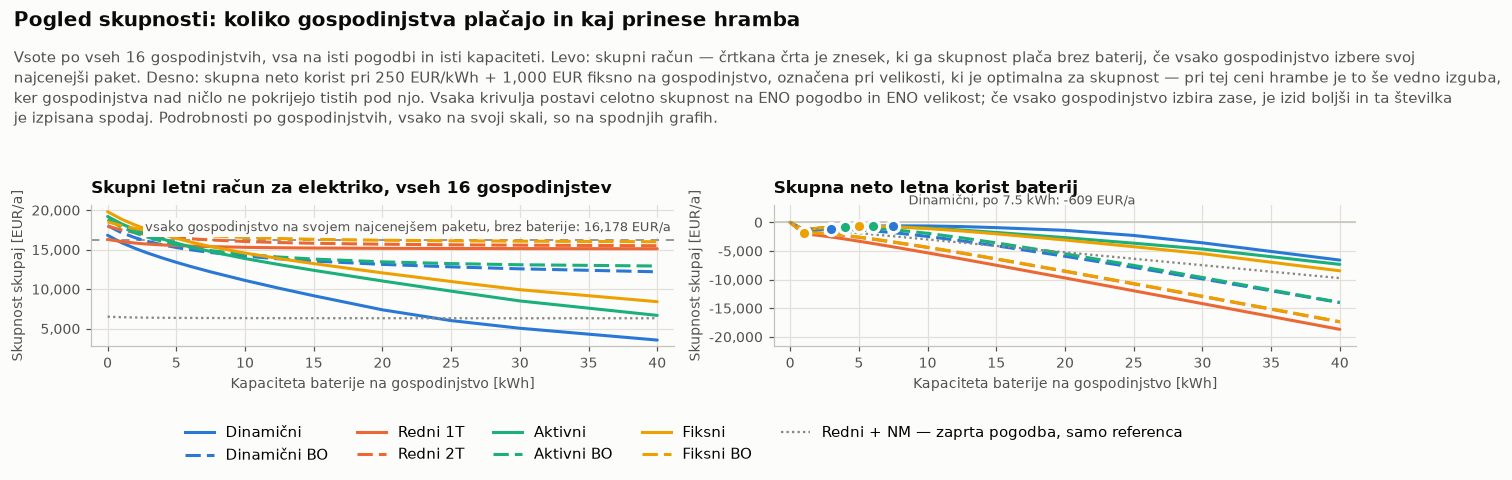

Community totals at the size that maximizes the community net benefit:
     Dinamični:   7.5 kWh each -> bill    16,830 ->    12,195 EUR/a, net      -609 EUR/a across the community
  Dinamični BO:   3.0 kWh each -> bill    18,053 ->    16,018 EUR/a, net    -1,209 EUR/a across the community
      Redni 1T:   1.0 kWh each -> bill    16,298 ->    16,034 EUR/a, net    -1,992 EUR/a across the community
      Redni 2T:   1.0 kWh each -> bill    17,978 ->    17,503 EUR/a, net    -1,784 EUR/a across the community
       Aktivni:   6.0 kWh each -> bill    19,208 ->    15,382 EUR/a, net      -687 EUR/a across the community
    Aktivni BO:   4.0 kWh each -> bill    18,815 ->    16,058 EUR/a, net      -853 EUR/a across the community
        Fiksni:   5.0 kWh each -> bill    19,816 ->    16,438 EUR/a, net      -684 EUR/a across the community
     Fiksni BO:   1.0 kWh each -> bill    18,532 ->    18,045 EUR/a, net    -1,772 EUR/a across the community
    Redni + NM:   1.0 kWh each -> bill     6,517 

In [339]:
### The whole community on one pair of axes
# The only figure where the levels are comparable: a sum is the one aggregate
# that does not care that the households are different sizes. Two panels rather
# than one because EUR/a of bill and EUR/a of net benefit are different
# measures.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
peaks = {}
totals = (
    df.groupby(["Contract", "Capacity_kWh"], observed=True)[["Cost_EUR", "Net_Annual_EUR"]]
    .sum()
)

for ax, (value, title, ylabel) in zip(axes, [
    ("Cost_EUR", f"Skupni letni račun za elektriko, vseh {len(LABEL_ORDER)} gospodinjstev",
     "Skupnost skupaj [EUR/a]"),
    ("Net_Annual_EUR", "Skupna neto letna korist baterij",
     "Skupnost skupaj [EUR/a]"),
]):
    for contract in CONTRACT_ORDER:
        # Both curves start at the 0 kWh solve, which on the right is zero by
        # construction and is the baseline the rest is measured against.
        series = totals[value].loc[contract].sort_index()
        ax.plot(series.index, series.values, color=CONTRACT_COLOR[contract],
                ls=CONTRACT_DASH[contract], lw=CONTRACT_LW[contract],
                solid_capstyle="round", zorder=3)
        # Mark the peak of every selectable curve, label only the winner: the
        # peaks sit within a couple of kWh of each other. The rest are printed
        # below.
        if value == "Net_Annual_EUR" and contract in CURRENT_CONTRACT_ORDER:
            sized = series[series.index > 0]
            top_cap = sized.idxmax()
            peaks[contract] = (top_cap, float(series.loc[top_cap]))
            ax.plot([top_cap], [series.loc[top_cap]], marker="o", ms=8,
                    color=CONTRACT_COLOR[contract], mec=SURFACE, mew=2, zorder=4)
    ax.set_title(title)
    ax.set_xlabel("Kapaciteta baterije na gospodinjstvo [kWh]")
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(EUR)
    ax.margins(x=0.03)

axes[1].axhline(0, color=BASELINE, lw=1.0, zorder=1)
axes[1].margins(y=0.16)          # headroom for the label, which sits at the top
win_contract, (win_cap, win_net) = max(peaks.items(), key=lambda kv: kv[1][1])
axes[1].annotate(f"{win_contract}, po {win_cap:g} kWh: {win_net:+,.0f} EUR/a",
                 xy=(win_cap, win_net), xytext=(10, 12), textcoords="offset points",
                 ha="left", va="bottom", fontsize=8.5, color=INK_2, zorder=5)
best_no_batt = float(no_batt[NO_BATTERY_CONTRACT_ORDER].min(axis=1).sum())
axes[0].axhline(best_no_batt, color=MUTED, lw=1.1, ls=(0, (5, 4)), zorder=2)
edge_label(axes[0], best_no_batt,
           f"vsako gospodinjstvo na svojem najcenejšem paketu, brez baterije: {best_no_batt:,.0f} EUR/a")

chart_frame(fig, "Pogled skupnosti: koliko gospodinjstva plačajo in kaj prinese hramba",
      f"Vsote po vseh {len(LABEL_ORDER)} gospodinjstvih, vsa na isti pogodbi in isti "
      f"kapaciteti. Levo: skupni račun — črtkana črta je znesek, ki ga skupnost plača brez "
      f"baterij, če vsako gospodinjstvo izbere svoj najcenejši paket. Desno: skupna neto korist "
      f"pri {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR fiksno na "
      f"gospodinjstvo, označena pri velikosti, ki je optimalna za skupnost — pri tej ceni "
      f"hrambe je to še vedno izguba, ker gospodinjstva nad ničlo ne pokrijejo tistih pod njo. "
      f"Vsaka krivulja postavi celotno skupnost na ENO pogodbo in ENO velikost; če vsako "
      f"gospodinjstvo izbira zase, je izid boljši in ta številka je izpisana spodaj. "
      f"Podrobnosti po gospodinjstvih, vsako na svoji skali, so na spodnjih grafih.")
plt.show()

print(f"Community totals at the size that maximizes the community net benefit:")
for contract in CONTRACT_ORDER:
    series = totals["Net_Annual_EUR"].loc[contract]
    series = series[series.index > 0]
    cap = series.idxmax()
    cost0 = float(totals["Cost_EUR"].loc[(contract, 0.0)])
    tag = "  (legacy)" if contract in LEGACY_CONTRACTS else ""
    print(f"  {contract:>12}: {cap:5.1f} kWh each -> bill "
          f"{cost0:9,.0f} -> {float(totals['Cost_EUR'].loc[(contract, cap)]):9,.0f} EUR/a, "
          f"net {series.loc[cap]:+9,.0f} EUR/a across the community{tag}")
# The curves hold the community to one contract and one size. Each household is
# free to pick both, and that is the number a real community would reach.
print(f"  {'free choice':>12}: each household on its own best selectable contract and size -> "
      f"net {headline['Net_Annual_EUR'].sum():+,.0f} EUR/a, "
      f"{int((headline['Net_Annual_EUR'] > 0).sum())} of {len(LABEL_ORDER)} in profit")

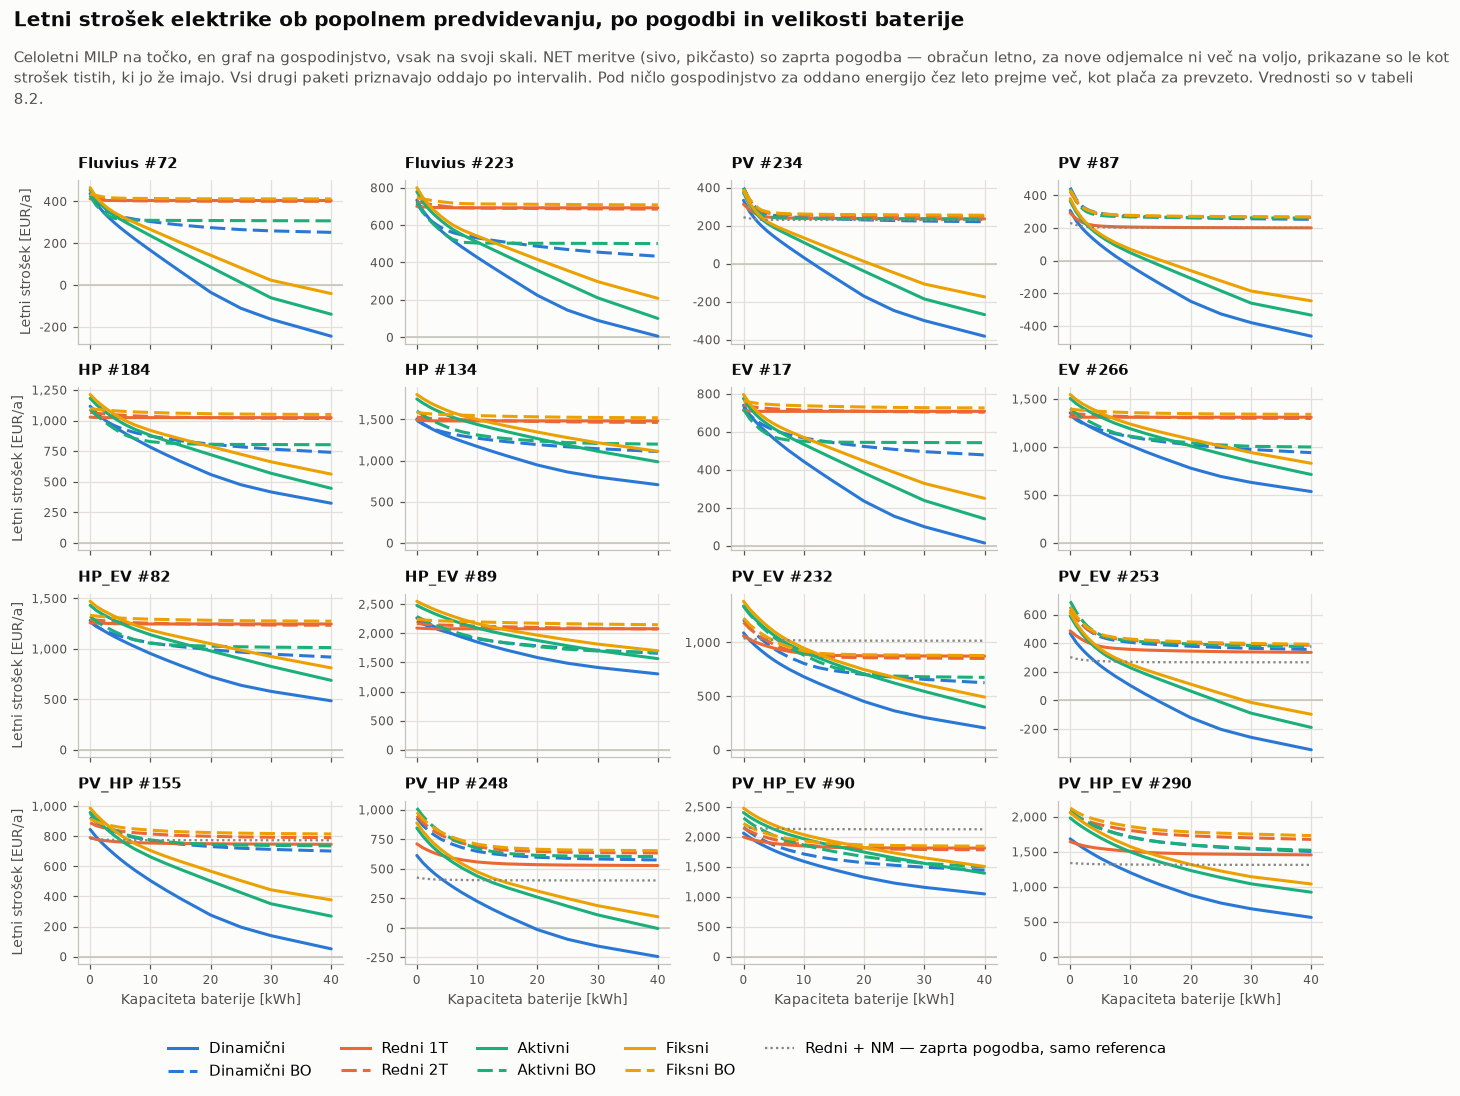

In [340]:
### Annual electricity cost vs battery size
# Independent y per panel, as everywhere in section 9: the comparison is between
# contracts within a panel, not between panels. The 0 kWh-only lists are shown
# here and nowhere else, this being the figure about the bill; on the net-benefit
# and cycle figures that point is 0 by construction.
small_multiples(
    "Cost_EUR",
    "Letni strošek elektrike ob popolnem predvidevanju, po pogodbi in velikosti baterije",
    "Celoletni MILP na točko, en graf na gospodinjstvo, vsak na svoji skali. NET meritve (sivo, "
    "pikčasto) so zaprta pogodba — obračun letno, za nove odjemalce ni več na voljo, prikazane "
    "so le kot strošek tistih, ki jo že imajo. Vsi drugi paketi priznavajo oddajo po "
    "intervalih. Pod ničlo gospodinjstvo za oddano energijo čez leto prejme več, kot plača za "
    "prevzeto. Vrednosti so v tabeli 8.2.",
    "Letni strošek [EUR/a]",
    zero_line=True,
    baselines=BASELINE_CONTRACTS,
)

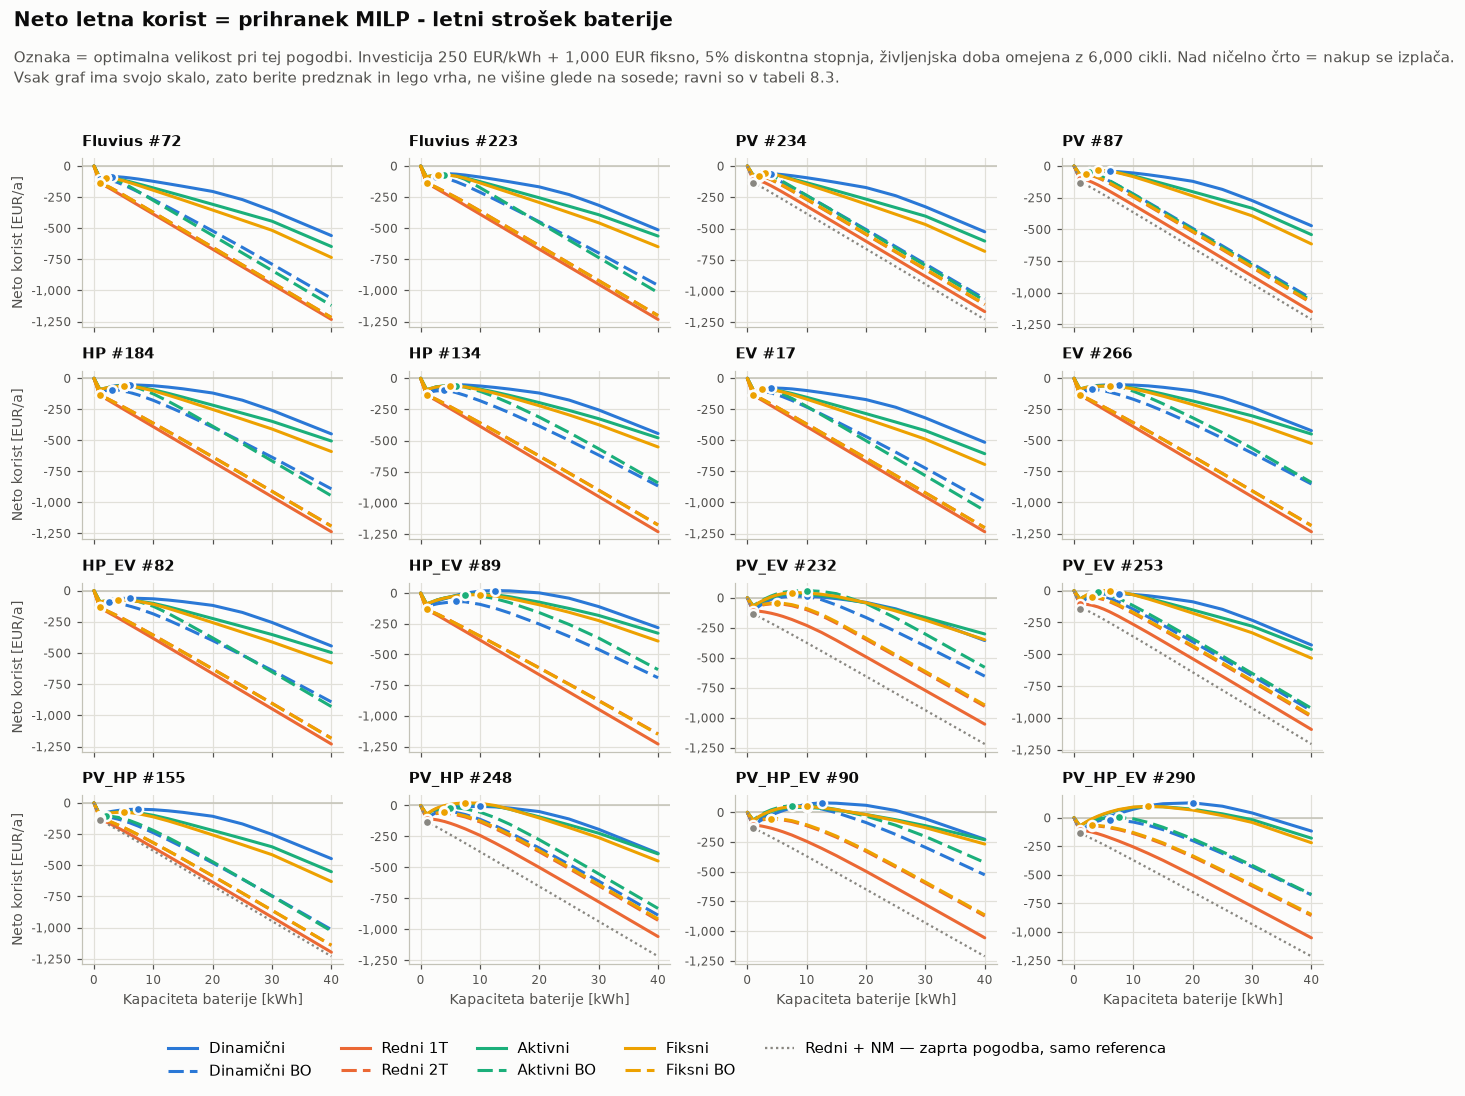

In [341]:
### Net annual benefit — the optimal size is the peak of each curve
small_multiples(
    "Net_Annual_EUR",
    "Neto letna korist = prihranek MILP - letni strošek baterije",
    f"Oznaka = optimalna velikost pri tej pogodbi. Investicija {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh "
    f"+ {CAPEX_FIXED_EUR:,.0f} EUR fiksno, {DISCOUNT_RATE:.0%} diskontna stopnja, življenjska "
    f"doba omejena z {BATTERY_CYCLE_LIMIT_EFC:,} cikli. Nad ničelno črto = nakup se izplača. "
    f"Vsak graf ima svojo skalo, zato berite predznak in lego vrha, ne višine glede na sosede; "
    f"ravni so v tabeli 8.3.",
    "Neto korist [EUR/a]",
    zero_line=True,
    mark_optimum=True,
)

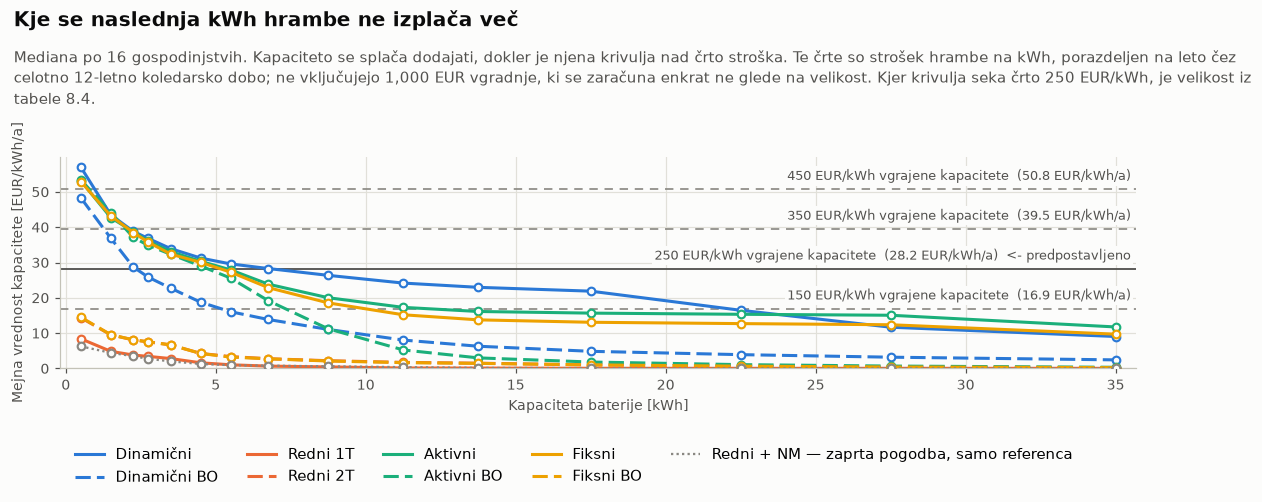

In [342]:
### Where the next kWh of storage stops paying for itself
fig, ax = plt.subplots(figsize=(10.5, 4.6))
marginal = (
    df.dropna(subset=["Marginal_Value_EUR_per_kWh"])
    .groupby(["Contract", "Capacity_kWh"], observed=True)["Marginal_Value_EUR_per_kWh"]
    .median()
)
# Plotted at the midpoint of the interval the difference was taken over.
caps = np.sort(df["Capacity_kWh"].unique())
midpoints = dict(zip(caps[1:], (caps[1:] + caps[:-1]) / 2))

crf_ref = capital_recovery_factor(DISCOUNT_RATE, BATTERY_CALENDAR_LIFE_Y)
# Cost lines first, so the curves and their markers sit on top of them. The
# assumed price gets a solid line; the rest of the scenarios are dashed.
for capex_per_kwh in sorted(set(CAPEX_SCENARIOS_EUR_PER_KWH) | {CAPEX_EUR_PER_KWH}):
    assumed = capex_per_kwh == CAPEX_EUR_PER_KWH
    level = capex_per_kwh * crf_ref
    ax.axhline(level, color=INK_2 if assumed else MUTED, lw=1.2 if assumed else 1.1,
               ls="-" if assumed else (0, (5, 4)), zorder=1)
    edge_label(ax, level, f"{capex_per_kwh:,.0f} EUR/kWh vgrajene kapacitete  ({level:,.1f} EUR/kWh/a)"
                          + ("  <- predpostavljeno" if assumed else ""))

for contract in CONTRACT_ORDER:
    series = marginal.loc[contract]
    ax.plot([midpoints[c] for c in series.index], series.values,
            color=CONTRACT_COLOR[contract], ls=CONTRACT_DASH[contract], lw=CONTRACT_LW[contract],
            marker="o", ms=5, mfc=SURFACE, mew=1.4, zorder=3)

ax.set_ylim(bottom=0)
ax.margins(x=0.02)
ax.set_xlabel("Kapaciteta baterije [kWh]")
ax.set_ylabel("Mejna vrednost kapacitete [EUR/kWh/a]")
ax.yaxis.set_major_formatter(PLAIN)
chart_frame(fig, "Kje se naslednja kWh hrambe ne izplača več",
      f"Mediana po {len(LABEL_ORDER)} gospodinjstvih. Kapaciteto se splača dodajati, dokler je "
      f"njena krivulja nad črto stroška. Te črte so strošek hrambe na kWh, porazdeljen na leto "
      f"čez celotno {BATTERY_CALENDAR_LIFE_Y}-letno koledarsko dobo; ne vključujejo "
      f"{CAPEX_FIXED_EUR:,.0f} EUR vgradnje, ki se zaračuna enkrat ne glede na velikost. Kjer "
      f"krivulja seka črto {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh, je velikost iz tabele 8.4.")
plt.show()

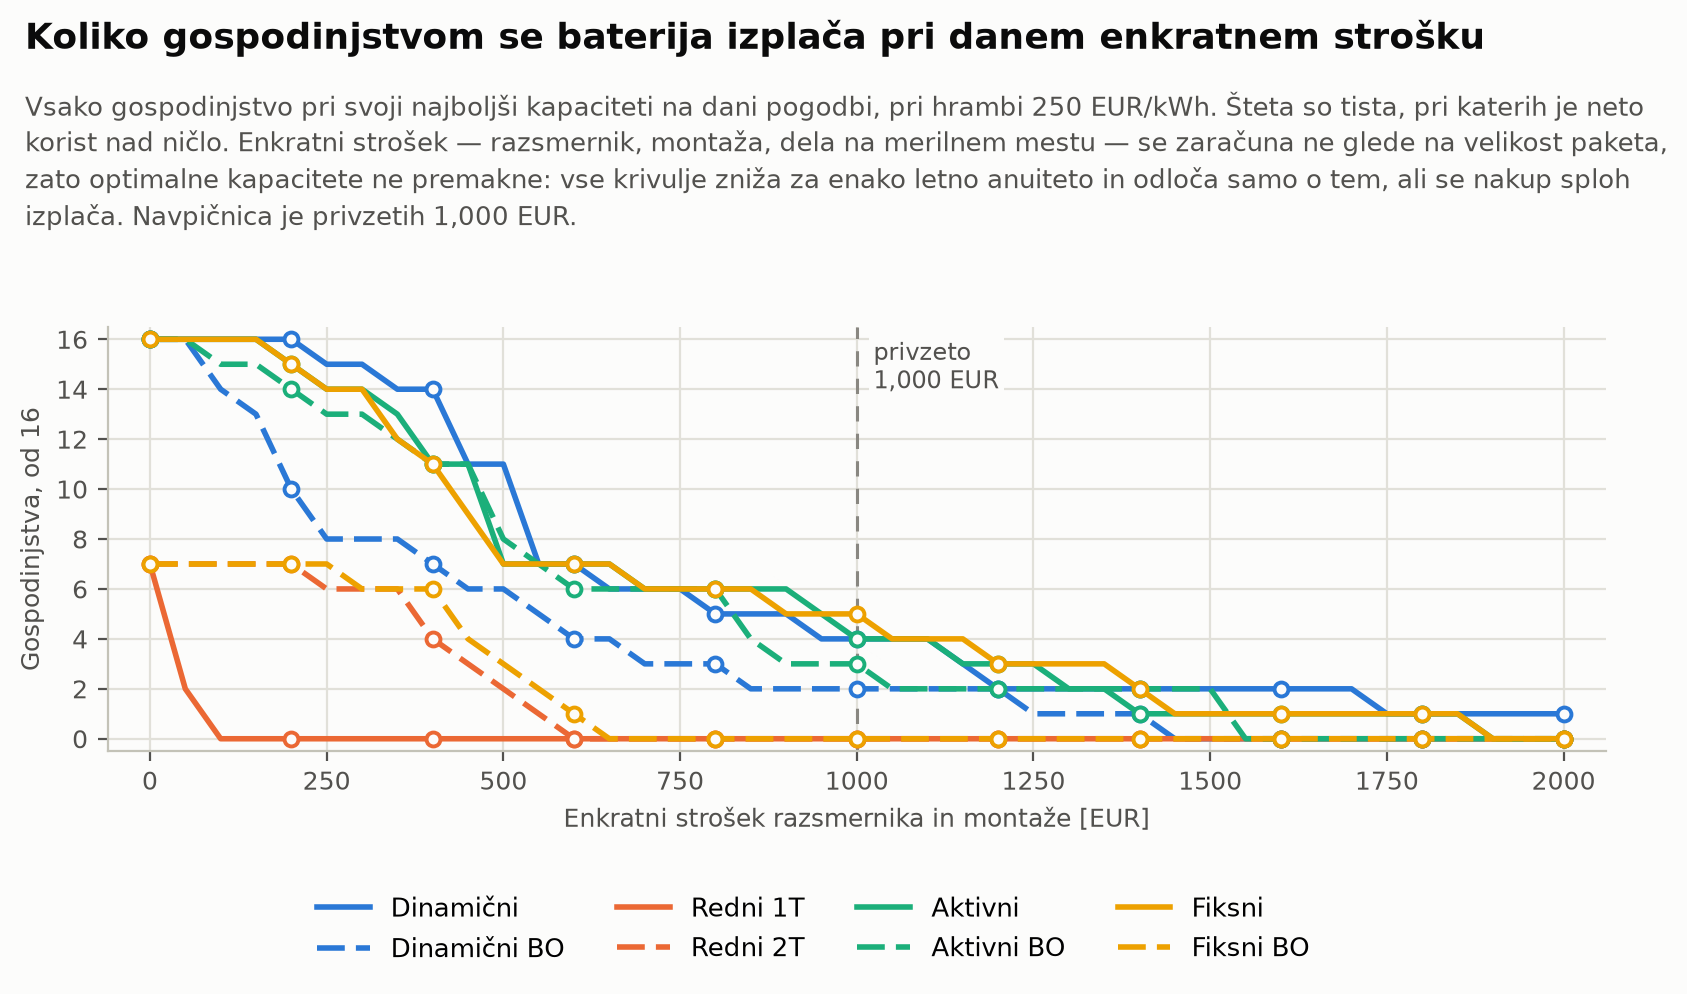

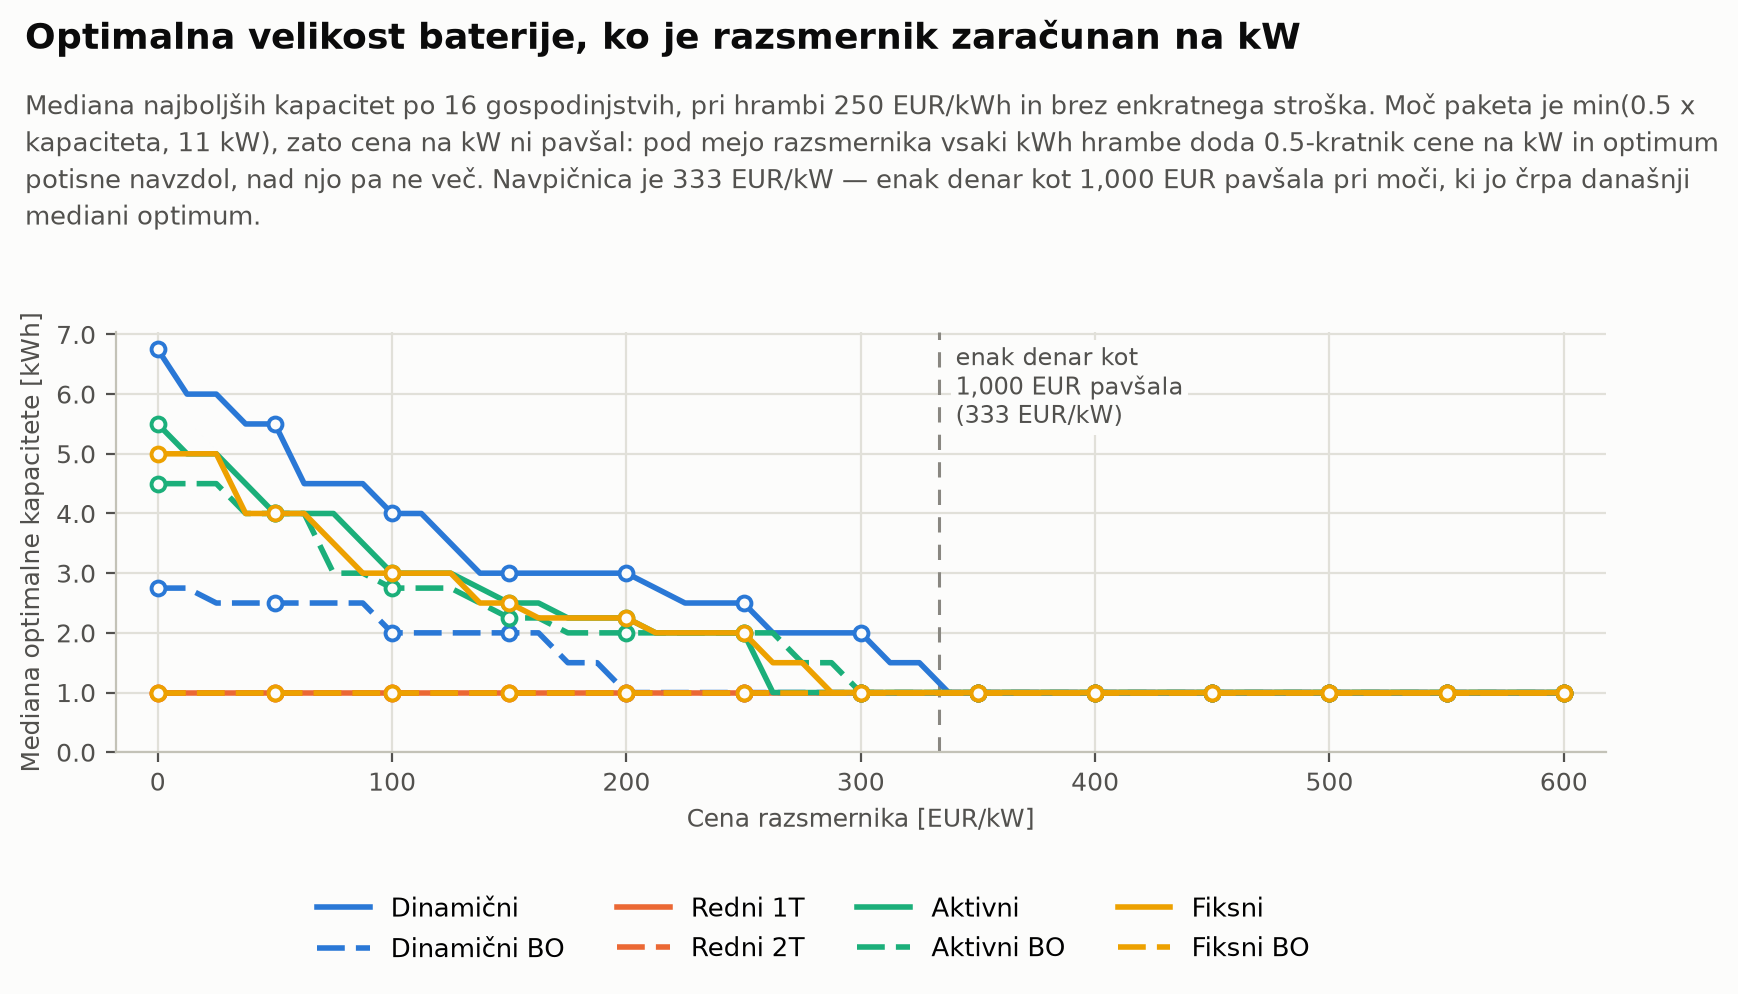

In [343]:
### What the inverter costs the case for a battery
# Two effects, two figures: a flat fee moves the zero-profit threshold without
# touching the optimal size, a per-kW price moves the size itself. One solve of
# the capex model per x value, read off for all contracts.

n_profit = {c: [] for c in CURRENT_CONTRACT_ORDER}
med_kwh = {c: [] for c in CURRENT_CONTRACT_ORDER}
for fixed_eur in INVERTER_FIXED_FINE_EUR:
    top = optimum_capex(CAPEX_EUR_PER_KWH, fixed_eur)
    for contract in CURRENT_CONTRACT_ORDER:
        n_profit[contract].append(int((top.xs(contract, level="Contract")["Net"] > 0).sum()))
for per_kw in INVERTER_PER_KW_FINE:
    top = optimum_capex(CAPEX_EUR_PER_KWH, fixed_eur=0.0, eur_per_kw=per_kw)
    for contract in CURRENT_CONTRACT_ORDER:
        med_kwh[contract].append(
            float(top.xs(contract, level="Contract")["Capacity_kWh"].median())
        )

# Legend keys from the shared helper, so these two carry the same
# colour = product / dash = odkup encoding as every other figure.
keys = contract_handles(contracts=CURRENT_CONTRACT_ORDER)
# The sweep is 4x denser than the markers, so a marker every fourth sample still
# lands on the round 200 EUR / 50 EUR-per-kW values a reader would look up.
MARK_EVERY = 4
FIG_DPI = 200            # these two are read at the threshold, not at the trend


def vline_note(ax, x, text, x_max):
    """Label pinned to a vertical reference line, flipped to the other side once
    the line sits in the right third. The equal-money rate is computed from the
    data, not fixed, so it moves — and a label that runs off the axes is worse
    than no label. Surface-coloured pad, as edge_label does, so it never sits on
    a curve."""
    right = x > 0.66 * x_max
    ax.annotate(text, xy=(x, 0.97), xycoords=("data", "axes fraction"),
                xytext=(-6 if right else 6, 0), textcoords="offset points",
                ha="right" if right else "left", va="top",
                fontsize=8.5, color=INK_2, zorder=5,
                bbox=dict(facecolor=SURFACE, edgecolor="none", pad=1.6))


### 9a A flat fee decides IF, never HOW BIG
fig1, ax1 = plt.subplots(figsize=(8.2, 5.0), dpi=FIG_DPI)
for contract in CURRENT_CONTRACT_ORDER:
    ax1.plot(INVERTER_FIXED_FINE_EUR, n_profit[contract], color=CONTRACT_COLOR[contract],
             ls=CONTRACT_DASH[contract], lw=CONTRACT_LW[contract],
             marker="o", ms=5, mfc=SURFACE, mew=1.4, markevery=MARK_EVERY,
             solid_capstyle="round", zorder=3)

ax1.axvline(CAPEX_FIXED_EUR, color=MUTED, lw=1.1, ls=(0, (5, 4)), zorder=2)
vline_note(ax1, CAPEX_FIXED_EUR, f"privzeto\n{CAPEX_FIXED_EUR:,.0f} EUR",
           float(INVERTER_FIXED_FINE_EUR[-1]))
ax1.set_xlabel("Enkratni strošek razsmernika in montaže [EUR]")
ax1.set_ylabel(f"Gospodinjstva, od {len(LABEL_ORDER)}")
ax1.set_ylim(-0.5, len(LABEL_ORDER) + 0.5)
# A count of households is a whole number; the default locator puts ticks at 2.5
# gospodinjstva. Step chosen to keep roughly eight ticks whatever the panel size.
ax1.set_yticks(range(0, len(LABEL_ORDER) + 1, max(1, round(len(LABEL_ORDER) / 8))))
ax1.margins(x=0.03)
ax1.yaxis.set_major_formatter(PLAIN)

chart_frame(fig1, "Koliko gospodinjstvom se baterija izplača pri danem enkratnem strošku",
      f"Vsako gospodinjstvo pri svoji najboljši kapaciteti na dani pogodbi, pri hrambi "
      f"{CAPEX_EUR_PER_KWH:,.0f} EUR/kWh. Šteta so tista, pri katerih je neto korist nad "
      f"ničlo. Enkratni strošek — razsmernik, montaža, dela na merilnem mestu — se zaračuna "
      f"ne glede na velikost paketa, zato optimalne kapacitete ne premakne: vse krivulje "
      f"zniža za enako letno anuiteto in odloča samo o tem, ali se nakup sploh izplača. "
      f"Navpičnica je privzetih {CAPEX_FIXED_EUR:,.0f} EUR.", handles=keys, ncol=4)
plt.show()

### 9b A per-kW price decides HOW BIG
fig2, ax2 = plt.subplots(figsize=(8.2, 5.0), dpi=FIG_DPI)
for contract in CURRENT_CONTRACT_ORDER:
    ax2.plot(INVERTER_PER_KW_FINE, med_kwh[contract], color=CONTRACT_COLOR[contract],
             ls=CONTRACT_DASH[contract], lw=CONTRACT_LW[contract],
             marker="o", ms=5, mfc=SURFACE, mew=1.4, markevery=MARK_EVERY,
             solid_capstyle="round", zorder=3)

ax2.axvline(EQUAL_MONEY_EUR_PER_KW, color=MUTED, lw=1.1, ls=(0, (5, 4)), zorder=2)
vline_note(ax2, EQUAL_MONEY_EUR_PER_KW,
           f"enak denar kot\n{CAPEX_FIXED_EUR:,.0f} EUR pavšala\n"
           f"({EQUAL_MONEY_EUR_PER_KW:,.0f} EUR/kW)",
           float(INVERTER_PER_KW_FINE[-1]))
ax2.set_xlabel("Cena razsmernika [EUR/kW]")
ax2.set_ylabel("Mediana optimalne kapacitete [kWh]")
ax2.set_ylim(bottom=0)
ax2.margins(x=0.03)
# Kapacitete ležijo na polkilovatni mreži: PLAIN bi 7.5 kWh izpisal kot 8.
ax2.yaxis.set_major_formatter(KW)

chart_frame(fig2, "Optimalna velikost baterije, ko je razsmernik zaračunan na kW",
      f"Mediana najboljših kapacitet po {len(LABEL_ORDER)} gospodinjstvih, pri hrambi "
      f"{CAPEX_EUR_PER_KWH:,.0f} EUR/kWh in brez enkratnega stroška. Moč paketa je "
      f"min({C_RATE:g} x kapaciteta, {INVERTER_MAX_KW:,.0f} kW), zato cena na kW ni pavšal: "
      f"pod mejo razsmernika vsaki kWh hrambe doda {C_RATE:g}-kratnik cene na kW in optimum "
      f"potisne navzdol, nad njo pa ne več. Navpičnica je {EQUAL_MONEY_EUR_PER_KW:,.0f} "
      f"EUR/kW — enak denar kot {CAPEX_FIXED_EUR:,.0f} EUR pavšala pri moči, ki jo črpa "
      f"današnji mediani optimum.", handles=keys, ncol=4)
plt.show()

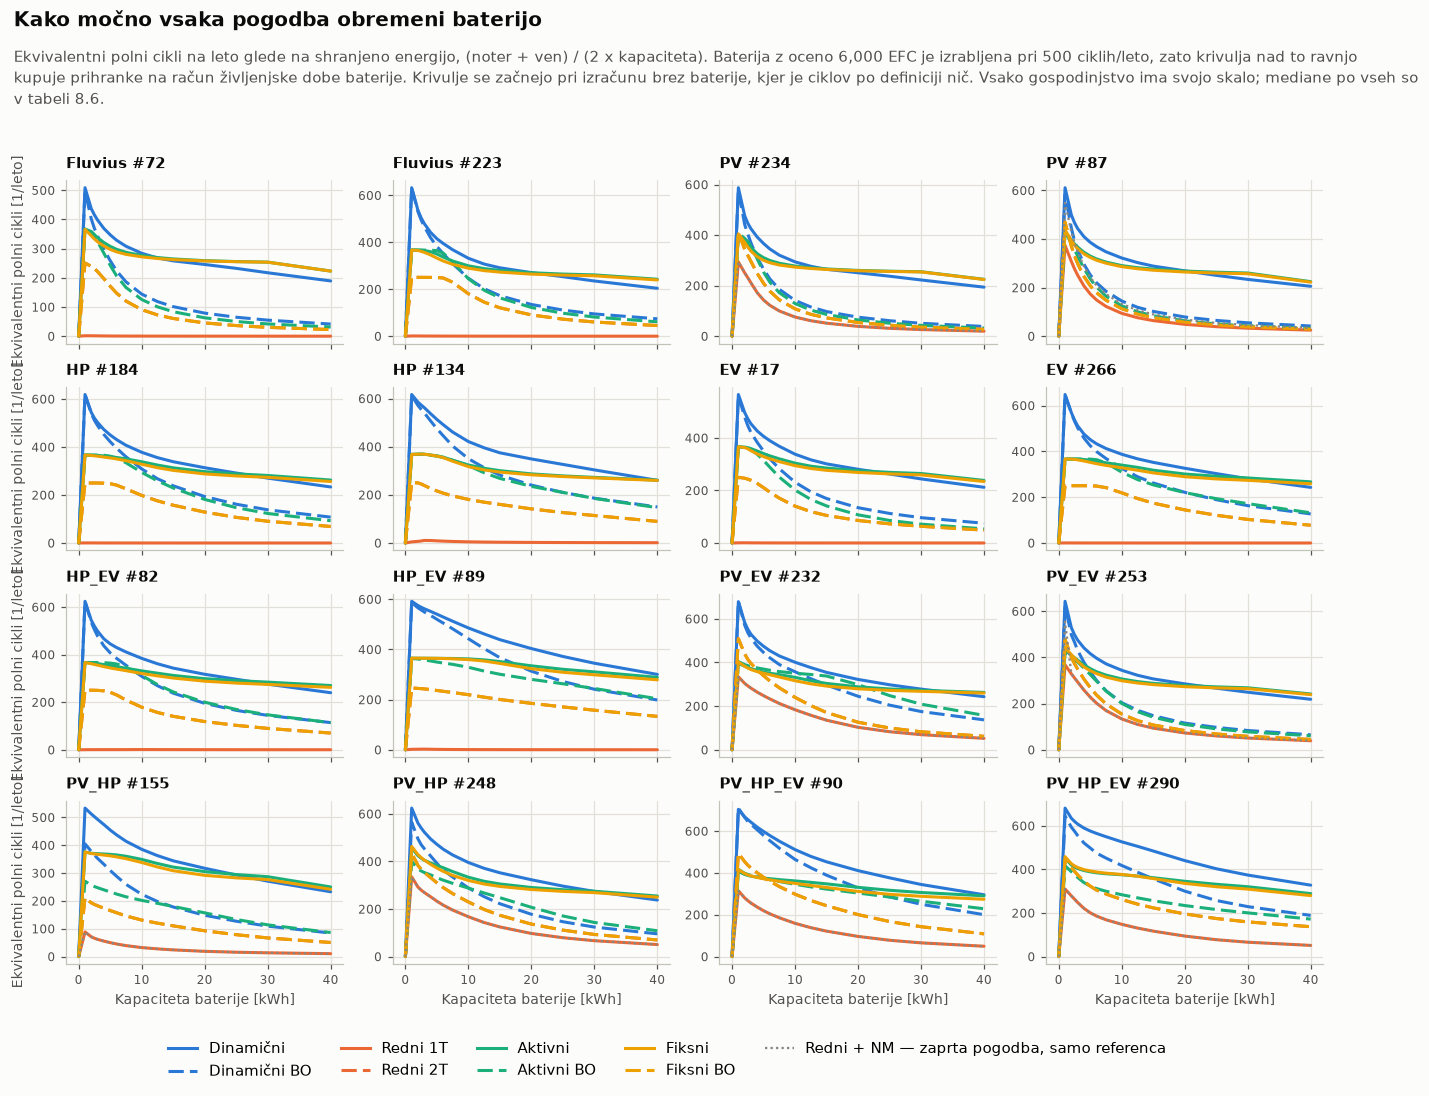

In [344]:
### Equivalent full cycles per year
# The curve starts at the 0 kWh solve, so the first segment is a steep climb into
# the 1 kWh point: the first kWh of storage is cycled hardest.
small_multiples(
    "Equivalent_Full_Cycles",
    "Kako močno vsaka pogodba obremeni baterijo",
    f"Ekvivalentni polni cikli na leto glede na shranjeno energijo, (noter + ven) / (2 x "
    f"kapaciteta). Baterija z oceno {BATTERY_CYCLE_LIMIT_EFC:,} EFC je izrabljena pri "
    f"{BATTERY_CYCLE_LIMIT_EFC // BATTERY_CALENDAR_LIFE_Y} ciklih/leto, zato krivulja nad to "
    f"ravnjo kupuje prihranke na račun življenjske dobe baterije. Krivulje se začnejo pri "
    f"izračunu brez baterije, kjer je ciklov po definiciji nič. Vsako gospodinjstvo ima svojo "
    f"skalo; mediane po vseh so v tabeli 8.6.",
    "Ekvivalentni polni cikli [1/leto]",
    fmt=PLAIN,
)

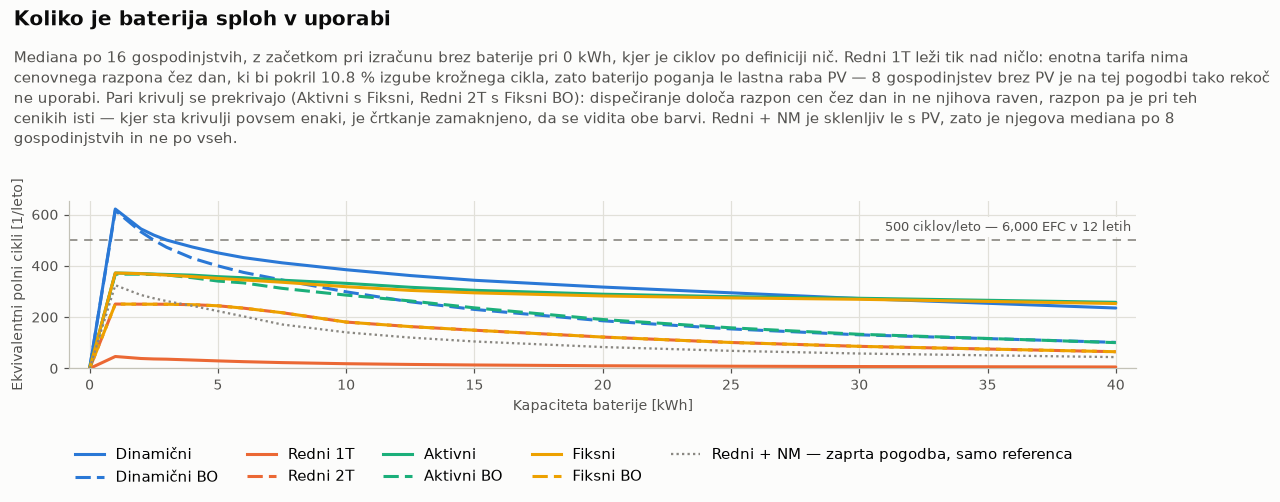

Peak median equivalent full cycles per year, over 16 households, and how many of them never reach 12 EFC/a at ANY capacity:
  Dinamični      621.5
  Dinamični BO   615.8
  Aktivni        372.0
  Fiksni         372.0
  Aktivni BO     367.7
  Redni + NM     324.6
  Redni 2T       251.1
  Fiksni BO      251.1
  Redni 1T        46.7   <- idle for 8 of 16: EV #17, EV #266, Fluvius #223, Fluvius #72, HP #134, HP #184, HP_EV #82, HP_EV #89


In [345]:
### The same usage question asked of the whole sample at once
# Same metric as the panels above, one pair of axes, medians -- the picture
# behind table 8.6.
#
# Cycles rather than kWh through the store, because cycles divide the throughput
# by the capacity it moved through and so compare across capacities and against
# the pack's own cycle budget. Median rather than mean, because these households
# differ several-fold in annual consumption.
fig, ax = plt.subplots(figsize=(10.5, 4.6))
usage = df.groupby(["Contract", "Capacity_kWh"], observed=True)

# The cycle budget first, so the curves sit on top of it: a curve above the line
# wears the pack out before its calendar warranty runs out.
efc_budget = BATTERY_CYCLE_LIMIT_EFC / BATTERY_CALENDAR_LIFE_Y
ax.axhline(efc_budget, color=MUTED, lw=1.1, ls=(0, (5, 4)), zorder=1)
edge_label(ax, efc_budget,
           f"{efc_budget:,.0f} ciklov/leto — {BATTERY_CYCLE_LIMIT_EFC:,} EFC v "
           f"{BATTERY_CALENDAR_LIFE_Y} letih")

drawn = []
for contract in CONTRACT_ORDER:
    series = usage["Equivalent_Full_Cycles"].median().loc[contract]
    ls = CONTRACT_DASH[contract]
    # A curve that coincides with one already drawn is painted over entirely.
    # Shifting the dash phase by half a period puts the two colours in alternate
    # dashes along the same line, moving no data and no line style.
    if isinstance(ls, tuple) and any(np.allclose(series.values, prev, rtol=1e-3, atol=1e-6)
                                     for prev in drawn):
        ls = (ls[0] + sum(ls[1]) / 2.0, ls[1])
    drawn.append(series.values)
    ax.plot(series.index, series.values, color=CONTRACT_COLOR[contract],
            ls=ls, lw=CONTRACT_LW[contract], solid_capstyle="round", zorder=3)

ax.set_ylim(bottom=0)
ax.margins(x=0.02)
ax.set_xlabel("Kapaciteta baterije [kWh]")
ax.set_ylabel("Ekvivalentni polni cikli [1/leto]")
ax.yaxis.set_major_formatter(PLAIN)

# Two results stated in the subtitle, both of which otherwise read as a bug:
#
# 1. Redni 1T lies on the floor. A single ET rate leaves only the network energy
#    charge to arbitrage, ~0.011 EUR/kWh between blocks, against a round trip
#    costing ~0.016. What remains is self-consumption and the odd peak shave.
# 2. Curves overlap in pairs. Dispatch follows price differences across the day,
#    not the level: GENI_REDNI and GENI_FIKSNI carry the same 0.0220 VT-MT
#    spread, GENI_SAMO_AKTIVNI and GENI_SAMO_FIKSNI the same four-block spread.
#    Same spread, same trajectory, different bill.
roundtrip_loss_pct = 100.0 * (1.0 / (CHARGE_EFFICIENCY * DISCHARGE_EFFICIENCY) - 1.0)
n_pv = int(sum(HAS_PV.values()))
chart_frame(fig, "Koliko je baterija sploh v uporabi",
      f"Mediana po {len(LABEL_ORDER)} gospodinjstvih, z začetkom pri izračunu brez baterije pri "
      f"0 kWh, kjer je ciklov po definiciji nič. Redni 1T leži tik nad ničlo: enotna tarifa nima "
      f"cenovnega razpona čez dan, ki bi pokril {roundtrip_loss_pct:.1f} % izgube krožnega cikla, "
      f"zato baterijo poganja le lastna raba PV — {len(LABEL_ORDER) - n_pv} gospodinjstev brez "
      f"PV je na tej pogodbi tako rekoč ne uporabi. Pari krivulj se prekrivajo (Aktivni s "
      f"Fiksni, Redni 2T s Fiksni BO): dispečiranje določa razpon cen čez dan in ne njihova "
      f"raven, razpon pa je pri teh cenikih isti — kjer sta krivulji povsem enaki, je črtkanje "
      f"zamaknjeno, da se vidita obe barvi. Redni + NM je sklenljiv le s PV, zato je "
      f"njegova mediana po {n_pv} gospodinjstvih in ne po vseh.")
plt.show()

# The claim in the subtitle, as numbers. The threshold is about the pack rather
# than the money: under a cycle a month the store spends the year standing
# still.
IDLE_EFC_PER_YEAR = 12.0
peak_efc = usage["Equivalent_Full_Cycles"].median().groupby("Contract", observed=True).max()
best_efc = (df[df["Capacity_kWh"] > 0]
            .groupby(["Contract", "Label"], observed=True)["Equivalent_Full_Cycles"].max())
print(f"Peak median equivalent full cycles per year, over {len(LABEL_ORDER)} households, "
      f"and how many of them never reach {IDLE_EFC_PER_YEAR:.0f} EFC/a at ANY capacity:")
for contract, efc in peak_efc.sort_values(ascending=False).items():
    idle = best_efc.loc[contract]
    idle = idle[idle < IDLE_EFC_PER_YEAR]
    note = ("" if idle.empty else
            f"   <- idle for {len(idle)} of {len(LABEL_ORDER)}: "
            + ", ".join(sorted(idle.index)))
    print(f"  {contract:<13}{efc:7.1f}{note}")

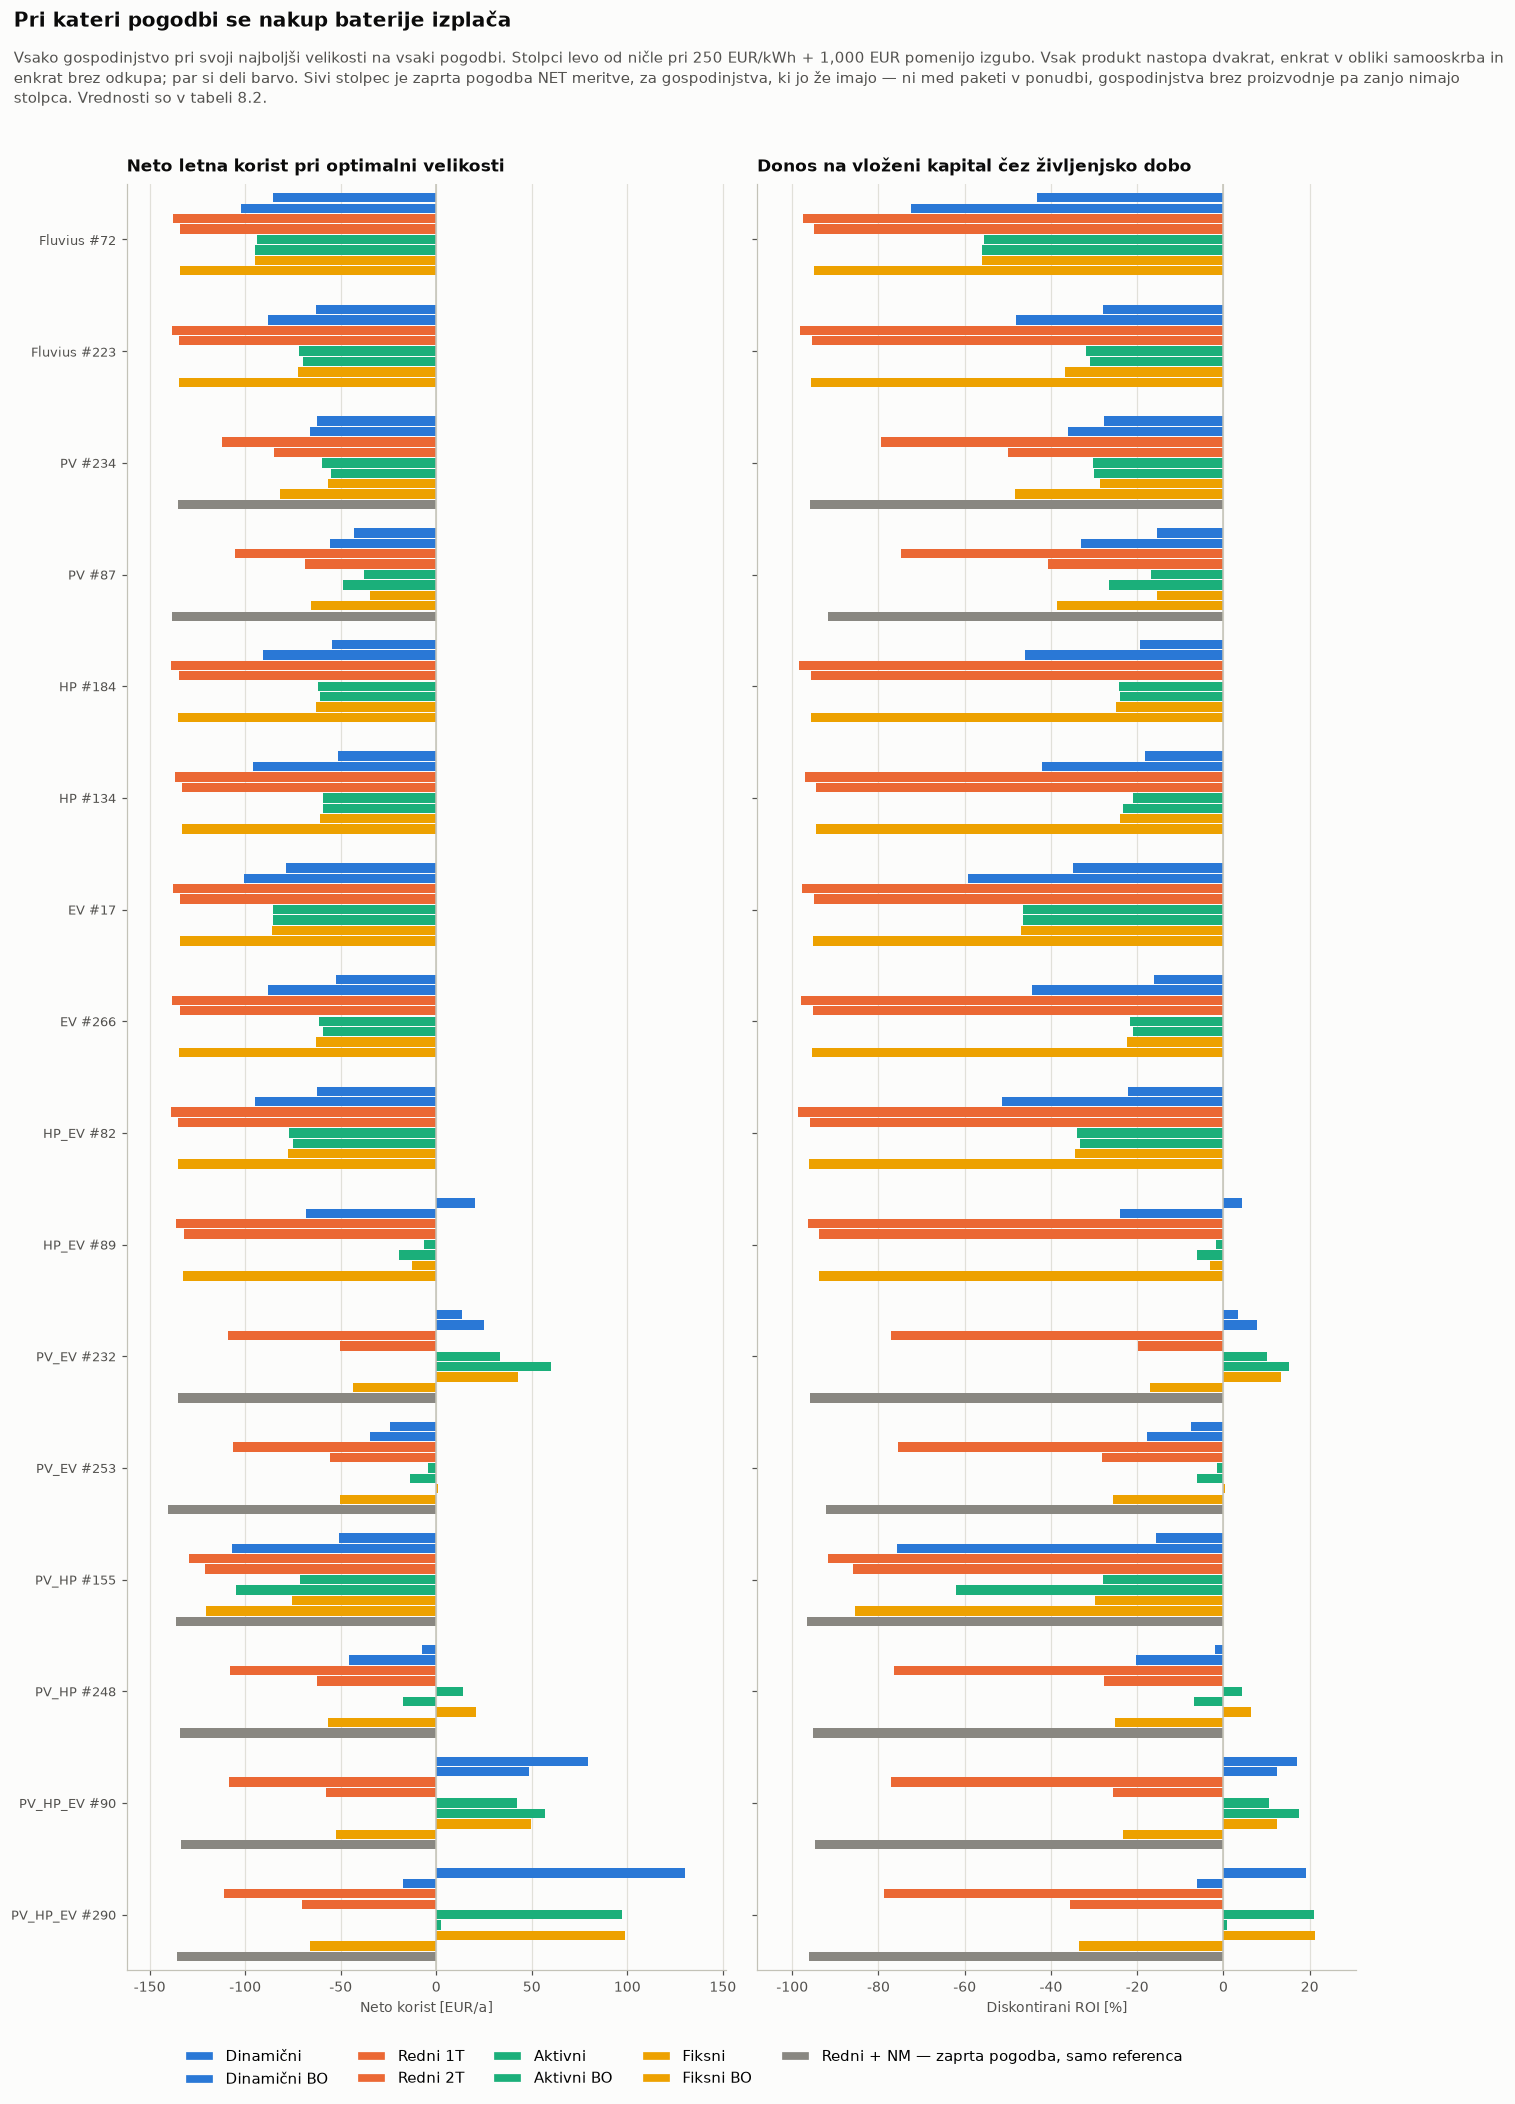

In [346]:
### The headline comparison: net annual benefit at each household's optimal size
# Horizontal bars, one row per household, so the household name is a full-length
# label whatever the count and the figure grows downwards.
n = len(LABEL_ORDER)
# Height scales with the number of bars, not of households: nine contracts in a
# 0.44 in row would give each bar less space than the line around it.
BAR_IN = 0.115
fig, axes = plt.subplots(1, 2, figsize=(12.5, BAR_IN * len(CONTRACT_ORDER) * n + 2.6),
                         sharey=True)
y = np.arange(n)
height = 0.84 / len(CONTRACT_ORDER)

for ax, (value, xlabel, fmt, panel_title) in zip(axes, [
    ("Net_Annual_EUR", "Neto korist [EUR/a]", EUR, "Neto letna korist pri optimalni velikosti"),
    ("ROI_pct", "Diskontirani ROI [%]", PLAIN, "Donos na vloženi kapital čez življenjsko dobo"),
]):
    for i, contract in enumerate(CONTRACT_ORDER):
        # NaN where the household was never quoted the list — matplotlib draws
        # no bar for it, which is the honest mark: not a zero benefit, no offer.
        cells = [
            best_table.loc[(best_table["Label"] == lab)
                           & (best_table["Contract"] == contract), value]
            for lab in LABEL_ORDER
        ]
        vals = [float(c.iloc[0]) if len(c) else np.nan for c in cells]
        # Offsets run downwards so the bar order inside a group matches the
        # legend order top to bottom (the y axis is inverted below).
        ax.barh(y + (i - (len(CONTRACT_ORDER) - 1) / 2) * height, vals, height * 0.9,
                color=CONTRACT_COLOR[contract], zorder=2)
    ax.axvline(0, color=BASELINE, lw=1.0, zorder=3)
    ax.set_xlabel(xlabel)
    ax.set_title(panel_title)
    ax.xaxis.set_major_formatter(fmt)
    ax.margins(x=0.08)
    ax.grid(axis="y", visible=False)

axes[0].set_yticks(y, LABEL_ORDER, fontsize=8.5)
axes[0].set_ylim(n - 0.5, -0.5)          # first household at the top
chart_frame(fig, "Pri kateri pogodbi se nakup baterije izplača",
      f"Vsako gospodinjstvo pri svoji najboljši velikosti na vsaki pogodbi. Stolpci levo od "
      f"ničle pri {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR pomenijo "
      f"izgubo. Vsak produkt nastopa dvakrat, enkrat v obliki samooskrba in enkrat brez odkupa; "
      f"par si deli barvo. Sivi stolpec je zaprta pogodba NET meritve, za gospodinjstva, ki jo "
      f"že imajo — ni med paketi v ponudbi, gospodinjstva brez proizvodnje pa zanjo nimajo "
      f"stolpca. Vrednosti so v tabeli 8.2.",
      handles=contract_handles("bar"))
plt.show()

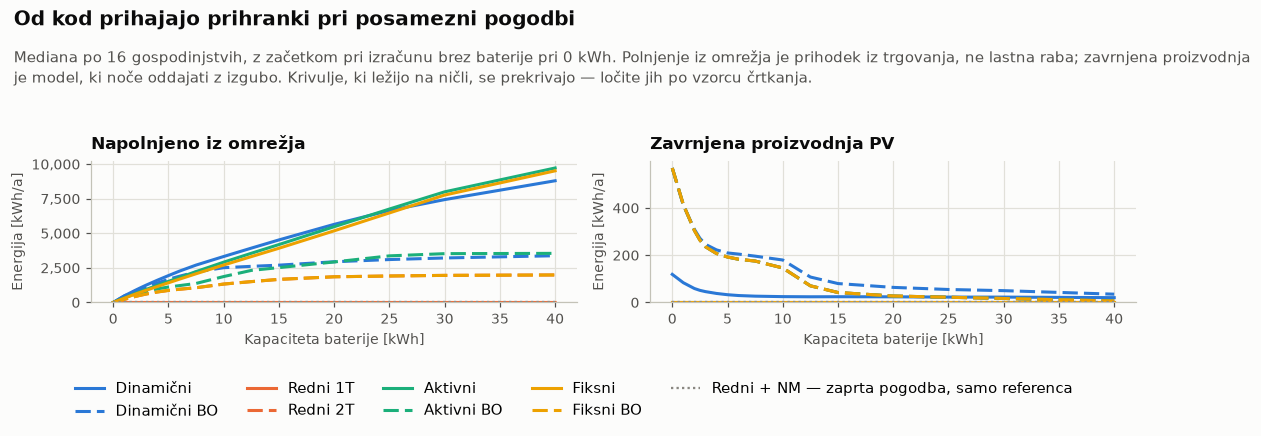

In [347]:
### What the battery actually does: throughput and curtailment
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
# Including 0 kWh: grid charging is zero there by definition, but curtailment is
# not, and that level is what the curve is read against.
grouped = df.groupby(["Contract", "Capacity_kWh"], observed=True)

for ax, (value, title, ylabel) in zip(axes, [
    ("Grid_Charged_kWh", "Napolnjeno iz omrežja", "Energija [kWh/a]"),
    ("Curtailed_kWh", "Zavrnjena proizvodnja PV", "Energija [kWh/a]"),
]):
    for contract in CONTRACT_ORDER:
        series = grouped[value].median().loc[contract]
        ax.plot(series.index, series.values, color=CONTRACT_COLOR[contract],
                ls=CONTRACT_DASH[contract], lw=CONTRACT_LW[contract])
    ax.set_title(title)
    ax.set_xlabel("Kapaciteta baterije [kWh]")
    ax.set_ylabel(ylabel)
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(PLAIN)

chart_frame(fig, "Od kod prihajajo prihranki pri posamezni pogodbi",
      f"Mediana po {len(LABEL_ORDER)} gospodinjstvih, z začetkom pri izračunu brez baterije pri "
      f"0 kWh. Polnjenje iz omrežja je prihodek iz trgovanja, ne lastna raba; zavrnjena "
      f"proizvodnja je model, ki noče oddajati z izgubo. Krivulje, ki ležijo na ničli, se "
      f"prekrivajo — ločite jih po vzorcu črtkanja.")
plt.show()

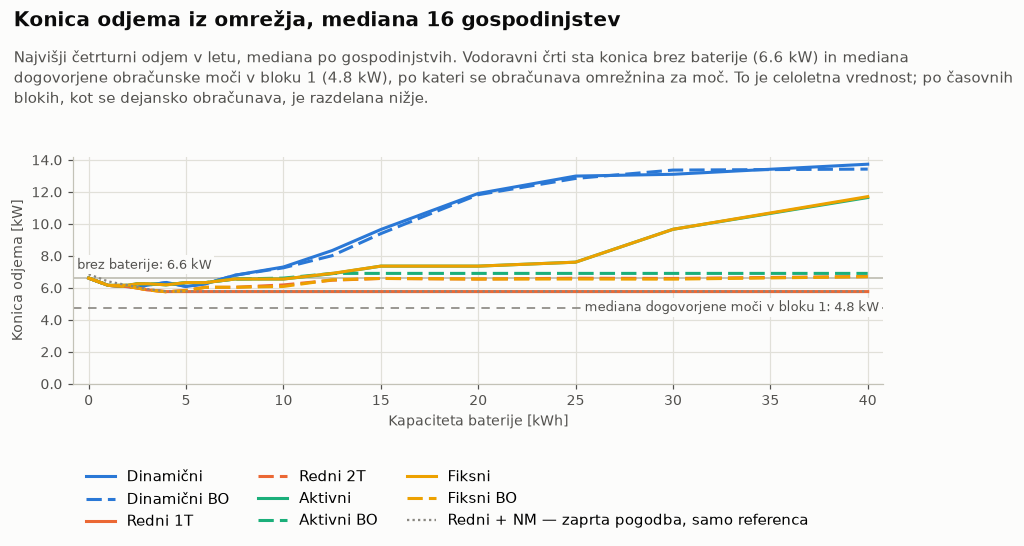

In [348]:
### What the battery does to the peak grid import
# Peak import is billed against contracted power, and the block-arbitrage lists
# charge from the grid at the cheapest hour of the day -- a load the house never
# had -- so their peak climbs with the inverter rating rather than falling with
# self-consumption.
#
# Three questions, three sets of axes, one frame prepared here: the kW the
# connection sees, the change each household's own peak went through, and that
# same kW inside each network-tariff block, which is what gets billed.
peak_runs = df.copy()
peak_base = (
    df.loc[df["Capacity_kWh"] == 0.0]
    .set_index(["Label", "Contract"])["Peak_Import_kW"]
)
# 0 kWh included, so every curve starts at the no-battery peak: here that is the
# kW the connection already sees, in the next figure it is 0 % by construction.
peak_runs["Peak_No_Battery_kW"] = [
    peak_base.loc[(lab, t)] for lab, t in zip(peak_runs["Label"], peak_runs["Contract"])
]
peak_runs["Peak_Change_pct"] = 100.0 * (
    peak_runs["Peak_Import_kW"] / peak_runs["Peak_No_Battery_kW"] - 1.0
)
by_cap = peak_runs.groupby(["Contract", "Capacity_kWh"], observed=True)

# The same two columns per block, prepared here so the five figures and their
# read-out cannot read different baselines. Skipped, with a flag the cells below
# honour, when the cache predates the block columns.
BLOCK_PEAKS_READY = (set(BLOCK_PEAK_COLS + BLOCK_AGREED_COLS) <= set(peak_runs.columns)
                     and bool(peak_runs[BLOCK_PEAK_COLS].notna().all().all()))
if BLOCK_PEAKS_READY:
    block_base = (
        peak_runs.loc[peak_runs["Capacity_kWh"] == 0.0]
        .set_index(["Label", "Contract"])[BLOCK_PEAK_COLS]
    )
    for b in TARIFF_BLOCKS:
        base_map = block_base[f"Peak_Import_B{b}_kW"]
        peak_runs[f"Peak_No_Battery_B{b}_kW"] = [
            base_map.loc[(lab, t)]
            for lab, t in zip(peak_runs["Label"], peak_runs["Contract"])
        ]
        # A household that never draws from the grid in a block has no baseline
        # to be a percentage of — NaN, not an infinite improvement.
        peak_runs[f"Peak_Change_B{b}_pct"] = 100.0 * (
            peak_runs[f"Peak_Import_B{b}_kW"]
            / peak_runs[f"Peak_No_Battery_B{b}_kW"].replace(0.0, np.nan) - 1.0
        )

fig, ax = plt.subplots(figsize=(8.2, 5.0))
for contract in CONTRACT_ORDER:
    abs_kw = by_cap["Peak_Import_kW"].median().loc[contract]
    ax.plot(abs_kw.index, abs_kw.values, color=CONTRACT_COLOR[contract],
            ls=CONTRACT_DASH[contract], lw=CONTRACT_LW[contract], zorder=3)

base_kw = float(peak_base.groupby(level="Label").median().median())
# Block 1's agreed power, averaged over the months and taken to the median
# household. It is the lowest of the five, hence the one drawn here.
contracted_kw = float(df.groupby("Label")["Contracted_Power_kW"].first().median())
ax.axhline(base_kw, color=BASELINE, lw=1.2, zorder=2)
edge_label(ax, base_kw, f"brez baterije: {base_kw:,.1f} kW", side="left")
ax.axhline(contracted_kw, color=MUTED, lw=1.1, ls=(0, (5, 4)), zorder=2)
edge_label(ax, contracted_kw - 0.8, f"mediana dogovorjene moči v bloku 1: {contracted_kw:,.1f} kW")
ax.set_xlabel("Kapaciteta baterije [kWh]")
ax.set_ylabel("Konica odjema [kW]")
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(KW)
ax.margins(x=0.02)

chart_frame(fig, f"Konica odjema iz omrežja, mediana {len(LABEL_ORDER)} gospodinjstev",
      f"Najvišji četrturni odjem v letu, mediana po gospodinjstvih. Vodoravni črti sta konica "
      f"brez baterije ({base_kw:,.1f} kW) in mediana dogovorjene obračunske moči v bloku 1 "
      f"({contracted_kw:,.1f} kW), po kateri se obračunava omrežnina za moč. To je celoletna "
      f"vrednost; po časovnih blokih, kot se dejansko obračunava, je razdelana nižje.", ncol=3)
plt.show()

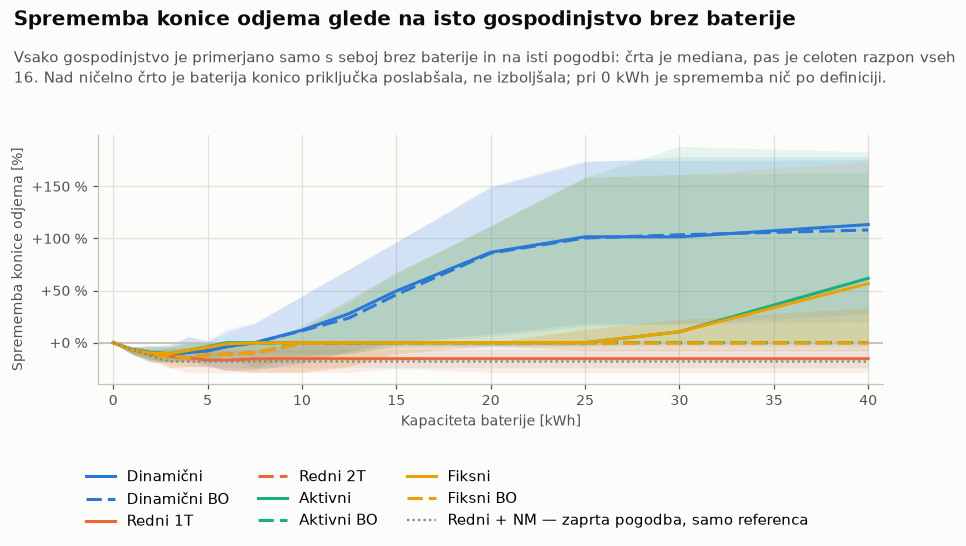

In [349]:
### The same peak as a change against the same household with no battery
# Its own figure: the axis is a percentage of each household's own peak and the
# band is the spread of the sixteen.
fig, ax = plt.subplots(figsize=(8.2, 5.0))
for contract in CONTRACT_ORDER:
    rel = by_cap["Peak_Change_pct"].median().loc[contract]
    lo = by_cap["Peak_Change_pct"].min().loc[contract]
    hi = by_cap["Peak_Change_pct"].max().loc[contract]
    # Band = the households' spread, so a median cannot hide one runaway.
    ax.fill_between(rel.index, lo.values, hi.values, color=CONTRACT_COLOR[contract],
                    alpha=0.10, lw=0, zorder=1)
    ax.plot(rel.index, rel.values, color=CONTRACT_COLOR[contract],
            ls=CONTRACT_DASH[contract], lw=CONTRACT_LW[contract], zorder=3)

ax.axhline(0, color=BASELINE, lw=1.2, zorder=2)
ax.set_xlabel("Kapaciteta baterije [kWh]")
ax.set_ylabel("Sprememba konice odjema [%]")
ax.yaxis.set_major_formatter(PCT)
ax.margins(x=0.02)

chart_frame(fig, "Sprememba konice odjema glede na isto gospodinjstvo brez baterije",
      f"Vsako gospodinjstvo je primerjano samo s seboj brez baterije in na isti pogodbi: črta "
      f"je mediana, pas je celoten razpon vseh {len(LABEL_ORDER)}. Nad ničelno črto je baterija "
      f"konico priključka poslabšala, ne izboljšala; pri 0 kWh je sprememba nič po definiciji.",
      ncol=3)
plt.show()


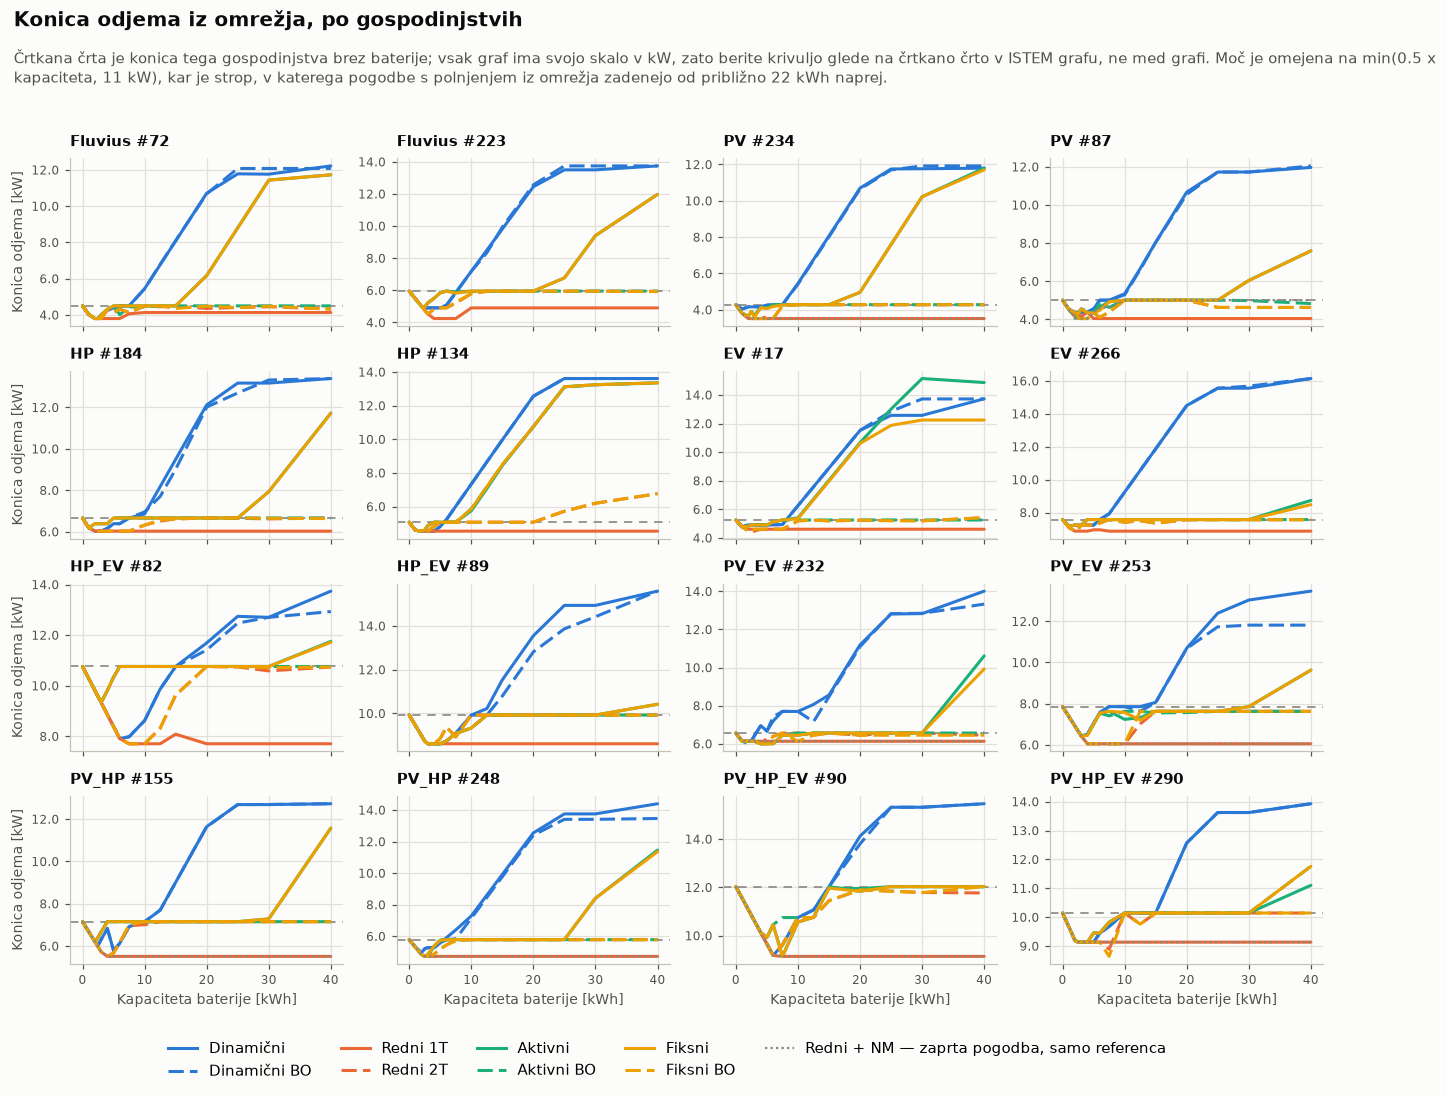

Peak grid import across 16 households x 9 contracts x 15 sized runs
  no battery, summed over the 16 households: 114.5 kW
     Dinamični: median   +0.0 % over all sizes,  114.0 kW summed at the optimal sizes, worst single run +175.6 %
  Dinamični BO: median   +0.0 % over all sizes,  104.8 kW summed at the optimal sizes, worst single run +178.5 %
      Redni 1T: median  -13.2 % over all sizes,  107.0 kW summed at the optimal sizes, worst single run   -3.9 %
      Redni 2T: median   -4.9 % over all sizes,  103.3 kW summed at the optimal sizes, worst single run  +33.5 %
       Aktivni: median   +0.0 % over all sizes,  108.3 kW summed at the optimal sizes, worst single run +188.4 %
    Aktivni BO: median   -0.2 % over all sizes,  106.2 kW summed at the optimal sizes, worst single run +163.3 %
        Fiksni: median   +0.0 % over all sizes,  107.9 kW summed at the optimal sizes, worst single run +173.4 %
     Fiksni BO: median   -4.9 % over all sizes,  103.0 kW summed at the optimal sizes, 

In [350]:
### The same thing household by household, each on its own scale
small_multiples(
    "Peak_Import_kW",
    "Konica odjema iz omrežja, po gospodinjstvih",
    f"Črtkana črta je konica tega gospodinjstva brez baterije; vsak graf ima svojo skalo v kW, "
    f"zato berite krivuljo glede na črtkano črto v ISTEM grafu, ne med grafi. Moč je omejena na "
    f"min({C_RATE:g} x kapaciteta, {INVERTER_MAX_KW:g} kW), kar je strop, v katerega pogodbe s "
    f"polnjenjem iz omrežja zadenejo od približno {INVERTER_MAX_KW / C_RATE:g} kWh naprej.",
    "Konica odjema [kW]",
    fmt=KW,
    baseline_col="Peak_Import_kW",
)

### Aggregate and extremes, since a median peak is not what gets billed
# On sized runs only: every 0 kWh row is a 0.0 % change that would sit in the
# middle of the ranking and drag the medians towards zero.
sized_peaks = peak_runs[peak_runs["Capacity_kWh"] > 0]
worst_row = sized_peaks.loc[sized_peaks["Peak_Change_pct"].idxmax()]
best_row = sized_peaks.loc[sized_peaks["Peak_Change_pct"].idxmin()]
print(f"Peak grid import across {len(LABEL_ORDER)} households x {len(CONTRACT_ORDER)} contracts "
      f"x {len(BATTERY_SIZES_KWH) - 1} sized runs")
print(f"  no battery, summed over the {len(LABEL_ORDER)} households: "
      f"{peak_base.groupby(level='Label').median().sum():,.1f} kW")
for contract in CONTRACT_ORDER:
    sub = sized_peaks[sized_peaks["Contract"] == contract]
    at_opt = best_table[best_table["Contract"] == contract]
    tag = "  (legacy)" if contract in LEGACY_CONTRACTS else ""
    print(f"  {contract:>12}: median {sub['Peak_Change_pct'].median():+6.1f} % over all sizes, "
          f"{at_opt['Peak_Import_kW'].sum():6.1f} kW summed at the optimal sizes, "
          f"worst single run {sub['Peak_Change_pct'].max():+6.1f} %{tag}")
print(f"  worst: {worst_row['Label']} on {worst_row['Contract']} at {worst_row['Capacity_kWh']:g} kWh — "
      f"{worst_row['Peak_No_Battery_kW']:.1f} -> {worst_row['Peak_Import_kW']:.1f} kW "
      f"({worst_row['Peak_Change_pct']:+.1f} %), {worst_row['Grid_Charged_kWh']:,.0f} kWh/a of it "
      f"charged from the grid")
print(f"  best:  {best_row['Label']} on {best_row['Contract']} at {best_row['Capacity_kWh']:g} kWh — "
      f"{best_row['Peak_No_Battery_kW']:.1f} -> {best_row['Peak_Import_kW']:.1f} kW "
      f"({best_row['Peak_Change_pct']:+.1f} %)")

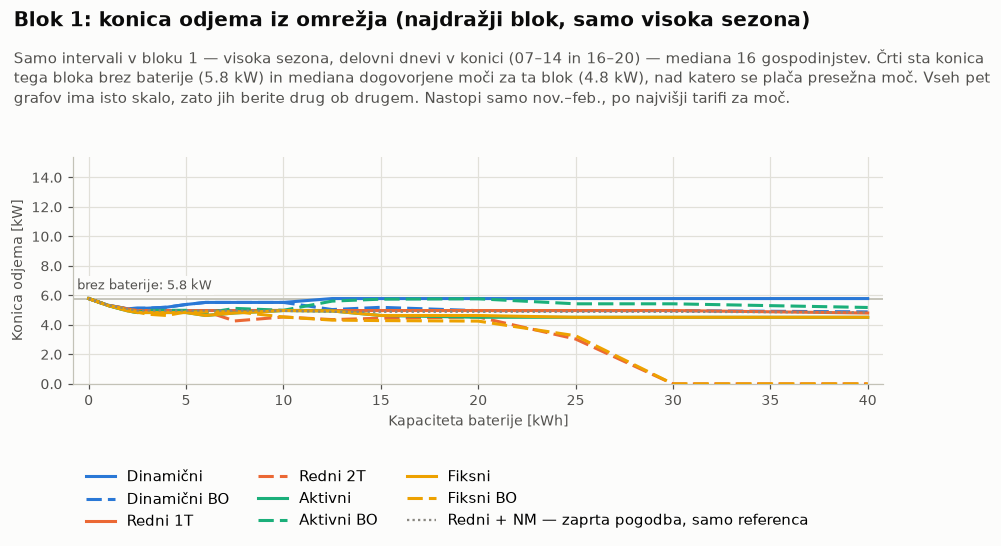

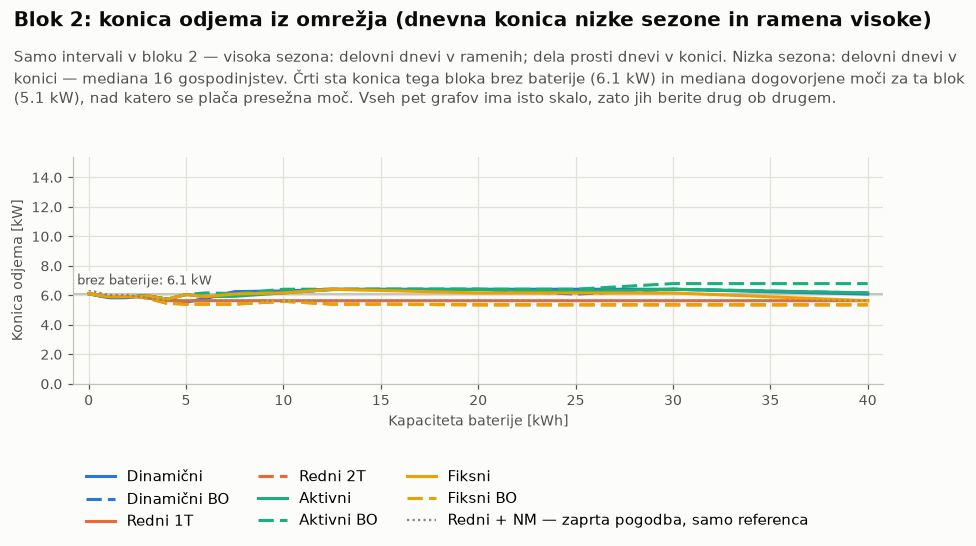

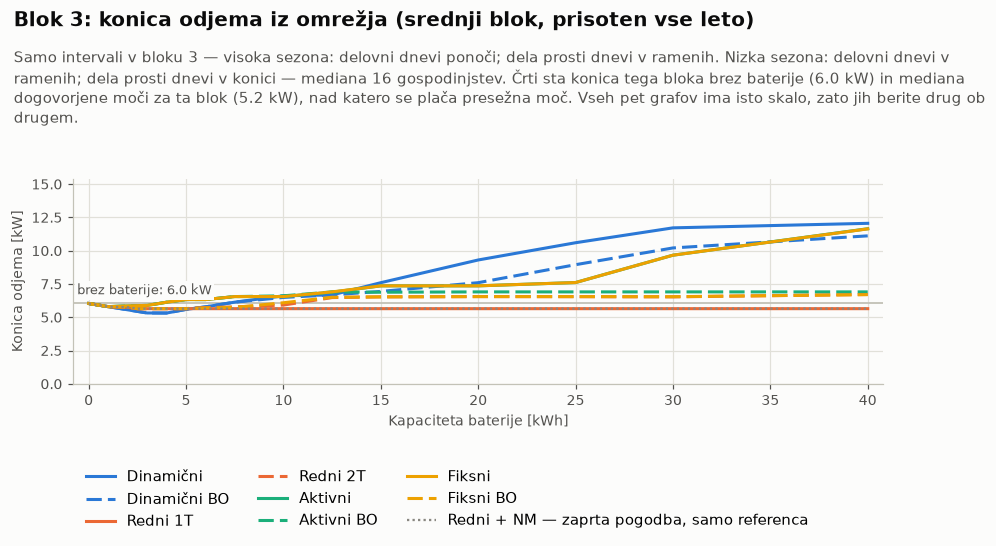

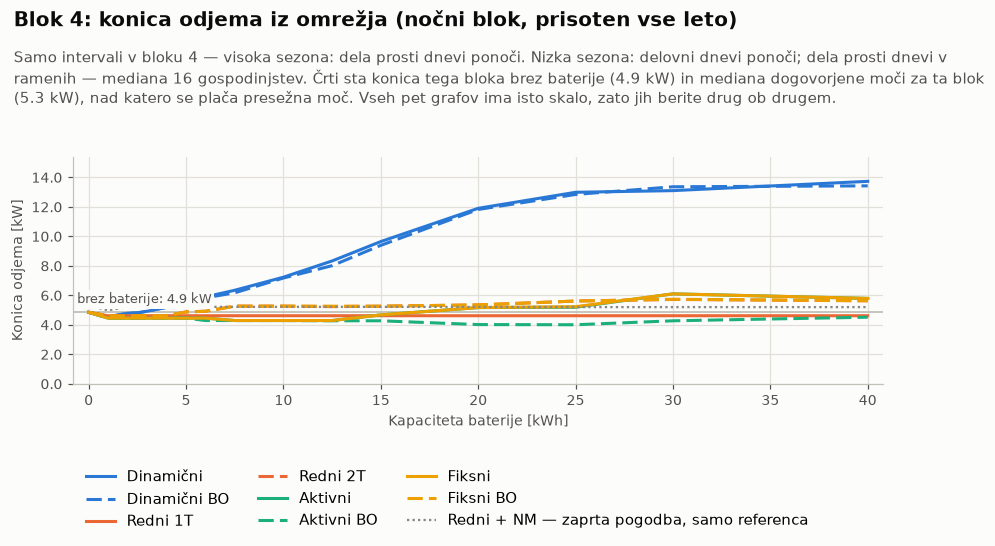

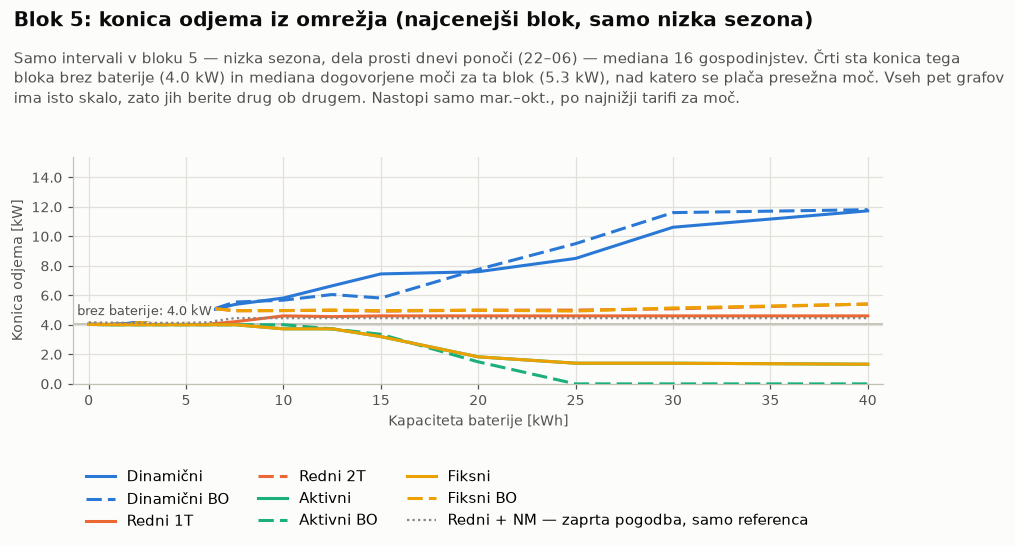

In [351]:
### The same peak inside each network-tariff block — five figures, one per block
# The network tariff prices power per time block, so a battery that moves a 10 kW
# draw out of block 1 and into block 5 leaves the annual peak untouched and still
# changes the bill.
#
# All five share one kW scale: here the comparison is between the blocks -- where
# the peak sits is the point -- and a per-figure scale would draw the cheapest
# block exactly like the dearest.
if not BLOCK_PEAKS_READY:
    print("No per-block peaks in this cache — nothing to draw. Set REQUIRE_BLOCK_PEAKS = True "
          "in section 1 and re-run section 6: the block peaks of a solved run cannot be "
          "recovered from its cached summary, so those runs have to be solved again.")
else:
    # Agreed power per block, median household: a property of the profile, so
    # one pass over the five columns rather than one groupby per figure.
    agreed_median = df.groupby("Label")[BLOCK_AGREED_COLS].first().median()
    by_cap_block = (
        peak_runs.groupby(["Contract", "Capacity_kWh"], observed=True)[BLOCK_PEAK_COLS].median()
    )
    # One scale for all five, with room for the reference labels at the top.
    block_ymax = 1.12 * float(by_cap_block.to_numpy().max())

    for b in TARIFF_BLOCKS:
        col = f"Peak_Import_B{b}_kW"
        fig, ax = plt.subplots(figsize=(8.2, 5.0))
        for contract in CONTRACT_ORDER:
            series = by_cap_block[col].loc[contract]
            ax.plot(series.index, series.values, color=CONTRACT_COLOR[contract],
                    ls=CONTRACT_DASH[contract], lw=CONTRACT_LW[contract], zorder=3)

        base_b = float(block_base[col].groupby(level="Label").median().median())
        # The agreed power of this block, which its excess charge is measured
        # against. The schedule is non-decreasing across blocks, so the cheap
        # night blocks are agreed higher than the expensive daytime one.
        agreed_b = float(agreed_median[f"Agreed_Power_B{b}_kW"])
        ax.axhline(base_b, color=BASELINE, lw=1.2, zorder=2)
        edge_label(ax, base_b, f"brez baterije: {base_b:,.1f} kW", side="left")
        #ax.axhline(agreed_b, color=MUTED, lw=1.1, ls=(0, (5, 4)), zorder=2)
        #edge_label(ax, agreed_b, f"mediana dogovorjene moči v bloku {b}: {agreed_b:,.1f} kW")
        ax.set_xlabel("Kapaciteta baterije [kWh]")
        ax.set_ylabel("Konica odjema [kW]")
        ax.set_ylim(0, block_ymax)
        ax.yaxis.set_major_formatter(KW)
        ax.margins(x=0.02)

        season = ""
        if b == 1:
            season = " Nastopi samo nov.–feb., po najvišji tarifi za moč."
        elif b == 5:
            season = " Nastopi samo mar.–okt., po najnižji tarifi za moč."
        chart_frame(fig, f"Blok {b}: konica odjema iz omrežja ({BLOCK_ROLE_SI[b]})",
              f"Samo intervali v bloku {b} — {BLOCK_WHEN_SI[b]} — mediana "
              f"{len(LABEL_ORDER)} gospodinjstev. Črti sta konica tega bloka brez baterije "
              f"({base_b:,.1f} kW) in mediana dogovorjene moči za ta blok ({agreed_b:,.1f} kW), "
              f"nad katero se plača presežna moč. Vseh pet grafov ima isto skalo, zato jih "
              f"berite drug ob drugem.{season}", ncol=3)
        plt.show()


In [352]:
### Aggregate and extremes per block, since the power charge is paid five times
# What each contract does to the peak of each block, as a percentage of the
# household's own no-battery peak in that block; then the kW the community would
# be billed for, summed at each household's optimal size.
if not BLOCK_PEAKS_READY:
    print("No per-block peaks in this cache — see the cell above.")
else:
    # Sized runs only: every 0 kWh row is a 0.0 % change by construction, and it
    # would sit in the middle of the ranking and drag every median towards zero.
    sized_blocks = peak_runs[peak_runs["Capacity_kWh"] > 0]
    zero_rows = peak_runs[peak_runs["Capacity_kWh"] == 0.0]
    agreed_median = df.groupby("Label")[BLOCK_AGREED_COLS].first().median()

    print(f"Peak grid import per tariff block, {len(LABEL_ORDER)} households x "
          f"{len(CONTRACT_ORDER)} contracts x {len(BATTERY_SIZES_KWH) - 1} sized runs")
    for b in TARIFF_BLOCKS:
        col, change = f"Peak_Import_B{b}_kW", f"Peak_Change_B{b}_pct"
        base_med = float(zero_rows.groupby("Label")[col].median().median())
        agreed_med = float(agreed_median[f"Agreed_Power_B{b}_kW"])
        worst = sized_blocks.loc[sized_blocks[change].idxmax()]
        best_run = sized_blocks.loc[sized_blocks[change].idxmin()]
        print(f"  block {b} ({BLOCK_ROLE_SI[b]}): median household draws {base_med:5.1f} kW "
              f"with no battery against {agreed_med:5.1f} kW agreed")
        print(f"      worst {worst['Label']} on {worst['Contract']} at "
              f"{worst['Capacity_kWh']:g} kWh — {worst[f'Peak_No_Battery_B{b}_kW']:.1f} -> "
              f"{worst[col]:.1f} kW ({worst[change]:+.1f} %), "
              f"{worst['Grid_Charged_kWh']:,.0f} kWh/a of it charged from the grid")
        print(f"      best  {best_run['Label']} on {best_run['Contract']} at "
              f"{best_run['Capacity_kWh']:g} kWh — "
              f"{best_run[f'Peak_No_Battery_B{b}_kW']:.1f} -> {best_run[col]:.1f} kW "
              f"({best_run[change]:+.1f} %)")

    def legacy_tagged(index):
        return [f"{t}{'  (legacy)' if t in LEGACY_CONTRACTS else ''}" for t in index]

    block_change = (
        sized_blocks.groupby("Contract", observed=True)[
            [f"Peak_Change_B{b}_pct" for b in TARIFF_BLOCKS]
        ].median().reindex(CONTRACT_ORDER)
    )
    block_change.columns = [f"Blok {b}" for b in TARIFF_BLOCKS]
    block_change.index = legacy_tagged(block_change.index)

    billed = pd.DataFrame({
        f"Blok {b}": best_table.groupby("Contract", observed=True)[f"Peak_Import_B{b}_kW"].sum()
        for b in TARIFF_BLOCKS
    }).reindex(CONTRACT_ORDER)
    # The household count travels with the sum: NET metering is quotable to the
    # PV households only, so its row is a sum over half the sample.
    billed.insert(0, "Gospodinjstev",
                  best_table.groupby("Contract", observed=True).size().reindex(CONTRACT_ORDER))
    billed.index = legacy_tagged(billed.index)
    # The same sum with no battery: each household's 0 kWh peak is one number per
    # block, identical across contracts, so the median just picks it.
    billed.loc["brez baterije"] = pd.Series({
        "Gospodinjstev": len(LABEL_ORDER),
        **{f"Blok {b}": float(zero_rows.groupby("Label")[f"Peak_Import_B{b}_kW"].median().sum())
           for b in TARIFF_BLOCKS},
    })

    print("\nMedian change in that block's peak against the same household with no battery "
          "[%], over all sized runs")
    display(block_change.round(1))
    print(f"Peak import summed over the {len(LABEL_ORDER)} households at their optimal sizes "
          f"[kW] — the power the community gets billed for, block by block")
    display(billed.round(1))


Peak grid import per tariff block, 16 households x 9 contracts x 15 sized runs
  block 1 (najdražji blok, samo visoka sezona): median household draws   5.8 kW with no battery against   4.8 kW agreed
      worst HP #134 on Aktivni at 3 kWh — 3.4 -> 3.4 kW (+0.0 %), 1,165 kWh/a of it charged from the grid
      best  Fluvius #72 on Fiksni BO at 12.5 kWh — 3.8 -> 0.0 kW (-100.0 %)
  block 2 (dnevna konica nizke sezone in ramena visoke): median household draws   6.1 kW with no battery against   5.1 kW agreed
      worst HP #134 on Aktivni BO at 40 kWh — 4.5 -> 7.7 kW (+72.3 %), 6,183 kWh/a of it charged from the grid
      best  PV #87 on Redni + NM at 30 kWh — 4.6 -> 0.0 kW (-100.0 %)
  block 3 (srednji blok, prisoten vse leto): median household draws   6.0 kW with no battery against   5.2 kW agreed
      worst PV #234 on Aktivni at 40 kWh — 3.4 -> 11.8 kW (+245.0 %), 8,597 kWh/a of it charged from the grid
      best  Fluvius #223 on Fiksni BO at 4 kWh — 5.5 -> 3.7 kW (-31.9 %)
  block 4

,Blok 1,Blok 2,Blok 3,Blok 4,Blok 5
Dinamični,-4.4,0.0,8.9,29.1,32.1
Dinamični BO,-7.7,0.0,6.5,26.2,24.2
Redni 1T,-11.0,-12.3,-9.0,-2.5,0.0
Redni 2T,-15.3,-12.4,0.0,0.0,16.1
Aktivni,-14.4,0.0,9.5,-0.7,-1.6
Aktivni BO,-9.5,0.0,7.9,-3.4,-1.6
Fiksni,-14.4,-0.4,9.4,-0.7,-1.6
Fiksni BO,-15.7,-12.4,0.0,0.0,16.1
Redni + NM (legacy),-14.8,-12.8,-2.0,-2.5,0.0


Peak import summed over the 16 households at their optimal sizes [kW] — the power the community gets billed for, block by block


,Gospodinjstev,Blok 1,Blok 2,Blok 3,Blok 4,Blok 5
Dinamični,16.0,91.4,103.4,103.8,108.3,94.8
Dinamični BO,16.0,90.5,99.9,96.1,89.6,76.9
Redni 1T,16.0,93.6,101.0,94.4,81.0,69.0
Redni 2T,16.0,90.2,97.8,93.7,81.9,69.5
Aktivni,16.0,83.8,103.3,107.8,78.3,64.4
Aktivni BO,16.0,85.7,102.0,103.2,77.7,68.3
Fiksni,16.0,83.8,102.7,107.5,78.3,64.4
Fiksni BO,16.0,90.0,97.8,93.7,81.4,69.5
Redni + NM (legacy),8.0,48.5,51.1,47.2,39.8,34.4
brez baterije,16.0,100.5,107.2,99.2,84.2,69.5


## 10. Read-out

In [353]:
lines = [
    f"{len(LABEL_ORDER)} households, split evenly over {len(PV_DATASETS)} Fluvius families "
    f"({', '.join(PV_DATASETS)}), calendar year 2024",
    f"{N_STEPS_FULL_YEAR:,} intervals of {step_minutes:.0f} min each — the whole year, every run",
    f"{len(ALL_CONTRACT_ORDER)} GEN-I price lists x up to {len(BATTERY_SIZES_KWH)} capacities "
    f"({BATTERY_SIZES_KWH.min():.0f}-{BATTERY_SIZES_KWH.max():.0f} kWh) = {len(df)} full-year "
    f"MILPs, the price lists a household cannot be quoted left out",
    f"Selectable and swept: {', '.join(CURRENT_CONTRACT_ORDER)}.  Selectable at 0 kWh only: "
    f"{', '.join(BASELINE_CONTRACTS)} — plain two-tariff supply, what a household with no "
    f"self-supply device pays before it installs anything",
    f"Legacy, reference only: {', '.join(LEGACY_CONTRACTS)} — closed to new contracts, so it "
    f"never wins anything below; and out of reach entirely without production",
    f"{sum(HAS_PV.values())} of {len(HOUSEHOLD_KEYS)} households have a self-supply device",
    f"Storage at {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR fixed, "
    f"r = {DISCOUNT_RATE:.0%}",
    f"SI tariff regime {PRICING_REFERENCE_YEAR}, peak reset {PEAK_RESET_MONTHS or 'never (annual ratchet)'}",
    "",
    "WITHOUT A BATTERY",
]
for label in LABEL_ORDER:
    r = no_batt.loc[label]
    legacy_bits = "  ".join(
        f"[{leg} {float(r[leg]):,.2f}, {float(r[f'{leg} - best_EUR']):+,.2f} vs best]"
        for leg in LEGACY_CONTRACTS
    )
    lines.append(
        f"  {label:>16}: cheapest {str(r['Cheapest']):<24} "
        f"{float(r['Cheapest_EUR']):8,.2f} EUR/a"
        f"   (spread across the {len(CURRENT_CONTRACT_ORDER)} selectable lists "
        f"{float(r['Spread_EUR']):7,.2f} EUR/a)  {legacy_bits}"
    )

lines += ["", "WITH THE BEST BATTERY THE BEST SELECTABLE CONTRACT SUPPORTS"]
for _, r in headline.iterrows():
    lines.append(
        f"  {r['Household']:>16}: {str(r['Best_contract_with_battery']):<12} "
        f"{r['Optimal_kWh']:5.1f} kWh -> saves {r['Savings_EUR']:8,.2f} EUR/a, "
        f"net {r['Net_Annual_EUR']:+8,.2f} EUR/a, ROI {r['ROI_pct']:+7.1f} %, "
        f"payback {r['Payback_y']:5.1f} y, {r['Cycles_per_year']:5.0f} cycles/a "
        f"[pays: {r['Battery_pays']}; storage cost only: {r['Pays_storage_only']}]"
    )

n_pays = int((headline["Battery_pays"] == "yes").sum())
n_storage = int((headline["Pays_storage_only"] == "yes").sum())
edge = best_table[best_table["Optimum_At_Grid_Edge"] != ""]
lines += [
    "",
    f"  -> {n_pays} of {len(headline)} households have ANY capacity with a positive net annual "
    f"benefit at {CAPEX_EUR_PER_KWH:,.0f} EUR/kWh + {CAPEX_FIXED_EUR:,.0f} EUR fixed.",
    f"  -> {n_storage} of {len(headline)} do once the {CAPEX_FIXED_EUR:,.0f} EUR install is "
    f"treated as sunk and only the storage is charged for — that fixed term, not the",
    f"     per-kWh price, is what decides it at these sizes.",
]
if len(edge):
    lines.append(
        f"  -> {len(edge)} of {len(best_table)} (household, contract) optima sit on the edge of the "
        f"swept grid ({SMALLEST_SIZED:g}-{LARGEST_SIZED:g} kWh), so the grid rather than the"
    )
    lines.append("     economics is picking those sizes — read them as 'as small as swept', not as an optimum.")

lines += ["", "THE LEGACY CONTRACT — for households already on NET metering, not a baseline"]
for legacy in LEGACY_CONTRACTS:
    # dropna: a household with no production was never quoted this list, so it
    # is not one of the households the shares below are out of.
    cost_delta = no_batt[f"{legacy} - best_EUR"].dropna()   # negative = legacy bill is lower
    leg_rows = best_table[best_table["Contract"] == legacy]
    pad = " " * (len(legacy) + 2)
    lines.append(
        f"  {legacy}: THE BILL — cheaper than the best selectable list for "
        f"{int((cost_delta < 0).sum())} of the {len(cost_delta)} households that can hold it, by "
        f"{-cost_delta.median():,.2f} EUR/a at the median"
    )
    lines.append(
        f"{pad}(worst case for the holder {-cost_delta.max():,.2f}, best "
        f"{-cost_delta.min():,.2f}). That is what ending the contract costs them."
    )
    lines.append(
        f"{pad}THE BATTERY — worth {leg_rows['Savings_EUR'].median():,.2f} EUR/a at the median "
        f"optimum of {leg_rows['Capacity_kWh'].median():.1f} kWh, against "
        f"{headline['Savings_EUR'].median():,.2f} EUR/a on the best"
    )
    lines.append(
        f"{pad}selectable list. Annual netting already credits exported energy at the same "
        f"supplier price the household buys at, so a battery has no"
    )
    lines.append(
        f"{pad}energy spread left to capture on this list — only the network charge and the "
        f"peak, which is close to nothing here. Storage and NET"
    )
    lines.append(
        f"{pad}metering are substitutes, not complements: while the contract lasts it is doing "
        f"the battery's job. Size the pack for the selectable"
    )
    lines.append(
        f"{pad}list the household falls back to when the contract ends — that is the row above, "
        f"not this one."
    )

lines += ["", "SAMOOSKRBA AGAINST BREZ ODKUPA — the same product, quoted both ways"]
lines.append(
    "  Two questions per product: what the export credit is worth on the bill with no battery, "
    "and whether it changes what the battery is worth."
)
PV_LABELS = [HOUSEHOLD_LABELS[k] for k in HOUSEHOLD_KEYS if HAS_PV[k]]
NO_PV_LABELS = [HOUSEHOLD_LABELS[k] for k in HOUSEHOLD_KEYS if not HAS_PV[k]]
for product in PAIRED_PRODUCTS:
    samo, plain = CONTRACT_PAIRS[product][True], CONTRACT_PAIRS[product][False]
    # Positive = the samooskrba form is the cheaper bill / the better battery.
    bill = (no_batt[plain] - no_batt[samo]).dropna()
    net_at_opt = (
        best_table.set_index(["Label", "Contract"])["Net_Annual_EUR"]
        .unstack("Contract")
        .pipe(lambda d: d[samo] - d[plain])
        .dropna()
    )
    pad = " " * 4
    lines.append("")
    lines.append(f"  {product}:  {samo} (samooskrba)  vs  {plain} (brez odkupa)")
    lines.append(
        f"{pad}bill, no battery      samooskrba is {bill.median():+8,.2f} EUR/a cheaper at the "
        f"median  (with PV {bill.reindex(PV_LABELS).median():+8,.2f}, "
        f"without {bill.reindex(NO_PV_LABELS).median():+8,.2f})"
    )
    lines.append(
        f"{pad}net at own optimum    samooskrba is {net_at_opt.median():+8,.2f} EUR/a better at "
        f"the median  (with PV {net_at_opt.reindex(PV_LABELS).median():+8,.2f}, "
        f"without {net_at_opt.reindex(NO_PV_LABELS).median():+8,.2f})"
    )
    won = int((bill > 0).sum())
    lines.append(
        f"{pad}-> the samooskrba form is the cheaper bill for {won} of {len(bill)} households; "
        f"where it is not, the plain list's own prices are what wins, not the credit."
    )
lines.append("")
lines.append(
    "  A household without production sees NO export credit either way, so its numbers above "
    "are the difference between the two price lists alone —"
)
lines.append(
    "  VT/MT against a flat ET, a capped SIPX against an uncapped one, one block table against "
    "another. That is the comparison this pair answers for them."
)

lines += ["", "EXTREMES — where the assumptions show"]
hi = headline.loc[headline["Net_Annual_EUR"].idxmax()]
lo = headline.loc[headline["Net_Annual_EUR"].idxmin()]
for tag, r in (("best ", hi), ("worst", lo)):
    key = [k for k in HOUSEHOLD_KEYS if HOUSEHOLD_LABELS[k] == r["Household"]][0]
    prof = selected[(selected["Dataset"] == key[0]) & (selected["Household"] == key[1])].iloc[0]
    run = df[(df["Label"] == r["Household"]) & (df["Contract"] == r["Best_contract_with_battery"])
             & (df["Capacity_kWh"] == r["Optimal_kWh"])].iloc[0]
    lines.append(
        f"  {tag} case {r['Household']:>16} on {str(r['Best_contract_with_battery']):<12} "
        f"net {r['Net_Annual_EUR']:+8,.2f} EUR/a"
    )
    lines.append(
        f"          load {prof['Consumption_kWh']:6,.0f} kWh/a, PV {prof['Generation_kWh']:6,.0f} kWh/a "
        f"(PV/load {prof['PV_to_Load']:.2f}), {prof['Role']}"
    )
    lines.append(
        f"          at the optimum: imports {run['Import_kWh']:6,.0f}, exports {run['Export_kWh']:6,.0f}, "
        f"curtails {run['Curtailed_kWh']:6,.0f} kWh/a; {run['Grid_Charged_kWh']:6,.0f} kWh/a of the "
        f"charging came from the grid ({100 * run['Grid_Charged_kWh'] / max(run['Charged_kWh'], 1e-9):.0f} % "
        f"of throughput — that share is arbitrage, not self-consumption)"
    )
    lines.append(
        f"          peak import {run['Peak_Import_kW']:5.2f} kW against a contracted "
        f"{run['Contracted_Power_kW']:5.2f} kW"
    )

lines += ["", f"PER CONTRACT, MEDIAN OVER THE {len(LABEL_ORDER)} HOUSEHOLDS AT THEIR OPTIMAL SIZE"]
for contract in CONTRACT_ORDER:
    sub = best_table[best_table["Contract"] == contract]
    tag = "  (legacy)" if contract in LEGACY_CONTRACTS else ""
    lines.append(
        f"  {contract:>12}: {sub['Capacity_kWh'].median():5.1f} kWh, "
        f"saves {sub['Savings_EUR'].median():8,.2f} EUR/a, "
        f"net {sub['Net_Annual_EUR'].median():+8,.2f} EUR/a, "
        f"ROI {sub['ROI_pct'].median():+7.1f} %, "
        f"{sub['Equivalent_Full_Cycles'].median():5.0f} cycles/a, "
        f"life {sub['Service_Life_y'].median():4.1f} y "
        f"({sub['Life_Limited_By'].mode().iloc[0]}-limited){tag}"
    )
# Where the money comes from, per list. A large grid-charged share means the
# saving is trading revenue that depends on the 2024 price spread repeating.
lines.append("")
for contract in CONTRACT_ORDER:
    sub = best_table[best_table["Contract"] == contract]
    share = 100.0 * sub["Grid_Charged_kWh"] / sub["Charged_kWh"].where(sub["Charged_kWh"] > 0)
    lines.append(
        f"  {contract:>12}: {share.median():5.1f} % of the charge energy at the optimal size came "
        f"from the grid, not from PV (range {share.min():.0f}-{share.max():.0f} %)"
    )

lines += ["", "OPTIMAL SIZE AGAINST THE STORAGE PRICE — median over the households, per contract"]
lines.append(f"  {'EUR/kWh':>12} " + "".join(f"{c:>7,.0f}" for c in CAPEX_TABLE_EUR_PER_KWH))
for contract in CONTRACT_ORDER:
    med = opt_size.xs(contract, level="Contract").median()
    tag = "  (legacy)" if contract in LEGACY_CONTRACTS else ""
    lines.append(f"  {contract:>12} " + "".join(f"{v:>7.1f}" for v in med) + f"  kWh{tag}")
for contract in CONTRACT_ORDER:
    n_ok = (opt_net.xs(contract, level="Contract") > 0).sum()
    tag = "  (legacy)" if contract in LEGACY_CONTRACTS else ""
    lines.append(f"  {contract:>12} " + "".join(f"{v:>7d}" for v in n_ok)
                 + f"  households in profit of {len(LABEL_ORDER)}{tag}")

lines += ["", "IF EVERY HOUSEHOLD BUYS ITS OWN OPTIMUM — by user type, then summed (section 8.7)"]
for family in FAMILY_ORDER:
    r = by_type.loc[family]
    lines.append(
        f"  {family:>10}: {int(r['Households']):2d} households, {r['Median_kWh']:5.1f} kWh median "
        f"({r['Min_kWh']:g}-{r['Max_kWh']:g} kWh), {r['Total_kWh']:6.1f} kWh installed, "
        f"saves {r['Total_savings_EUR_a']:8,.0f} EUR/a, net {r['Total_net_EUR_a']:+8,.0f} EUR/a, "
        f"{int(r['In_profit'])} of {int(r['Households'])} in profit"
    )
lines.append(
    f"  {'COMMUNITY':>10}: {tot_kwh:,.1f} kWh and {own['Power_kW_at_optimum'].sum():,.1f} kW of "
    f"inverter for {tot_capex:,.0f} EUR -> bill {tot_before:,.0f} -> {tot_after:,.0f} EUR/a "
    f"(-{100 * (1 - tot_after / tot_before):.1f} %),"
)
lines.append(
    f"  {'':>10}  net {tot_net:+,.0f} EUR/a, peak import {peak_before:,.1f} -> {peak_after:,.1f} kW "
    f"({peak_delta_pct:+.1f} %)"
)

lines += ["", "SENSITIVITY — break-even installed cost at each household's optimum"]
for _, r in best_table.iterrows():
    if str(r["Contract"]) == str(
        headline.loc[headline["Household"] == r["Label"], "Best_contract_with_battery"].iloc[0]
    ):
        lines.append(
            f"  {r['Label']:>16} on {r['Contract']:<12}: pays for itself below "
            f"{float(df.loc[(df['Label'] == r['Label']) & (df['Contract'] == r['Contract']) & (df['Capacity_kWh'] == r['Capacity_kWh']), 'Break_Even_Capex_EUR_kWh'].iloc[0]):7,.0f} EUR/kWh"
            f"   (assumed {CAPEX_EUR_PER_KWH:,.0f})"
        )

print("\n".join(lines))

16 households, split evenly over 8 Fluvius families (Fluvius, Fluvius_PV, Fluvius_HP, Fluvius_EV, Fluvius_HP_EV, Fluvius_PV_EV, Fluvius_PV_HP, Fluvius_PV_HP_EV), calendar year 2024
35,136 intervals of 15 min each — the whole year, every run
9 GEN-I price lists x up to 16 capacities (0-40 kWh) = 2176 full-year MILPs, the price lists a household cannot be quoted left out
Selectable and swept: Dinamični, Dinamični BO, Redni 1T, Redni 2T, Aktivni, Aktivni BO, Fiksni, Fiksni BO.  Selectable at 0 kWh only:  — plain two-tariff supply, what a household with no self-supply device pays before it installs anything
Legacy, reference only: Redni + NM — closed to new contracts, so it never wins anything below; and out of reach entirely without production
8 of 16 households have a self-supply device
Storage at 250 EUR/kWh + 1,000 EUR fixed, r = 5%
SI tariff regime 2026, peak reset 1

WITHOUT A BATTERY
       Fluvius #72: cheapest Redni 1T                   411.91 EUR/a   (spread across the 8 selectab

### Caveats

* **Perfect foresight.** Every point is an upper bound, so the true optimal size is at or below
  what these curves show and every ROI is optimistic.
* **0.1 % MIP gap.** Each point is within 0.1 % of its own optimum, a few tenths of a euro here.
* **NET metering is a legacy contract**, excluded from every winner and headline and reported as
  a grey reference line. The battery a holder buys will outlive the contract, so size the pack
  on the selectable list it falls back to.
* **NET metering is modelled as supplier-energy netting only.** Network charges and levies are
  billed on gross metered offtake. The waived monthly fee per whole MWh of surplus is not
  modelled.
* **Arbitrage through the grid, including on the list that wins.** On the dynamic list that is
  the SIPX spread; on Aktivni the fixed block spread, 0.04090 in and 0.14990 out, available every
  day and bounded only by the inverter. Around half the charge energy at the optimal sizes comes
  from the grid on both, so much of what makes them the best lists here is trading revenue rather
  than PV self-consumption. It is also what drives the high cycle counts.
* **A no-buyback list is a household that curtails, and the curtailment is real energy** — often
  more than a megawatt-hour a year for a PV household. Read `Curtailed_kWh` alongside the bill.
* **On a `BO` list, `Export_kWh` and `Curtailed_kWh` are not separately meaningful.** With the
  credit at exactly zero the split is a tie the solver breaks arbitrarily; only their sum is the
  surplus. A hard 0 kW export limit needs a constraint on `P_sell`, not a price of zero.
* **The export rate is floored at the import rate, on 140 intervals of 2024.** `Dinamični BO`
  credits exports nothing and leaves SIPX unbounded below, so where the delivered import price
  goes negative the buy/sell round trip pays and the model is unbounded. Flooring makes it
  neutral; curtailment is free, so the optimum never exports there. The count is cached as
  `Export_Rate_Floored_Intervals` and is zero on all eight other lists.
* **The two forms of a product differ in more than the credit**, so a pair's gap is never a clean
  measurement of what the export credit is worth.
* **`si_dobava` is never used**, and would credit an exported kWh at the full retail import price
  plus network charges, levies and VAT (−0.17365 EUR/kWh where a plain contract pays 0.00000).
* **Peak charges.** `PEAK_RESET_MONTHS = None` ratchets one peak across the year; `= 1` is the
  monthly settlement the SI regulation uses, identically for all nine lists.
* **Agreed billing power.** `CONTRACTED_POWER_KW = None` leaves it to the environment, which
  re-sets the *dogovorjena obračunska moč* every month to the previous month's peak in each of
  the five tariff blocks, with no floor and no ceiling and the leading month bootstrapped from
  the last complete one. A household that never touches its assigned figure is exempt from the
  excess-power charge, so managing it is what makes the charge payable.
* **The Fluvius clock is 1–2 h off (section 4).** All nine lists read the same shifted clock, so
  the comparison holds; the absolute bills, and anything hinging on block boundaries, carry the
  error.
* **`Feed_In_Volume_kWh` is metered feed-in, not gross PV**, and roughly 12 % of intervals have
  both registers nonzero, so self-consumption that never crossed the meter is not in this data.
* **One price year, sixteen households.**